# AI-Powered GitHub Pull Request Outcome, Risk and Delivery Intelligence

## Machine Learning, LLM, RAG and Agentic RAG

### Project Overview

This project develops an intelligent decision-support platform for analysing
GitHub pull requests throughout their review lifecycle.

The platform combines machine learning, deterministic engineering controls,
retrieval-augmented generation, a local large language model and an agentic
workflow.

### Business Problem

Software engineering teams may manage hundreds of pull requests across one or
more repositories.

Some pull requests may:

- be closed without merging;
- remain under review for a long time;
- contain unusually large or complex changes;
- modify production code without corresponding tests;
- affect security-sensitive components;
- fail continuous-integration checks;
- conflict with repository policies;
- require specialist review.

### Project Objectives

The platform will provide:

1. Merge-outcome prediction
2. Merge-delay prediction
3. Engineering change-risk scoring
4. Test-gap detection
5. Security-review requirement detection
6. Repository policy-compliance analysis
7. CI status and failure analysis
8. Evidence-grounded LLM review
9. Agentic workflow orchestration
10. Reviewer action recommendations

### Decision-Control Principle

The platform provides decision support only.

It does not automatically merge, reject or deploy pull requests.

In [ ]:
# installing packages

%pip install -q --upgrade pip

%pip install -q requests pandas numpy scipy scikit-learn matplotlib python-dotenv pydantic tqdm joblib ollama

In [ ]:
# Importing all required libraries

import json
import logging
import os
import random
import time
import warnings
import sys

from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Optional

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from dotenv import load_dotenv
from pydantic import BaseModel, Field, ValidationError
from tqdm.auto import tqdm

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import ollama

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

In [ ]:
# Reproducibility

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)

In [ ]:
# Creating project folders

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
CACHE_DIR = DATA_DIR / "cache"
EVALUATION_DIR = DATA_DIR / "evaluation"
KNOWLEDGE_BASE_DIR = DATA_DIR / "knowledge_base"

LOGS_DIR = PROJECT_ROOT / "logs"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"

project_folders = [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    CACHE_DIR,
    EVALUATION_DIR,
    KNOWLEDGE_BASE_DIR,
    LOGS_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
]

for folder in project_folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready:\n")

for folder in project_folders:
    print(folder.relative_to(PROJECT_ROOT))

In [ ]:
# Logging

LOG_FILE = LOGS_DIR / "github_pr_intelligence.log"

logger = logging.getLogger("github_pr_intelligence")
logger.setLevel(logging.INFO)

logger.handlers.clear()
logger.propagate = False

log_format = logging.Formatter(
    "%(asctime)s | %(levelname)s | %(message)s"
)

file_handler = logging.FileHandler(
    LOG_FILE,
    encoding="utf-8",
)

file_handler.setFormatter(log_format)

console_handler = logging.StreamHandler()
console_handler.setFormatter(log_format)

logger.addHandler(file_handler)
logger.addHandler(console_handler)

logger.info("Project logging started.")

print("Log file created:")
print(LOG_FILE)

In [ ]:
# Creating central project configuration
# Instead of writing values repeatedly throughout the notebook, we keep important settings in one place.

CONFIG = {
    "project": {
        "name": (
            "AI Powered GitHub Pull Request "
            "Outcome, Risk and Delivery Intelligence"
        ),
        "subtitle": (
            "Machine Learning, LLM, RAG and Agentic RAG"
        ),
        "version": "1.0.0",
    },

    "github": {
        "api_base_url": "https://api.github.com",
        "request_timeout_seconds": 30,
        "maximum_retries": 3,
        "retry_wait_seconds": 2,
        "records_per_page": 100,
        "cache_enabled": True,
    },

    "repository": {
        "owner": "pallets",
        "name": "flask",
    },

    "targets": {
        "merge_delay_threshold_hours": 48,
    },

    "risk": {
        "large_change_threshold": 500,
        "very_large_change_threshold": 1000,
        "many_files_threshold": 20,
    },

    "llm": {
        "model": "qwen2.5-coder:3b",
        "temperature": 0.0,
    },
}

print(CONFIG["project"]["name"])
print(CONFIG["project"]["subtitle"])

In [ ]:
# Creating repository name variables

REPOSITORY_OWNER = CONFIG["repository"]["owner"]
REPOSITORY_NAME = CONFIG["repository"]["name"]

REPOSITORY_FULL_NAME = (
    f"{REPOSITORY_OWNER}/{REPOSITORY_NAME}"
)

print("Repository selected:")
print(REPOSITORY_FULL_NAME)

In [ ]:
# Execution meteadata

execution_metadata = {
    "run_timestamp_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "python_executable": sys.executable,
    "python_version": sys.version,
    "project_version": CONFIG["project"]["version"],
    "random_seed": RANDOM_SEED,
    "repository": REPOSITORY_FULL_NAME,
    "llm_model": CONFIG["llm"]["model"],
}

metadata_file = (
    OUTPUTS_DIR
    / "execution_metadata.json"
)

with open(
    metadata_file,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        execution_metadata,
        file,
        indent=2,
    )

metadata_df = pd.DataFrame(
    execution_metadata.items(),
    columns=[
        "Setting",
        "Value",
    ],
)

display(metadata_df)

print("\nMetadata saved to:")
print(metadata_file)

In [ ]:
# Checking files and folders

project_check = {
    "project_root_exists": PROJECT_ROOT.exists(),
    "raw_data_folder_exists": RAW_DATA_DIR.exists(),
    "processed_data_folder_exists": PROCESSED_DATA_DIR.exists(),
    "cache_folder_exists": CACHE_DIR.exists(),
    "evaluation_folder_exists": EVALUATION_DIR.exists(),
    "knowledge_base_folder_exists": KNOWLEDGE_BASE_DIR.exists(),
    "logs_folder_exists": LOGS_DIR.exists(),
    "models_folder_exists": MODELS_DIR.exists(),
    "outputs_folder_exists": OUTPUTS_DIR.exists(),
    "reports_folder_exists": REPORTS_DIR.exists(),
    "log_file_exists": LOG_FILE.exists(),
    "metadata_file_exists": metadata_file.exists(),
}

project_check_df = pd.DataFrame(
    project_check.items(),
    columns=[
        "Check",
        "Passed",
    ],
)

display(project_check_df)

# GitHub authentication and API connection

Establishing a secure, read only connection to the GitHub REST API.

The connection will be used to collect public pull request information from selected repositories.

In [ ]:
# Loading the .env file

env_file = PROJECT_ROOT / ".env"

if not env_file.exists():
    raise FileNotFoundError(
        "The .env file was not found in the project folder."
    )

load_dotenv(
    dotenv_path=env_file,
    override=True,
)

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")

if not GITHUB_TOKEN:
    raise ValueError(
        "GITHUB_TOKEN was not found inside the .env file."
    )

print("GitHub token loaded successfully.")
print("Token characters:", len(GITHUB_TOKEN))

In [ ]:
# adding GitHub API version

CONFIG["github"]["api_version"] = "2026-03-10"

print(
    "GitHub API version:",
    CONFIG["github"]["api_version"],
)

In [ ]:
# Creating a reusable GitHub session

github_session = requests.Session()

github_session.headers.update(
    {
        "Accept": "application/vnd.github+json",
        "Authorization": f"Bearer {GITHUB_TOKEN}",
        "X-GitHub-Api-Version": CONFIG["github"]["api_version"],
        "User-Agent": "ai-github-pr-intelligence",
    }
)

print("GitHub API session created.")

In [ ]:
# Displaying headers

safe_headers = {}

for header_name, header_value in github_session.headers.items():
    if header_name.lower() == "authorization":
        safe_headers[header_name] = "Bearer ********"
    else:
        safe_headers[header_name] = header_value

safe_headers_df = pd.DataFrame(
    safe_headers.items(),
    columns=[
        "Header",
        "Value",
    ],
)

display(safe_headers_df)

In [ ]:
# Creating a reusablle API reqest version

def github_get(
    endpoint: str,
    params: Optional[dict[str, Any]] = None,
) -> requests.Response:
    """
    Send a GET request to the GitHub REST API.

    The function:
    - uses the authenticated GitHub session;
    - retries temporary failures;
    - records requests in the project log;
    - raises clear errors for failed requests.
    """

    if endpoint.startswith("https://"):
        url = endpoint
    else:
        url = (
            CONFIG["github"]["api_base_url"]
            + endpoint
        )

    maximum_retries = CONFIG[
        "github"
    ]["maximum_retries"]

    for attempt in range(
        1,
        maximum_retries + 2,
    ):
        try:
            response = github_session.get(
                url,
                params=params,
                timeout=CONFIG[
                    "github"
                ][
                    "request_timeout_seconds"
                ],
            )

            remaining_requests = (
                response.headers.get(
                    "X-RateLimit-Remaining",
                    "unknown",
                )
            )

            logger.info(
                "GET %s | status=%s | remaining=%s",
                response.url,
                response.status_code,
                remaining_requests,
            )

            if response.status_code == 200:
                return response

            if response.status_code == 401:
                raise PermissionError(
                    "GitHub authentication failed. "
                    "Check the token in the .env file."
                )

            if response.status_code == 403:
                raise PermissionError(
                    "GitHub denied the request. "
                    "The token may lack permission, "
                    "or the API rate limit may have been reached."
                )

            if response.status_code == 404:
                raise FileNotFoundError(
                    f"GitHub resource not found: {url}"
                )

            temporary_error = (
                response.status_code == 429
                or response.status_code >= 500
            )

            if (
                temporary_error
                and attempt <= maximum_retries
            ):
                wait_seconds = (
                    CONFIG["github"][
                        "retry_wait_seconds"
                    ]
                    * attempt
                )

                logger.warning(
                    "Temporary GitHub error. "
                    "Retrying in %s seconds.",
                    wait_seconds,
                )

                time.sleep(wait_seconds)
                continue

            response.raise_for_status()

        except (
            requests.Timeout,
            requests.ConnectionError,
        ) as error:
            logger.warning(
                "GitHub connection problem: %s",
                error,
            )

            if attempt <= maximum_retries:
                wait_seconds = (
                    CONFIG["github"][
                        "retry_wait_seconds"
                    ]
                    * attempt
                )

                time.sleep(wait_seconds)
                continue

            raise

    raise RuntimeError(
        "GitHub request failed after all retries."
    )

In [ ]:
# GitHub authentication testing

try:
    user_response = github_get("/user")
    user_data = user_response.json()

    print("GitHub authentication successful.")
    print(
        "Authenticated account:",
        user_data.get("login"),
    )

except Exception as error:
    print("GitHub authentication failed.")
    print(
        type(error).__name__,
        ":",
        error,
    )

In [ ]:
# Checking GitHub rate limit

rate_limit_response = github_get(
    "/rate_limit"
)

rate_limit_data = (
    rate_limit_response.json()
)

core_rate_limit = (
    rate_limit_data
    .get("resources", {})
    .get("core", {})
)

rate_limit_summary = {
    "request_limit": (
        core_rate_limit.get("limit")
    ),
    "requests_used": (
        core_rate_limit.get("used")
    ),
    "requests_remaining": (
        core_rate_limit.get("remaining")
    ),
    "reset_unix_timestamp": (
        core_rate_limit.get("reset")
    ),
}

reset_timestamp = (
    rate_limit_summary[
        "reset_unix_timestamp"
    ]
)

if reset_timestamp:
    rate_limit_summary[
        "reset_time_utc"
    ] = datetime.fromtimestamp(
        reset_timestamp,
        tz=timezone.utc,
    ).isoformat()

rate_limit_df = pd.DataFrame(
    rate_limit_summary.items(),
    columns=[
        "Rate Limit Metric",
        "Value",
    ],
)

display(rate_limit_df)

In [ ]:
# Verifying the selected repository

repository_response = github_get(
    f"/repos/{REPOSITORY_FULL_NAME}"
)

repository_data = (
    repository_response.json()
)

repository_summary = {
    "repository": (
        repository_data.get("full_name")
    ),
    "description": (
        repository_data.get("description")
    ),
    "private": (
        repository_data.get("private")
    ),
    "visibility": (
        repository_data.get("visibility")
    ),
    "default_branch": (
        repository_data.get("default_branch")
    ),
    "primary_language": (
        repository_data.get("language")
    ),
    "archived": (
        repository_data.get("archived")
    ),
    "disabled": (
        repository_data.get("disabled")
    ),
    "open_issues_count": (
        repository_data.get(
            "open_issues_count"
        )
    ),
}

repository_summary_df = pd.DataFrame(
    repository_summary.items(),
    columns=[
        "Repository Attribute",
        "Value",
    ],
)

display(repository_summary_df)

In [ ]:
# Connection checkpoint confirmation

connection_checks = {
    "env_file_found": env_file.exists(),
    "github_token_loaded": bool(GITHUB_TOKEN),
    "github_session_created": (
        github_session is not None
    ),
    "authentication_successful": bool(
        user_data.get("login")
    ),
    "repository_found": (
        repository_data.get("full_name")
        == REPOSITORY_FULL_NAME
    ),
    "repository_is_public": (
        repository_data.get("private")
        is False
    ),
    "repository_is_active": (
        repository_data.get("archived")
        is False
        and repository_data.get("disabled")
        is False
    ),
}

connection_checks_df = pd.DataFrame(
    connection_checks.items(),
    columns=[
        "Connection Check",
        "Passed",
    ],
)

display(connection_checks_df)

# Collecting a Small PR Sample of 5 Closed PRs

The sample is used to:

1. verify that pull request data can be retrieved
2. inspect the available GitHub fields
3. understand the difference between merged and unmerged pull requests
4. design the final historical datasets
5. avoid running a large extraction before the code is validated.



In [ ]:
# Creating a pagination function to handle GitHub pagination because GitHub does not normally return every record in one response

def github_get_all_pages(
    endpoint: str,
    params: Optional[dict[str, Any]] = None,
    maximum_pages: int = 10,
) -> list[dict[str, Any]]:
    """
    Download list-based GitHub API results across multiple pages.
    """

    request_params = dict(params or {})

    request_params["per_page"] = CONFIG[
        "github"
    ]["records_per_page"]

    all_records = []

    for page_number in range(
        1,
        maximum_pages + 1,
    ):
        request_params["page"] = page_number

        response = github_get(
            endpoint=endpoint,
            params=request_params,
        )

        page_records = response.json()

        if not isinstance(page_records, list):
            raise TypeError(
                "Expected GitHub to return a list of records."
            )

        all_records.extend(page_records)

        print(
            f"Page {page_number}: "
            f"{len(page_records)} records"
        )

        if len(page_records) < request_params["per_page"]:
            break

    return all_records

In [ ]:
# Downloading 5 recently closed PRs

merged_sample_response = github_get(
    endpoint=(
        f"/search/issues"
    ),
    params={
        "q": (
            f"repo:{REPOSITORY_FULL_NAME} "
            "is:pr is:merged"
        ),
        "sort": "created",
        "order": "desc",
        "per_page": 5,
    },
)

unmerged_sample_response = github_get(
    endpoint=(
        f"/search/issues"
    ),
    params={
        "q": (
            f"repo:{REPOSITORY_FULL_NAME} "
            "is:pr is:closed "
            "-is:merged"
        ),
        "sort": "created",
        "order": "desc",
        "per_page": 5,
    },
)

merged_search_items = (
    merged_sample_response.json()
    .get("items", [])
)

unmerged_search_items = (
    unmerged_sample_response.json()
    .get("items", [])
)

print(
    "Merged PRs found:",
    len(merged_search_items),
)

print(
    "Closed without merge PRs found:",
    len(unmerged_search_items),
)

In [ ]:
# Retrieving complete PR details

def get_full_pr_record_from_search_item(
    search_item: dict[str, Any],
) -> dict[str, Any]:
    """
    Retrieve the complete pull-request record
    for one GitHub search result.
    """

    pr_number = search_item["number"]

    response = github_get(
        f"/repos/{REPOSITORY_FULL_NAME}/pulls/{pr_number}"
    )

    return response.json()

In [ ]:
# creating a mixed sample of merged and unmerged PRs

sample_pr_records = []

for search_item in merged_search_items:
    full_pr = get_full_pr_record_from_search_item(
        search_item
    )
    sample_pr_records.append(full_pr)

for search_item in unmerged_search_items:
    full_pr = get_full_pr_record_from_search_item(
        search_item
    )
    sample_pr_records.append(full_pr)

print(
    "Total sample PRs collected:",
    len(sample_pr_records),
)

In [ ]:
# Converting sample into dataframe

sample_pr_df = pd.DataFrame(
    [
        create_basic_pr_record(pr)
        for pr in sample_pr_records
    ]
)

datetime_columns = [
    "created_at",
    "updated_at",
    "closed_at",
    "merged_at",
]

for column in datetime_columns:
    sample_pr_df[column] = pd.to_datetime(
        sample_pr_df[column],
        utc=True,
        errors="coerce",
    )

sample_pr_df["was_merged"] = (
    sample_pr_df["merged_at"].notna()
)

display(sample_pr_df)

In [ ]:
# Checking mergerd and unmerged PRs

merge_outcome_summary_df = (
    sample_pr_df[
        "was_merged"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "was_merged"
    )
    .reset_index(
        name="record_count"
    )
)

display(
    merge_outcome_summary_df
)

In [ ]:
# Simple time duration calculation

sample_pr_df[
    "resolution_hours"
] = (
    sample_pr_df[
        "closed_at"
    ]
    - sample_pr_df[
        "created_at"
    ]
).dt.total_seconds() / 3600

sample_pr_df[
    "merge_hours"
] = (
    sample_pr_df[
        "merged_at"
    ]
    - sample_pr_df[
        "created_at"
    ]
).dt.total_seconds() / 3600

display(
    sample_pr_df[
        [
            "pr_number",
            "was_merged",
            "created_at",
            "closed_at",
            "merged_at",
            "resolution_hours",
            "merge_hours",
        ]
    ]
)

In [ ]:
# saving sample

raw_sample_file = (
    RAW_DATA_DIR
    / "pallets_flask_pr_sample.json"
)

processed_sample_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_pr_sample.csv"
)

with open(
    raw_sample_file,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        sample_pr_records,
        file,
        indent=2,
        ensure_ascii=False,
    )

sample_pr_df.to_csv(
    processed_sample_file,
    index=False,
    encoding="utf-8",
)

print("Raw sample saved to:")
print(raw_sample_file)

print("\nProcessed sample saved to:")
print(processed_sample_file)

# Detailed Pull Request Extraction

The basic sample contains only high level pull request information.

Now we will retrieve additional evidence for individual pull requests,
including:

- changed files;
- additions and deletions;
- commits;
- reviews;
- review comments;
- general discussion comments;
- labels;
- requested reviewers;
- CI checks and commit statuses.

The detailed extraction will first be tested on one pull request before it is
applied to the full historical dataset.

In [ ]:
# selecting 1 merged PR for testing purpos

merged_sample_df = sample_pr_df[
    sample_pr_df["was_merged"]
].copy()

if merged_sample_df.empty:
    raise ValueError(
        "The sample does not contain a merged pull request."
    )

test_pr_number = int(
    merged_sample_df.iloc[0]["pr_number"]
)

print("Selected test PR:")
print(test_pr_number)

In [ ]:
# retrieving fulll PR record

test_pr_response = github_get(
    f"/repos/{REPOSITORY_FULL_NAME}/pulls/{test_pr_number}"
)

test_pr_data = test_pr_response.json()

print("PR number:", test_pr_data.get("number"))
print("Title:", test_pr_data.get("title"))
print("State:", test_pr_data.get("state"))
print("Merged:", test_pr_data.get("merged"))
print("Created at:", test_pr_data.get("created_at"))
print("Merged at:", test_pr_data.get("merged_at"))
print("Changed files:", test_pr_data.get("changed_files"))
print("Additions:", test_pr_data.get("additions"))
print("Deletions:", test_pr_data.get("deletions"))
print("Commits:", test_pr_data.get("commits"))

In [ ]:
# Retrieving changed files

test_pr_files = github_get_all_pages(
    endpoint=(
        f"/repos/{REPOSITORY_FULL_NAME}"
        f"/pulls/{test_pr_number}/files"
    ),
    maximum_pages=10,
)

print("Files returned:", len(test_pr_files))

In [ ]:
# converting changed files into a table

test_pr_files_df = pd.DataFrame(
    [
        {
            "filename": file_data.get("filename"),
            "status": file_data.get("status"),
            "additions": file_data.get("additions"),
            "deletions": file_data.get("deletions"),
            "changes": file_data.get("changes"),
            "previous_filename": file_data.get(
                "previous_filename"
            ),
        }
        for file_data in test_pr_files
    ]
)

display(test_pr_files_df)

1. filename: the file changed by the PR
2. status: whether the file was added, modified, removed or renamed
3. additions: number of added lines
4. deletions: number of deleted lines
5. changes: total additions plus deletions
6. previous_filename: original name when a file was renamed.

In [ ]:
# retrieving commits

test_pr_commits = github_get_all_pages(
    endpoint=(
        f"/repos/{REPOSITORY_FULL_NAME}"
        f"/pulls/{test_pr_number}/commits"
    ),
    maximum_pages=10,
)

print("Commits returned:", len(test_pr_commits))

In [ ]:
# Creating a coomit summary table

test_pr_commits_df = pd.DataFrame(
    [
        {
            "commit_sha": commit_data.get("sha"),
            "author_login": (
                commit_data.get("author") or {}
            ).get("login"),
            "commit_message": (
                commit_data.get("commit") or {}
            ).get("message"),
            "commit_date": (
                (
                    commit_data.get("commit") or {}
                ).get("author") or {}
            ).get("date"),
        }
        for commit_data in test_pr_commits
    ]
)

test_pr_commits_df["commit_date"] = pd.to_datetime(
    test_pr_commits_df["commit_date"],
    utc=True,
    errors="coerce",
)

display(test_pr_commits_df)

In [ ]:
# retrieving reviews

test_pr_reviews = github_get_all_pages(
    endpoint=(
        f"/repos/{REPOSITORY_FULL_NAME}"
        f"/pulls/{test_pr_number}/reviews"
    ),
    maximum_pages=10,
)

print("Reviews returned:", len(test_pr_reviews))

In [ ]:
# Retrieving issue discussion comments

test_pr_issue_comments = github_get_all_pages(
    endpoint=(
        f"/repos/{REPOSITORY_FULL_NAME}"
        f"/issues/{test_pr_number}/comments"
    ),
    maximum_pages=10,
)

print(
    "General discussion comments:",
    len(test_pr_issue_comments),
)

In [ ]:
# Retrieving inline review comments

test_pr_review_comments = github_get_all_pages(
    endpoint=(
        f"/repos/{REPOSITORY_FULL_NAME}"
        f"/pulls/{test_pr_number}/comments"
    ),
    maximum_pages=10,
)

print(
    "Inline review comments:",
    len(test_pr_review_comments),
)

In [ ]:
# retrieving CI check run

head_data = test_pr_data.get("head") or {}
test_pr_head_sha = head_data.get("sha")

print("PR head commit SHA:")
print(test_pr_head_sha)

In [ ]:
check_runs_response = github_get(
    f"/repos/{REPOSITORY_FULL_NAME}"
    f"/commits/{test_pr_head_sha}/check-runs"
)

check_runs_data = check_runs_response.json()

test_pr_check_runs = check_runs_data.get(
    "check_runs",
    [],
)

print(
    "CI check runs returned:",
    len(test_pr_check_runs),
)

In [ ]:
# creating CI check table

test_pr_check_runs_df = pd.DataFrame(
    [
        {
            "check_name": check.get("name"),
            "status": check.get("status"),
            "conclusion": check.get("conclusion"),
            "started_at": check.get("started_at"),
            "completed_at": check.get("completed_at"),
            "details_url": check.get("details_url"),
        }
        for check in test_pr_check_runs
    ]
)

for column in [
    "started_at",
    "completed_at",
]:
    if (
        not test_pr_check_runs_df.empty
        and column in test_pr_check_runs_df.columns
    ):
        test_pr_check_runs_df[column] = pd.to_datetime(
            test_pr_check_runs_df[column],
            utc=True,
            errors="coerce",
        )

display(test_pr_check_runs_df)

In [ ]:
# detailed extraction summary

detailed_test_summary = {
    "repository": REPOSITORY_FULL_NAME,
    "pr_number": test_pr_number,
    "title": test_pr_data.get("title"),
    "was_merged": test_pr_data.get("merged"),
    "changed_files": test_pr_data.get("changed_files"),
    "additions": test_pr_data.get("additions"),
    "deletions": test_pr_data.get("deletions"),
    "commit_count": len(test_pr_commits),
    "review_count": len(test_pr_reviews),
    "issue_comment_count": len(
        test_pr_issue_comments
    ),
    "review_comment_count": len(
        test_pr_review_comments
    ),
    "ci_check_count": len(test_pr_check_runs),
}

detailed_test_summary_df = pd.DataFrame(
    detailed_test_summary.items(),
    columns=[
        "PR Attribute",
        "Value",
    ],
)

display(detailed_test_summary_df)

In [ ]:
# saving detailed test response

detailed_test_file = (
    RAW_DATA_DIR
    / f"pallets_flask_pr_{test_pr_number}_details.json"
)

detailed_test_payload = {
    "pull_request": test_pr_data,
    "files": test_pr_files,
    "commits": test_pr_commits,
    "reviews": test_pr_reviews,
    "issue_comments": test_pr_issue_comments,
    "review_comments": test_pr_review_comments,
    "check_runs": test_pr_check_runs,
}

with open(
    detailed_test_file,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        detailed_test_payload,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Detailed test data saved to:")
print(detailed_test_file)

# Reusable PR Feature Extractor

We will convert the separate API responses into one reusable flat dataset row per pull request
We will first build and test the reusable extractor on the above single PR

In [ ]:
# Safe text-length helper (To prevent errors when a PR has no description)

def text_length(value):
    """
    Return the number of characters in a text value.
    """

    if value is None:
        return 0

    return len(str(value).strip())

In [ ]:
# File category rules (These rules will help identify the type of files changed by a PR)

# These are transparent engineering rules, not ML predictions. Later, we will validate them against real filenames and repository policies

def classify_file(filename):
    """
    Identify useful engineering categories from a file path.
    """

    file_path = str(filename).lower().replace("\\", "/")
    file_name = Path(file_path).name

    is_test_file = (
        "/test/" in file_path
        or "/tests/" in file_path
        or file_path.startswith("test/")
        or file_path.startswith("tests/")
        or file_name.startswith("test_")
        or file_name.endswith("_test.py")
        or file_name.endswith(".test.js")
        or file_name.endswith(".spec.js")
        or file_name.endswith(".test.ts")
        or file_name.endswith(".spec.ts")
    )

    is_documentation_file = (
        file_path.startswith("docs/")
        or "/docs/" in file_path
        or file_name in {
            "readme.md",
            "contributing.md",
            "changelog.md",
            "security.md",
        }
        or file_name.endswith(".md")
        or file_name.endswith(".rst")
    )

    is_configuration_file = (
        file_name in {
            "pyproject.toml",
            "setup.py",
            "setup.cfg",
            "tox.ini",
            "requirements.txt",
            "dockerfile",
            "docker-compose.yml",
            "package.json",
            "package-lock.json",
            "poetry.lock",
        }
        or file_name.endswith(".yml")
        or file_name.endswith(".yaml")
        or file_name.endswith(".toml")
        or file_name.endswith(".ini")
        or file_name.endswith(".cfg")
    )

    security_keywords = [
        "auth",
        "authentication",
        "authorization",
        "permission",
        "password",
        "token",
        "session",
        "security",
        "secret",
        "crypto",
        "encrypt",
        "oauth",
        "login",
    ]

    is_security_sensitive = any(
        keyword in file_path
        for keyword in security_keywords
    )

    return {
        "is_test_file": is_test_file,
        "is_documentation_file": is_documentation_file,
        "is_configuration_file": is_configuration_file,
        "is_security_sensitive": is_security_sensitive,
    }

In [ ]:
# Changed files summarized

def summarize_changed_files(file_records):
    """
    Create file-level summary features for one pull request.
    """

    summary = {
        "file_records_returned": len(file_records),
        "test_files_changed": 0,
        "documentation_files_changed": 0,
        "configuration_files_changed": 0,
        "security_sensitive_files_changed": 0,
        "files_added": 0,
        "files_modified": 0,
        "files_removed": 0,
        "files_renamed": 0,
    }

    for file_record in file_records:
        filename = file_record.get("filename", "")
        status = file_record.get("status", "")

        categories = classify_file(filename)

        summary["test_files_changed"] += int(
            categories["is_test_file"]
        )

        summary["documentation_files_changed"] += int(
            categories["is_documentation_file"]
        )

        summary["configuration_files_changed"] += int(
            categories["is_configuration_file"]
        )

        summary["security_sensitive_files_changed"] += int(
            categories["is_security_sensitive"]
        )

        if status == "added":
            summary["files_added"] += 1
        elif status == "modified":
            summary["files_modified"] += 1
        elif status == "removed":
            summary["files_removed"] += 1
        elif status == "renamed":
            summary["files_renamed"] += 1

    summary["has_test_changes"] = (
        summary["test_files_changed"] > 0
    )

    summary["has_documentation_changes"] = (
        summary["documentation_files_changed"] > 0
    )

    summary["has_configuration_changes"] = (
        summary["configuration_files_changed"] > 0
    )

    summary["has_security_sensitive_changes"] = (
        summary["security_sensitive_files_changed"] > 0
    )

    return summary

In [ ]:
# Summarizing reviews

# review features happen after PR creation. So, we will not use them in a model, claiming to predict the outcome, at the exact moment the PR was opened

def summarize_reviews(review_records, created_at):
    """
    Summarize formal GitHub review activity.
    """

    summary = {
        "review_count": len(review_records),
        "unique_reviewer_count": 0,
        "approved_review_count": 0,
        "changes_requested_count": 0,
        "commented_review_count": 0,
        "dismissed_review_count": 0,
        "first_review_at": None,
        "first_review_hours": None,
    }

    reviewer_names = set()
    review_times = []

    for review in review_records:
        reviewer = review.get("user") or {}
        reviewer_login = reviewer.get("login")

        if reviewer_login:
            reviewer_names.add(reviewer_login)

        review_state = str(
            review.get("state", "")
        ).upper()

        if review_state == "APPROVED":
            summary["approved_review_count"] += 1
        elif review_state == "CHANGES_REQUESTED":
            summary["changes_requested_count"] += 1
        elif review_state == "COMMENTED":
            summary["commented_review_count"] += 1
        elif review_state == "DISMISSED":
            summary["dismissed_review_count"] += 1

        submitted_at = pd.to_datetime(
            review.get("submitted_at"),
            utc=True,
            errors="coerce",
        )

        if pd.notna(submitted_at):
            review_times.append(submitted_at)

    summary["unique_reviewer_count"] = len(
        reviewer_names
    )

    if review_times:
        first_review_at = min(review_times)
        summary["first_review_at"] = first_review_at

        if pd.notna(created_at):
            summary["first_review_hours"] = (
                first_review_at - created_at
            ).total_seconds() / 3600

    return summary

In [ ]:
# Summarizing CI checks

def summarize_ci_checks(check_runs):
    """
    Summarize GitHub check-run results for one pull request.
    """

    summary = {
        "ci_check_count": len(check_runs),
        "ci_success_count": 0,
        "ci_failure_count": 0,
        "ci_cancelled_count": 0,
        "ci_neutral_count": 0,
        "ci_skipped_count": 0,
        "ci_other_count": 0,
        "ci_has_failure": False,
    }

    for check in check_runs:
        conclusion = str(
            check.get("conclusion") or ""
        ).lower()

        if conclusion == "success":
            summary["ci_success_count"] += 1

        elif conclusion in {
            "failure",
            "timed_out",
            "action_required",
            "startup_failure",
        }:
            summary["ci_failure_count"] += 1

        elif conclusion == "cancelled":
            summary["ci_cancelled_count"] += 1

        elif conclusion == "neutral":
            summary["ci_neutral_count"] += 1

        elif conclusion == "skipped":
            summary["ci_skipped_count"] += 1

        else:
            summary["ci_other_count"] += 1

    summary["ci_has_failure"] = (
        summary["ci_failure_count"] > 0
    )

    return summary

In [ ]:
# retrieving check runs safely

def get_check_runs(head_sha):
    """
    Retrieve check runs for a commit.

    Return an empty list when no usable commit SHA exists.
    """

    if not head_sha:
        return []

    try:
        response = github_get(
            f"/repos/{REPOSITORY_FULL_NAME}"
            f"/commits/{head_sha}/check-runs"
        )

        response_data = response.json()

        return response_data.get(
            "check_runs",
            [],
        )

    except Exception as error:
        logger.warning(
            "Check-run extraction failed for commit %s: %s",
            head_sha,
            error,
        )

        return []

In [ ]:
# Main reusable extractor

def extract_pull_request(pr_number):
    """
    Download and summarize one pull request.
    """

    pr_response = github_get(
        f"/repos/{REPOSITORY_FULL_NAME}"
        f"/pulls/{pr_number}"
    )

    pr_data = pr_response.json()

    file_records = github_get_all_pages(
        endpoint=(
            f"/repos/{REPOSITORY_FULL_NAME}"
            f"/pulls/{pr_number}/files"
        ),
        maximum_pages=10,
    )

    commit_records = github_get_all_pages(
        endpoint=(
            f"/repos/{REPOSITORY_FULL_NAME}"
            f"/pulls/{pr_number}/commits"
        ),
        maximum_pages=10,
    )

    review_records = github_get_all_pages(
        endpoint=(
            f"/repos/{REPOSITORY_FULL_NAME}"
            f"/pulls/{pr_number}/reviews"
        ),
        maximum_pages=10,
    )

    issue_comment_records = github_get_all_pages(
        endpoint=(
            f"/repos/{REPOSITORY_FULL_NAME}"
            f"/issues/{pr_number}/comments"
        ),
        maximum_pages=10,
    )

    review_comment_records = github_get_all_pages(
        endpoint=(
            f"/repos/{REPOSITORY_FULL_NAME}"
            f"/pulls/{pr_number}/comments"
        ),
        maximum_pages=10,
    )

    author = pr_data.get("user") or {}
    base = pr_data.get("base") or {}
    head = pr_data.get("head") or {}

    created_at = pd.to_datetime(
        pr_data.get("created_at"),
        utc=True,
        errors="coerce",
    )

    updated_at = pd.to_datetime(
        pr_data.get("updated_at"),
        utc=True,
        errors="coerce",
    )

    closed_at = pd.to_datetime(
        pr_data.get("closed_at"),
        utc=True,
        errors="coerce",
    )

    merged_at = pd.to_datetime(
        pr_data.get("merged_at"),
        utc=True,
        errors="coerce",
    )

    head_sha = head.get("sha")
    check_runs = get_check_runs(head_sha)

    file_summary = summarize_changed_files(
        file_records
    )

    review_summary = summarize_reviews(
        review_records=review_records,
        created_at=created_at,
    )

    ci_summary = summarize_ci_checks(
        check_runs
    )

    labels = [
        label.get("name")
        for label in pr_data.get("labels", [])
        if label.get("name")
    ]

    requested_reviewers = [
        reviewer.get("login")
        for reviewer in pr_data.get(
            "requested_reviewers",
            [],
        )
        if reviewer.get("login")
    ]

    record = {
        "repository": REPOSITORY_FULL_NAME,
        "pr_number": pr_data.get("number"),
        "title": pr_data.get("title"),
        "body": pr_data.get("body"),
        "author_login": author.get("login"),
        "author_association": pr_data.get(
            "author_association"
        ),
        "state": pr_data.get("state"),
        "draft": bool(pr_data.get("draft")),
        "locked": bool(pr_data.get("locked")),
        "base_branch": base.get("ref"),
        "head_branch": head.get("ref"),
        "head_sha": head_sha,
        "created_at": created_at,
        "updated_at": updated_at,
        "closed_at": closed_at,
        "merged_at": merged_at,
        "was_merged": pd.notna(merged_at),
        "mergeable_state": pr_data.get(
            "mergeable_state"
        ),
        "additions": pr_data.get("additions", 0),
        "deletions": pr_data.get("deletions", 0),
        "total_changes": (
            pr_data.get("additions", 0)
            + pr_data.get("deletions", 0)
        ),
        "changed_files": pr_data.get(
            "changed_files",
            0,
        ),
        "commit_count": len(commit_records),
        "issue_comment_count": len(
            issue_comment_records
        ),
        "review_comment_count": len(
            review_comment_records
        ),
        "label_count": len(labels),
        "labels": labels,
        "requested_reviewer_count": len(
            requested_reviewers
        ),
        "requested_reviewers": requested_reviewers,
        "title_length": text_length(
            pr_data.get("title")
        ),
        "body_length": text_length(
            pr_data.get("body")
        ),
        "body_word_count": len(
            str(pr_data.get("body") or "").split()
        ),
        "html_url": pr_data.get("html_url"),
    }

    record.update(file_summary)
    record.update(review_summary)
    record.update(ci_summary)

    if pd.notna(created_at) and pd.notna(closed_at):
        record["resolution_hours"] = (
            closed_at - created_at
        ).total_seconds() / 3600
    else:
        record["resolution_hours"] = None

    if pd.notna(created_at) and pd.notna(merged_at):
        record["merge_hours"] = (
            merged_at - created_at
        ).total_seconds() / 3600
    else:
        record["merge_hours"] = None

    return record

    # This is the main function we will reuse for every PR

In [ ]:
# Testing the reusabe extractor

test_extracted_record = extract_pull_request(
    test_pr_number
)

test_extracted_df = pd.DataFrame(
    [test_extracted_record]
)

display(
    test_extracted_df.T.rename(
        columns={0: "Value"}
    )
)

In [ ]:
# Validating important fields
 
required_test_fields = [
    "repository",
    "pr_number",
    "title",
    "author_login",
    "created_at",
    "closed_at",
    "merged_at",
    "was_merged",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
    "review_count",
    "issue_comment_count",
    "review_comment_count",
    "ci_check_count",
    "resolution_hours",
    "merge_hours",
]

field_validation = []

for field in required_test_fields:
    field_validation.append(
        {
            "field": field,
            "exists": (
                field
                in test_extracted_record
            ),
            "value": test_extracted_record.get(
                field
            ),
        }
    )

field_validation_df = pd.DataFrame(
    field_validation
)

display(field_validation_df)

In [ ]:
# saving the flattened test record

flattened_test_file = (
    PROCESSED_DATA_DIR
    / f"pallets_flask_pr_{test_pr_number}_flattened.csv"
)

test_extracted_df.to_csv(
    flattened_test_file,
    index=False,
    encoding="utf-8",
)

print("Flattened PR record saved to:")
print(flattened_test_file)

# Small Pilot Dataset

Before downloading hundreds of PRs, we will apply the extractor to the 10 PR mixed sample: 5 merged PRs and 5 PRs closed without merge

This confirms that the same extractor works for both outcomes.

In [ ]:
# Preparing pilot PR numbers

pilot_pr_numbers = (
    sample_pr_df["pr_number"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

print("Pilot PR count:", len(pilot_pr_numbers))
print("Pilot PR numbers:", pilot_pr_numbers)

In [ ]:
# Creating pilot output paths

pilot_dataset_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_pr_pilot.csv"
)

pilot_failures_file = (
    EVALUATION_DIR
    / "pallets_flask_pr_pilot_failures.csv"
)

print("Pilot dataset file:")
print(pilot_dataset_file)

print("\nPilot failure file:")
print(pilot_failures_file)

In [ ]:
# extracting pilot records

pilot_records = []
pilot_failures = []

for pr_number in tqdm(
    pilot_pr_numbers,
    desc="Extracting pilot PRs",
):
    try:
        pr_record = extract_pull_request(
            pr_number
        )

        pilot_records.append(
            pr_record
        )

        logger.info(
            "Pilot extraction completed for PR #%s",
            pr_number,
        )

    except Exception as error:
        pilot_failures.append(
            {
                "pr_number": pr_number,
                "error_type": type(error).__name__,
                "error_message": str(error),
            }
        )

        logger.exception(
            "Pilot extraction failed for PR #%s",
            pr_number,
        )

print("\nPilot extraction completed.")
print("Successful records:", len(pilot_records))
print("Failed records:", len(pilot_failures))

In [ ]:
# Creating pilot dataframe

pilot_pr_df = pd.DataFrame(
    pilot_records
)

pilot_failures_df = pd.DataFrame(
    pilot_failures
)

print("Pilot dataset shape:", pilot_pr_df.shape)
print("Extraction failures:", len(pilot_failures_df))

display(
    pilot_pr_df.head()
)

In [ ]:
# checking pilot outcomes

pilot_outcome_summary_df = (
    pilot_pr_df["was_merged"]
    .value_counts(
        dropna=False
    )
    .rename_axis("was_merged")
    .reset_index(
        name="record_count"
    )
)

pilot_outcome_summary_df[
    "percentage"
] = (
    pilot_outcome_summary_df[
        "record_count"
    ]
    / len(pilot_pr_df)
    * 100
).round(2)

display(
    pilot_outcome_summary_df
)

In [ ]:
# Validating 1 row per PR

pilot_identity_checks = {
    "records_requested": len(
        pilot_pr_numbers
    ),

    "records_extracted": len(
        pilot_pr_df
    ),

    "unique_pr_numbers": (
        pilot_pr_df["pr_number"]
        .nunique()
    ),

    "duplicate_pr_numbers": int(
        pilot_pr_df["pr_number"]
        .duplicated()
        .sum()
    ),

    "missing_pr_numbers": int(
        pilot_pr_df["pr_number"]
        .isna()
        .sum()
    ),

    "extraction_failures": len(
        pilot_failures_df
    ),
}

pilot_identity_checks_df = pd.DataFrame(
    pilot_identity_checks.items(),
    columns=[
        "Pilot Check",
        "Result",
    ],
)

display(
    pilot_identity_checks_df
)

In [ ]:
# Validating merged timestamps

pilot_merge_validation = (
    pilot_pr_df
    .assign(
        merged_timestamp_present=(
            pilot_pr_df[
                "merged_at"
            ].notna()
        )
    )
    [
        [
            "pr_number",
            "was_merged",
            "merged_at",
            "merge_hours",
            "merged_timestamp_present",
        ]
    ]
)

pilot_merge_validation[
    "outcome_matches_timestamp"
] = (
    pilot_merge_validation[
        "was_merged"
    ]
    == pilot_merge_validation[
        "merged_timestamp_present"
    ]
)

display(
    pilot_merge_validation
)

In [ ]:
# Checking important pilot fields

pilot_display_columns = [
    "pr_number",
    "title",
    "author_login",
    "was_merged",
    "created_at",
    "closed_at",
    "merged_at",
    "resolution_hours",
    "merge_hours",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
    "review_count",
    "issue_comment_count",
    "review_comment_count",
    "ci_check_count",
    "has_test_changes",
    "has_security_sensitive_changes",
]

available_pilot_display_columns = [
    column
    for column in pilot_display_columns
    if column in pilot_pr_df.columns
]

display(
    pilot_pr_df[
        available_pilot_display_columns
    ].sort_values(
        "was_merged",
        ascending=False,
    )
)

In [ ]:
# Checking for missing values

pilot_missing_values_df = (
    pilot_pr_df
    .isna()
    .sum()
    .reset_index()
)

pilot_missing_values_df.columns = [
    "feature",
    "missing_values",
]

pilot_missing_values_df[
    "missing_percentage"
] = (
    pilot_missing_values_df[
        "missing_values"
    ]
    / len(pilot_pr_df)
    * 100
).round(2)

pilot_missing_values_df = (
    pilot_missing_values_df
    .sort_values(
        by=[
            "missing_values",
            "feature",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    pilot_missing_values_df
)

In [ ]:
# Checking for impossible values

pilot_quality_checks = {
    "negative_additions": int(
        (
            pilot_pr_df["additions"] < 0
        ).sum()
    ),

    "negative_deletions": int(
        (
            pilot_pr_df["deletions"] < 0
        ).sum()
    ),

    "negative_total_changes": int(
        (
            pilot_pr_df["total_changes"] < 0
        ).sum()
    ),

    "negative_changed_files": int(
        (
            pilot_pr_df["changed_files"] < 0
        ).sum()
    ),

    "negative_resolution_hours": int(
        (
            pilot_pr_df[
                "resolution_hours"
            ] < 0
        ).sum()
    ),

    "negative_merge_hours": int(
        (
            pilot_pr_df[
                "merge_hours"
            ] < 0
        ).sum()
    ),
}

pilot_quality_checks_df = pd.DataFrame(
    pilot_quality_checks.items(),
    columns=[
        "Quality Check",
        "Invalid Record Count",
    ],
)

display(
    pilot_quality_checks_df
)

In [ ]:
# Saving pilot dataset

pilot_pr_df.to_csv(
    pilot_dataset_file,
    index=False,
    encoding="utf-8",
)

pilot_failures_df.to_csv(
    pilot_failures_file,
    index=False,
    encoding="utf-8",
)

print("Pilot dataset saved to:")
print(pilot_dataset_file)

print("\nPilot failures saved to:")
print(pilot_failures_file)

In [ ]:
# Now lets confirm saved datset can be loaded

pilot_reload_df = pd.read_csv(
    pilot_dataset_file
)

print(
    "Saved rows:",
    len(pilot_pr_df)
)

print(
    "Reloaded rows:",
    len(pilot_reload_df)
)

print(
    "Saved columns:",
    len(pilot_pr_df.columns)
)

print(
    "Reloaded columns:",
    len(pilot_reload_df.columns)
)

if (
    pilot_pr_df.shape
    == pilot_reload_df.shape
):
    print(
        "\nPilot dataset saved and reloaded successfully."
    )
else:
    print(
        "\nWarning: saved and reloaded shapes do not match."
    )

In [ ]:
# Displaying all dataset features

pilot_feature_list_df = pd.DataFrame(
    {
        "feature_number": range(
            1,
            len(pilot_pr_df.columns) + 1,
        ),
        "feature_name": (
            pilot_pr_df.columns
        ),
        "data_type": [
            str(data_type)
            for data_type
            in pilot_pr_df.dtypes
        ],
    }
)

display(
    pilot_feature_list_df
)

# Data Dictionary and Leakage Audit

For each feature, the data dictionary records-

1. business meaning
2. source
3. data type
4. when it becomes available
5. whether it is safe for modelling
6. whether it causes leakage
7. which part of the project may use it

This step is important because a feature can be technically available in the
historical dataset but still be invalid for a prediction made when a pull
request is first created.

In [87]:
# Feature descriptions

feature_descriptions = {
    "repository": {
        "description": "Full name of the GitHub repository containing the pull request.",
        "source": "GitHub repository configuration",
        "timing": "Known at PR creation",
        "leakage": "No",
        "proposed_use": "Identifier or categorical feature in multi-repository models",
    },

    "pr_number": {
        "description": "Unique pull-request number inside the repository.",
        "source": "GitHub Pull Request API",
        "timing": "Known at PR creation",
        "leakage": "Usually excluded",
        "proposed_use": "Record identifier only",
    },

    "title": {
        "description": "Title written by the pull-request author describing the change.",
        "source": "GitHub Pull Request API",
        "timing": "Usually available at PR creation, but may later be edited",
        "leakage": "Low temporal risk",
        "proposed_use": "LLM analysis, text features and reporting",
    },

    "body": {
        "description": "Detailed pull-request description written by the author.",
        "source": "GitHub Pull Request API",
        "timing": "Usually available at PR creation, but may later be edited",
        "leakage": "Low temporal risk",
        "proposed_use": "LLM analysis, RAG checks and text feature engineering",
    },

    "author_login": {
        "description": "GitHub username of the person who created the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "Known at PR creation",
        "leakage": "No, but requires careful treatment",
        "proposed_use": "Historical author features, not direct memorisation",
    },

    "author_association": {
        "description": "Relationship of the author to the repository, such as OWNER, MEMBER, CONTRIBUTOR or NONE.",
        "source": "GitHub Pull Request API",
        "timing": "Known at PR creation",
        "leakage": "No",
        "proposed_use": "Merge-outcome and delay models",
    },

    "state": {
        "description": "Current GitHub state of the pull request, usually open or closed.",
        "source": "GitHub Pull Request API",
        "timing": "Final state in historical extraction",
        "leakage": "Yes for outcome prediction",
        "proposed_use": "Filtering and reporting only",
    },

    "draft": {
        "description": "Whether the pull request is marked as a draft.",
        "source": "GitHub Pull Request API",
        "timing": "Available at the extraction time and may change later",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Exploratory analysis; use carefully in historical models",
    },

    "locked": {
        "description": "Whether conversation on the pull request has been locked.",
        "source": "GitHub Pull Request API",
        "timing": "Usually a later lifecycle status",
        "leakage": "Likely",
        "proposed_use": "Reporting only",
    },

    "base_branch": {
        "description": "Target branch into which the pull request proposes to merge.",
        "source": "GitHub Pull Request API",
        "timing": "Known at PR creation",
        "leakage": "No",
        "proposed_use": "Categorical modelling feature",
    },

    "head_branch": {
        "description": "Source branch containing the proposed changes.",
        "source": "GitHub Pull Request API",
        "timing": "Known at PR creation",
        "leakage": "No",
        "proposed_use": "Identifier or derived branch-type feature",
    },

    "head_sha": {
        "description": "Commit identifier for the latest version of the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "Changes when new commits are added",
        "leakage": "Not useful as a model feature",
        "proposed_use": "API linkage and CI retrieval only",
    },

    "created_at": {
        "description": "Date and time when the pull request was created.",
        "source": "GitHub Pull Request API",
        "timing": "Known at PR creation",
        "leakage": "No",
        "proposed_use": "Temporal splitting and creation-time features",
    },

    "updated_at": {
        "description": "Most recent time the pull request was updated.",
        "source": "GitHub Pull Request API",
        "timing": "Available only after later activity",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "Lifecycle reporting only",
    },

    "closed_at": {
        "description": "Date and time when the pull request was closed.",
        "source": "GitHub Pull Request API",
        "timing": "Known only after the outcome",
        "leakage": "Direct target leakage",
        "proposed_use": "Target construction and duration calculation only",
    },

    "merged_at": {
        "description": "Date and time when the pull request was merged.",
        "source": "GitHub Pull Request API",
        "timing": "Known only after merging",
        "leakage": "Direct target leakage",
        "proposed_use": "Target construction only",
    },

    "was_merged": {
        "description": "Target showing whether the pull request was merged or closed without merge.",
        "source": "Derived from merged_at",
        "timing": "Known only after closure",
        "leakage": "Target variable",
        "proposed_use": "Merge-outcome model target",
    },

    "mergeable_state": {
        "description": "GitHub-computed mergeability status, such as clean, blocked, unstable or unknown.",
        "source": "GitHub Pull Request API",
        "timing": "Current or final state at extraction time",
        "leakage": "High temporal risk",
        "proposed_use": "Review-stage intelligence, not creation-time model",
    },

    "additions": {
        "description": "Number of lines added by the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "Final value in historical extraction",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Risk scoring and benchmark models with limitation documented",
    },

    "deletions": {
        "description": "Number of lines removed by the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "Final value in historical extraction",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Risk scoring and benchmark models with limitation documented",
    },

    "total_changes": {
        "description": "Total number of added and deleted lines.",
        "source": "Derived from additions and deletions",
        "timing": "Depends on final extracted diff",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change-risk scoring and benchmark models",
    },

    "changed_files": {
        "description": "Number of files changed by the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "Final value in historical extraction",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change-risk scoring and benchmark models",
    },

    "commit_count": {
        "description": "Number of commits included in the pull request at extraction time.",
        "source": "GitHub Pull Request commits endpoint",
        "timing": "Can increase throughout the PR lifecycle",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "Review-stage analysis only",
    },

    "issue_comment_count": {
        "description": "Number of general discussion comments on the pull request.",
        "source": "GitHub issue comments endpoint",
        "timing": "Created during the review lifecycle",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "Review-stage delay monitoring",
    },

    "review_comment_count": {
        "description": "Number of inline comments attached to changed code.",
        "source": "GitHub review comments endpoint",
        "timing": "Created after review begins",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "Review-effort and lifecycle analysis",
    },

    "label_count": {
        "description": "Number of labels attached to the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "Labels may be added after PR creation",
        "leakage": "Possible temporal contamination",
        "proposed_use": "EDA or review-stage model",
    },

    "labels": {
        "description": "List of labels attached to the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "Labels may change during the lifecycle",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Work-type classification, LLM context and reporting",
    },

    "requested_reviewer_count": {
        "description": "Number of reviewers currently requested on the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "May change during review",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Review-stage intelligence",
    },

    "requested_reviewers": {
        "description": "GitHub usernames of currently requested reviewers.",
        "source": "GitHub Pull Request API",
        "timing": "May change during review",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Reviewer assignment analysis",
    },

    "title_length": {
        "description": "Number of characters in the pull-request title.",
        "source": "Derived from title",
        "timing": "Usually available at creation",
        "leakage": "Low temporal risk",
        "proposed_use": "Merge-outcome and delay benchmark models",
    },

    "body_length": {
        "description": "Number of characters in the pull-request description.",
        "source": "Derived from body",
        "timing": "Usually available at creation",
        "leakage": "Low temporal risk",
        "proposed_use": "Description-quality feature",
    },

    "body_word_count": {
        "description": "Number of words in the pull-request description.",
        "source": "Derived from body",
        "timing": "Usually available at creation",
        "leakage": "Low temporal risk",
        "proposed_use": "Description-quality feature",
    },

    "html_url": {
        "description": "Web link to the pull request.",
        "source": "GitHub Pull Request API",
        "timing": "Known at creation",
        "leakage": "Not a modelling feature",
        "proposed_use": "Traceability and reporting",
    },

    "file_records_returned": {
        "description": "Number of file-level records returned by the GitHub API.",
        "source": "Derived from files endpoint",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Data-quality check",
    },

    "test_files_changed": {
        "description": "Number of changed files identified as tests.",
        "source": "Derived from changed file paths",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Test-gap detection and risk scoring",
    },

    "documentation_files_changed": {
        "description": "Number of documentation files modified by the PR.",
        "source": "Derived from changed file paths",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change classification and reporting",
    },

    "configuration_files_changed": {
        "description": "Number of configuration, dependency or build-related files changed.",
        "source": "Derived from changed file paths",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change-risk scoring",
    },

    "security_sensitive_files_changed": {
        "description": "Number of files whose paths contain security-sensitive terms.",
        "source": "Derived from changed file paths",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Security-review requirement",
    },

    "files_added": {
        "description": "Number of newly created files in the pull request.",
        "source": "Derived from files endpoint",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change-risk analysis",
    },

    "files_modified": {
        "description": "Number of existing files modified by the pull request.",
        "source": "Derived from files endpoint",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change-risk analysis",
    },

    "files_removed": {
        "description": "Number of files deleted by the pull request.",
        "source": "Derived from files endpoint",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change-risk analysis",
    },

    "files_renamed": {
        "description": "Number of files renamed by the pull request.",
        "source": "Derived from files endpoint",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change-type analysis",
    },

    "has_test_changes": {
        "description": "Boolean showing whether at least one test file was changed.",
        "source": "Derived from test_files_changed",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Test-gap detection and risk scoring",
    },

    "has_documentation_changes": {
        "description": "Boolean showing whether documentation files were changed.",
        "source": "Derived from documentation_files_changed",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change classification",
    },

    "has_configuration_changes": {
        "description": "Boolean showing whether configuration or build files were changed.",
        "source": "Derived from configuration_files_changed",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Change-risk scoring",
    },

    "has_security_sensitive_changes": {
        "description": "Boolean showing whether security-sensitive files were changed.",
        "source": "Derived from security-sensitive filenames",
        "timing": "Final extracted snapshot",
        "leakage": "Possible temporal contamination",
        "proposed_use": "Security-review requirement",
    },

    "review_count": {
        "description": "Total number of formal GitHub review submissions.",
        "source": "GitHub reviews endpoint",
        "timing": "Available after reviews occur",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "Review-stage intelligence",
    },

    "unique_reviewer_count": {
        "description": "Number of distinct users who submitted formal reviews.",
        "source": "Derived from review records",
        "timing": "Available after reviews occur",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "Review-effort analysis",
    },

    "approved_review_count": {
        "description": "Number of formal reviews with APPROVED status.",
        "source": "Derived from review records",
        "timing": "Available after approval",
        "leakage": "Severe leakage for outcome prediction",
        "proposed_use": "Review-stage reporting only",
    },

    "changes_requested_count": {
        "description": "Number of formal reviews requesting changes.",
        "source": "Derived from review records",
        "timing": "Available after review",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "Review-complexity analysis",
    },

    "commented_review_count": {
        "description": "Number of formal review submissions recorded as comments.",
        "source": "Derived from review records",
        "timing": "Available after review",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "Review-stage analysis",
    },

    "dismissed_review_count": {
        "description": "Number of formal reviews whose decision was dismissed.",
        "source": "Derived from review records",
        "timing": "Available later in the lifecycle",
        "leakage": "Yes",
        "proposed_use": "Governance reporting only",
    },

    "first_review_at": {
        "description": "Timestamp of the earliest formal review.",
        "source": "Derived from review records",
        "timing": "Available only after the first review",
        "leakage": "Direct leakage for first-review prediction",
        "proposed_use": "Target construction or operational reporting",
    },

    "first_review_hours": {
        "description": "Hours between PR creation and the first formal review.",
        "source": "Derived from created_at and first_review_at",
        "timing": "Known only after the first review",
        "leakage": "Target or post-event feature",
        "proposed_use": "Potential review-delay target",
    },

    "ci_check_count": {
        "description": "Number of GitHub check runs associated with the latest PR commit.",
        "source": "GitHub check-runs endpoint",
        "timing": "Available after CI starts",
        "leakage": "Yes for creation-time prediction",
        "proposed_use": "CI status analysis",
    },

    "ci_success_count": {
        "description": "Number of CI checks with a successful conclusion.",
        "source": "Derived from check runs",
        "timing": "Available after CI completes",
        "leakage": "Yes for early prediction",
        "proposed_use": "Release-readiness assessment",
    },

    "ci_failure_count": {
        "description": "Number of CI checks that failed, timed out or required action.",
        "source": "Derived from check runs",
        "timing": "Available after CI completes",
        "leakage": "Yes for CI failure prediction",
        "proposed_use": "CI failure analysis and change-risk scoring",
    },

    "ci_cancelled_count": {
        "description": "Number of CI checks that were cancelled.",
        "source": "Derived from check runs",
        "timing": "Available after CI execution",
        "leakage": "Yes for early prediction",
        "proposed_use": "CI process reporting",
    },

    "ci_neutral_count": {
        "description": "Number of CI checks with a neutral result.",
        "source": "Derived from check runs",
        "timing": "Available after CI execution",
        "leakage": "Yes for early prediction",
        "proposed_use": "CI status analysis",
    },

    "ci_skipped_count": {
        "description": "Number of CI checks that were skipped.",
        "source": "Derived from check runs",
        "timing": "Available after CI execution",
        "leakage": "Yes for early prediction",
        "proposed_use": "CI process analysis",
    },

    "ci_other_count": {
        "description": "Number of CI checks with an unclassified or missing conclusion.",
        "source": "Derived from check runs",
        "timing": "Available after CI execution",
        "leakage": "Yes for early prediction",
        "proposed_use": "Data-quality and CI reporting",
    },

    "ci_has_failure": {
        "description": "Boolean showing whether one or more CI checks failed.",
        "source": "Derived from CI conclusions",
        "timing": "Known after CI results are available",
        "leakage": "Target leakage for CI failure prediction",
        "proposed_use": "CI analysis and review-stage risk scoring",
    },

    "resolution_hours": {
        "description": "Hours from PR creation until closure, regardless of merge outcome.",
        "source": "Derived from created_at and closed_at",
        "timing": "Known only after closure",
        "leakage": "Outcome information",
        "proposed_use": "Lifecycle analysis only",
    },

    "merge_hours": {
        "description": "Hours from PR creation until merge.",
        "source": "Derived from created_at and merged_at",
        "timing": "Known only after merge",
        "leakage": "Direct target information",
        "proposed_use": "Merge-delay target construction",
    },
}

In [89]:
# building formal data dictionary

data_dictionary_records = []

for feature_name in pilot_pr_df.columns:
    feature_info = feature_descriptions.get(
        feature_name,
        {},
    )

    feature_series = pilot_pr_df[
        feature_name
    ]

    # Convert list and dictionary values into strings
    # so that unique values can be counted safely.
    safe_unique_series = feature_series.apply(
        lambda value: json.dumps(
            value,
            sort_keys=True,
        )
        if isinstance(
            value,
            (list, dict),
        )
        else value
    )

    data_dictionary_records.append(
        {
            "feature_name": feature_name,

            "data_type": str(
                feature_series.dtype
            ),

            "description": feature_info.get(
                "description",
                "Description not yet assigned",
            ),

            "source": feature_info.get(
                "source",
                "To be confirmed",
            ),

            "availability_timing": feature_info.get(
                "timing",
                "To be confirmed",
            ),

            "leakage_status": feature_info.get(
                "leakage",
                "Needs review",
            ),

            "proposed_use": feature_info.get(
                "proposed_use",
                "Needs review",
            ),

            "missing_values": int(
                feature_series
                .isna()
                .sum()
            ),

            "unique_values": int(
                safe_unique_series
                .nunique(
                    dropna=True
                )
            ),
        }
    )

data_dictionary_df = pd.DataFrame(
    data_dictionary_records
)

display(
    data_dictionary_df
)

,feature_name,data_type,description,source,availability_timing,leakage_status,proposed_use,missing_values,unique_values
0,repository,str,Full name of the GitHub repository containing ...,GitHub repository configuration,Known at PR creation,No,Identifier or categorical feature in multi-rep...,0,1
1,pr_number,int64,Unique pull-request number inside the repository.,GitHub Pull Request API,Known at PR creation,Usually excluded,Record identifier only,0,10
2,title,str,Title written by the pull-request author descr...,GitHub Pull Request API,"Usually available at PR creation, but may late...",Low temporal risk,"LLM analysis, text features and reporting",0,9
3,body,str,Detailed pull-request description written by t...,GitHub Pull Request API,"Usually available at PR creation, but may late...",Low temporal risk,"LLM analysis, RAG checks and text feature engi...",1,8
4,author_login,str,GitHub username of the person who created the ...,GitHub Pull Request API,Known at PR creation,"No, but requires careful treatment","Historical author features, not direct memoris...",0,6
...,...,...,...,...,...,...,...,...,...
59,ci_skipped_count,int64,Number of CI checks that were skipped.,Derived from check runs,Available after CI execution,Yes for early prediction,CI process analysis,0,1
60,ci_other_count,int64,Number of CI checks with an unclassified or mi...,Derived from check runs,Available after CI execution,Yes for early prediction,Data-quality and CI reporting,0,1
61,ci_has_failure,bool,Boolean showing whether one or more CI checks ...,Derived from CI conclusions,Known after CI results are available,Target leakage for CI failure prediction,CI analysis and review-stage risk scoring,0,2
62,resolution_hours,float64,"Hours from PR creation until closure, regardle...",Derived from created_at and closed_at,Known only after closure,Outcome information,Lifecycle analysis only,0,10


In [90]:
# Checking for undocumented features

undocumented_features_df = (
    data_dictionary_df[
        data_dictionary_df[
            "description"
        ]
        == "Description not yet assigned"
    ]
    .copy()
)

print(
    "Undocumented features:",
    len(undocumented_features_df)
)

display(
    undocumented_features_df
)

Undocumented features: 0


,feature_name,data_type,description,source,availability_timing,leakage_status,proposed_use,missing_values,unique_values


In [91]:
# Saving the data dictionary

data_dictionary_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_pr_data_dictionary.csv"
)

data_dictionary_df.to_csv(
    data_dictionary_file,
    index=False,
    encoding="utf-8",
)

print("Data dictionary saved to:")
print(data_dictionary_file)

Data dictionary saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_pr_data_dictionary.csv


In [92]:
# Creating broad feature-timing groups

creation_time_features = [
    "repository",
    "author_association",
    "base_branch",
    "created_at",
    "title_length",
    "body_length",
    "body_word_count",
]

historical_snapshot_features = [
    "draft",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "test_files_changed",
    "documentation_files_changed",
    "configuration_files_changed",
    "security_sensitive_files_changed",
    "files_added",
    "files_modified",
    "files_removed",
    "files_renamed",
    "has_test_changes",
    "has_documentation_changes",
    "has_configuration_changes",
    "has_security_sensitive_changes",
    "label_count",
]

review_stage_features = [
    "commit_count",
    "issue_comment_count",
    "review_comment_count",
    "requested_reviewer_count",
    "review_count",
    "unique_reviewer_count",
    "approved_review_count",
    "changes_requested_count",
    "commented_review_count",
    "dismissed_review_count",
    "first_review_at",
    "first_review_hours",
    "ci_check_count",
    "ci_success_count",
    "ci_failure_count",
    "ci_cancelled_count",
    "ci_neutral_count",
    "ci_skipped_count",
    "ci_other_count",
    "ci_has_failure",
]

outcome_features = [
    "state",
    "closed_at",
    "merged_at",
    "was_merged",
    "resolution_hours",
    "merge_hours",
]

identifier_features = [
    "pr_number",
    "title",
    "body",
    "author_login",
    "head_branch",
    "head_sha",
    "labels",
    "requested_reviewers",
    "html_url",
]

1. Creation time candidates: Details already known when the PR is created, used to predict problems early.
2. Historical snapshot candidates: Details we see later when the PR is already completed, which may have changed since it was first created.
3. Review stage features: Details created while people are reviewing the PR, such as comments, approvals and test results.
4. Outcome features: Details that tell us what finally happened, such as whether the PR was merged or how long it took.
5. Identifiers and raw text: Basic details used to recognize and understand the PR, such as PR number, title, description and link.

In [93]:
# Creating a timing summary

timing_groups = {
    "Creation-time candidates": creation_time_features,
    "Historical snapshot candidates": historical_snapshot_features,
    "Review-stage features": review_stage_features,
    "Outcome features": outcome_features,
    "Identifiers and raw text": identifier_features,
}

timing_summary_records = []

for timing_group, feature_list in timing_groups.items():
    for feature_name in feature_list:
        if feature_name in pilot_pr_df.columns:
            timing_summary_records.append(
                {
                    "timing_group": timing_group,
                    "feature_name": feature_name,
                }
            )

feature_timing_summary_df = pd.DataFrame(
    timing_summary_records
)

display(
    feature_timing_summary_df
)

,timing_group,feature_name
0,Creation-time candidates,repository
1,Creation-time candidates,author_association
2,Creation-time candidates,base_branch
3,Creation-time candidates,created_at
4,Creation-time candidates,title_length
5,Creation-time candidates,body_length
6,Creation-time candidates,body_word_count
7,Historical snapshot candidates,draft
8,Historical snapshot candidates,additions
9,Historical snapshot candidates,deletions


In [94]:
# Saving the timing audit

feature_timing_file = (
    EVALUATION_DIR
    / "feature_timing_and_leakage_audit.csv"
)

feature_timing_summary_df.to_csv(
    feature_timing_file,
    index=False,
    encoding="utf-8",
)

print("Feature timing audit saved to:")
print(feature_timing_file)

Feature timing audit saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\feature_timing_and_leakage_audit.csv


# Merge-Outcome Development Dataset

The model will answer:

Question: Is a closed pull request likely to be merged or closed without merging?

The development population will contain 150 merged pull requests and 150 PRs closed without merging.

The balanced development sample helps the model learn the characteristics of both outcomes.

In [95]:
# setting the sample size

MERGED_SAMPLE_SIZE = 150
UNMERGED_SAMPLE_SIZE = 150

TOTAL_OUTCOME_SAMPLE_SIZE = (
    MERGED_SAMPLE_SIZE
    + UNMERGED_SAMPLE_SIZE
)

print("Merged PRs required:", MERGED_SAMPLE_SIZE)
print("Unmerged PRs required:", UNMERGED_SAMPLE_SIZE)
print("Total PRs required:", TOTAL_OUTCOME_SAMPLE_SIZE)

Merged PRs required: 150
Unmerged PRs required: 150
Total PRs required: 300


In [96]:
# Creating a GitHub search helper

def search_pull_requests(
    search_query,
    required_records,
):
    """
    Search GitHub and return PR search results
    across multiple pages.
    """

    search_results = []
    page_number = 1

    while len(search_results) < required_records:
        response = github_get(
            endpoint="/search/issues",
            params={
                "q": search_query,
                "sort": "created",
                "order": "desc",
                "per_page": 100,
                "page": page_number,
            },
        )

        response_data = response.json()
        page_items = response_data.get("items", [])

        if not page_items:
            break

        search_results.extend(page_items)

        print(
            f"Page {page_number}: "
            f"{len(page_items)} PRs collected"
        )

        if len(page_items) < 100:
            break

        page_number += 1

    return search_results[:required_records]

In [97]:
# Searching for merged PRs

merged_search_query = (
    f"repo:{REPOSITORY_FULL_NAME} "
    "is:pr is:merged"
)

merged_development_items = search_pull_requests(
    search_query=merged_search_query,
    required_records=MERGED_SAMPLE_SIZE,
)

print(
    "\nMerged PR search results:",
    len(merged_development_items),
)

2026-07-30 00:11:00,761 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Amerged&sort=created&order=desc&per_page=100&page=1 | status=200 | remaining=29


Page 1: 100 PRs collected


2026-07-30 00:11:03,046 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Amerged&sort=created&order=desc&per_page=100&page=2 | status=200 | remaining=28


Page 2: 100 PRs collected

Merged PR search results: 150


In [98]:
# Searching for 'closed without merge' PRs

unmerged_search_query = (
    f"repo:{REPOSITORY_FULL_NAME} "
    "is:pr is:closed -is:merged"
)

unmerged_development_items = search_pull_requests(
    search_query=unmerged_search_query,
    required_records=UNMERGED_SAMPLE_SIZE,
)

print(
    "\nClosed-without-merge search results:",
    len(unmerged_development_items),
)

2026-07-30 00:11:44,620 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+-is%3Amerged&sort=created&order=desc&per_page=100&page=1 | status=200 | remaining=27


Page 1: 100 PRs collected


2026-07-30 00:11:46,343 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+-is%3Amerged&sort=created&order=desc&per_page=100&page=2 | status=200 | remaining=26


Page 2: 100 PRs collected

Closed-without-merge search results: 150


In [99]:
# Creating the PR number list

merged_pr_numbers = [
    int(item["number"])
    for item in merged_development_items
]

unmerged_pr_numbers = [
    int(item["number"])
    for item in unmerged_development_items
]

outcome_pr_numbers = (
    merged_pr_numbers
    + unmerged_pr_numbers
)

print("Merged PR numbers:", len(merged_pr_numbers))
print("Unmerged PR numbers:", len(unmerged_pr_numbers))
print("Combined PR numbers:", len(outcome_pr_numbers))
print("Unique PR numbers:", len(set(outcome_pr_numbers)))

Merged PR numbers: 150
Unmerged PR numbers: 150
Combined PR numbers: 300
Unique PR numbers: 300


In [100]:
# Validating that the 2 groups dont overlap

overlapping_pr_numbers = (
    set(merged_pr_numbers)
    .intersection(
        set(unmerged_pr_numbers)
    )
)

print(
    "PR numbers appearing in both groups:",
    len(overlapping_pr_numbers),
)

if overlapping_pr_numbers:
    print(overlapping_pr_numbers)

PR numbers appearing in both groups: 0


In [101]:
# Saving the selected PR population

selected_population_records = []

for pr_number in merged_pr_numbers:
    selected_population_records.append(
        {
            "pr_number": pr_number,
            "expected_outcome": "Merged",
        }
    )

for pr_number in unmerged_pr_numbers:
    selected_population_records.append(
        {
            "pr_number": pr_number,
            "expected_outcome": "Closed without merge",
        }
    )

selected_population_df = pd.DataFrame(
    selected_population_records
)

selected_population_file = (
    RAW_DATA_DIR
    / "pallets_flask_outcome_population.csv"
)

selected_population_df.to_csv(
    selected_population_file,
    index=False,
    encoding="utf-8",
)

display(
    selected_population_df[
        "expected_outcome"
    ].value_counts()
)

print("\nPopulation list saved to:")
print(selected_population_file)

expected_outcome
Merged                  150
Closed without merge    150
Name: count, dtype: int64


Population list saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\raw\pallets_flask_outcome_population.csv


In [102]:
# Creating output paths

outcome_dataset_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_merge_outcome_development.csv"
)

outcome_failures_file = (
    EVALUATION_DIR
    / "pallets_flask_merge_outcome_extraction_failures.csv"
)

outcome_checkpoint_file = (
    CACHE_DIR
    / "pallets_flask_merge_outcome_checkpoint.json"
)

print("Dataset file:")
print(outcome_dataset_file)

print("\nFailure file:")
print(outcome_failures_file)

print("\nCheckpoint file:")
print(outcome_checkpoint_file)

Dataset file:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_merge_outcome_development.csv

Failure file:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\pallets_flask_merge_outcome_extraction_failures.csv

Checkpoint file:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\cache\pallets_flask_merge_outcome_checkpoint.json


In [103]:
# Creating checkpoint helpers

def save_extraction_checkpoint(
    records,
    failures,
    file_path,
):
    """
    Save completed extraction work to a JSON file.
    """

    checkpoint_data = {
        "records": records,
        "failures": failures,
    }

    with open(
        file_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            checkpoint_data,
            file,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

In [104]:
def load_extraction_checkpoint(file_path):
    """
    Load previously saved extraction work.
    """

    if not file_path.exists():
        return [], []

    with open(
        file_path,
        "r",
        encoding="utf-8",
    ) as file:
        checkpoint_data = json.load(file)

    records = checkpoint_data.get(
        "records",
        [],
    )

    failures = checkpoint_data.get(
        "failures",
        [],
    )

    return records, failures

In [105]:
# Loading existing checkpoint

outcome_records, outcome_failures = (
    load_extraction_checkpoint(
        outcome_checkpoint_file
    )
)

completed_pr_numbers = {
    int(record["pr_number"])
    for record in outcome_records
    if record.get("pr_number") is not None
}

remaining_pr_numbers = [
    pr_number
    for pr_number in outcome_pr_numbers
    if pr_number not in completed_pr_numbers
]

print("Already completed:", len(completed_pr_numbers))
print("Still remaining:", len(remaining_pr_numbers))
print("Previous failures:", len(outcome_failures))

Already completed: 0
Still remaining: 300
Previous failures: 0


In [106]:
# extracting the larger dataset

for position, pr_number in enumerate(
    tqdm(
        remaining_pr_numbers,
        desc="Extracting outcome dataset",
    ),
    start=1,
):
    try:
        pr_record = extract_pull_request(
            pr_number
        )

        outcome_records.append(
            pr_record
        )

        logger.info(
            "Outcome extraction completed for PR #%s",
            pr_number,
        )

    except Exception as error:
        outcome_failures.append(
            {
                "pr_number": pr_number,
                "error_type": type(error).__name__,
                "error_message": str(error),
            }
        )

        logger.exception(
            "Outcome extraction failed for PR #%s",
            pr_number,
        )

    if position % 20 == 0:
        save_extraction_checkpoint(
            records=outcome_records,
            failures=outcome_failures,
            file_path=outcome_checkpoint_file,
        )

        print(
            f"\nCheckpoint saved after "
            f"{position} attempted PRs."
        )

save_extraction_checkpoint(
    records=outcome_records,
    failures=outcome_failures,
    file_path=outcome_checkpoint_file,
)

print("\nExtraction finished.")
print("Successful records:", len(outcome_records))
print("Failures:", len(outcome_failures))

Extracting outcome dataset:   0%|          | 0/300 [00:00<?, ?it/s]

2026-07-30 00:14:25,540 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/6013 | status=200 | remaining=4999
2026-07-30 00:14:26,093 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/6013/files?per_page=100&page=1 | status=200 | remaining=4998


Page 1: 2 records


2026-07-30 00:14:26,673 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/6013/commits?per_page=100&page=1 | status=200 | remaining=4999


Page 1: 1 records


...

Page 1: 4 records


2026-07-30 00:39:29,753 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5831/comments?per_page=100&page=1 | status=200 | remaining=4100


Page 1: 6 records


2026-07-30 00:39:30,309 | INFO | GET https://api.github.com/repos/pallets/flask/commits/cd911980cb4950f7cfab6d06340f241fe6e6ff1b/check-runs | status=200 | remaining=3800
2026-07-30 00:39:30,321 | INFO | Outcome extraction completed for PR #5831



Checkpoint saved after 300 attempted PRs.

Extraction finished.
Successful records: 300
Failures: 0


In [107]:
# Creating the development dataframe

outcome_development_df = pd.DataFrame(
    outcome_records
)

outcome_failures_df = pd.DataFrame(
    outcome_failures
)

print(
    "Development dataset shape:",
    outcome_development_df.shape,
)

print(
    "Extraction failures:",
    len(outcome_failures_df),
)

display(
    outcome_development_df.head()
)

Development dataset shape: (300, 64)
Extraction failures: 0


,repository,pr_number,title,body,author_login,author_association,state,draft,locked,base_branch,...,ci_check_count,ci_success_count,ci_failure_count,ci_cancelled_count,ci_neutral_count,ci_skipped_count,ci_other_count,ci_has_failure,resolution_hours,merge_hours
0,pallets/flask,6013,autoescape selection uses case-insensitive com...,Use case-insensitive comparison on file extens...,davidism,MEMBER,closed,False,True,main,...,13,12,1,0,0,0,0,True,0.044444,0.044444
1,pallets/flask,5962,remove unicode host test,"This test is invalid, the `Host` header cannot...",davidism,MEMBER,closed,False,True,main,...,13,13,0,0,0,0,0,False,0.032778,0.032500
2,pallets/flask,5945,add zizmor to scan workflows,https://docs.zizmor.sh/\r\n\r\nAmong the findi...,davidism,MEMBER,closed,False,True,stable,...,15,14,1,0,0,0,0,True,0.053611,0.053611
3,pallets/flask,5928,all teardown callbacks are called despite errors,"Previously, Flask documented that teardown cal...",davidism,MEMBER,closed,False,True,main,...,13,13,0,0,0,0,0,False,0.157500,0.157500
4,pallets/flask,5924,release version 3.1.3,NaN,davidism,MEMBER,closed,False,True,stable,...,17,16,1,0,0,0,0,True,1.319722,1.319722


In [108]:
# Restoring datetime columns
# The checkpoint stored timestamps as text, so converting them back to datetime values

outcome_datetime_columns = [
    "created_at",
    "updated_at",
    "closed_at",
    "merged_at",
    "first_review_at",
]

for column in outcome_datetime_columns:
    if column in outcome_development_df.columns:
        outcome_development_df[column] = pd.to_datetime(
            outcome_development_df[column],
            utc=True,
            errors="coerce",
        )

print("Datetime columns converted.")

Datetime columns converted.


In [109]:
# Verifying actual target distribution

outcome_distribution_df = (
    outcome_development_df[
        "was_merged"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "was_merged"
    )
    .reset_index(
        name="record_count"
    )
)

outcome_distribution_df[
    "percentage"
] = (
    outcome_distribution_df[
        "record_count"
    ]
    / len(outcome_development_df)
    * 100
).round(2)

display(
    outcome_distribution_df
)

,was_merged,record_count,percentage
0,True,150,50.0
1,False,150,50.0


In [110]:
# Validating actual and expected outcomes

expected_outcome_lookup = dict(
    zip(
        selected_population_df[
            "pr_number"
        ],
        selected_population_df[
            "expected_outcome"
        ],
    )
)

outcome_development_df[
    "expected_outcome"
] = outcome_development_df[
    "pr_number"
].map(
    expected_outcome_lookup
)

outcome_development_df[
    "actual_outcome"
] = np.where(
    outcome_development_df[
        "was_merged"
    ],
    "Merged",
    "Closed without merge",
)

outcome_development_df[
    "outcome_matches_search"
] = (
    outcome_development_df[
        "expected_outcome"
    ]
    == outcome_development_df[
        "actual_outcome"
    ]
)

outcome_validation_df = (
    outcome_development_df[
        "outcome_matches_search"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "outcome_matches_search"
    )
    .reset_index(
        name="record_count"
    )
)

display(outcome_validation_df)

,outcome_matches_search,record_count
0,True,300


In [111]:
# Checkimg dataset identity and quality

outcome_quality_checks = {
    "total_records": len(
        outcome_development_df
    ),

    "unique_pr_numbers": (
        outcome_development_df[
            "pr_number"
        ].nunique()
    ),

    "duplicate_pr_numbers": int(
        outcome_development_df[
            "pr_number"
        ].duplicated().sum()
    ),

    "missing_target_values": int(
        outcome_development_df[
            "was_merged"
        ].isna().sum()
    ),

    "outcome_mismatches": int(
        (
            ~outcome_development_df[
                "outcome_matches_search"
            ]
        ).sum()
    ),

    "negative_resolution_hours": int(
        (
            outcome_development_df[
                "resolution_hours"
            ] < 0
        ).sum()
    ),

    "extraction_failures": len(
        outcome_failures_df
    ),
}

outcome_quality_checks_df = pd.DataFrame(
    outcome_quality_checks.items(),
    columns=[
        "Quality Check",
        "Result",
    ],
)

display(
    outcome_quality_checks_df
)

,Quality Check,Result
0,total_records,300
1,unique_pr_numbers,300
2,duplicate_pr_numbers,0
3,missing_target_values,0
4,outcome_mismatches,0
5,negative_resolution_hours,0
6,extraction_failures,0


In [112]:
# Saving the development dataset

outcome_quality_checks = {
    "total_records": len(
        outcome_development_df
    ),

    "unique_pr_numbers": (
        outcome_development_df[
            "pr_number"
        ].nunique()
    ),

    "duplicate_pr_numbers": int(
        outcome_development_df[
            "pr_number"
        ].duplicated().sum()
    ),

    "missing_target_values": int(
        outcome_development_df[
            "was_merged"
        ].isna().sum()
    ),

    "outcome_mismatches": int(
        (
            ~outcome_development_df[
                "outcome_matches_search"
            ]
        ).sum()
    ),

    "negative_resolution_hours": int(
        (
            outcome_development_df[
                "resolution_hours"
            ] < 0
        ).sum()
    ),

    "extraction_failures": len(
        outcome_failures_df
    ),
}

outcome_quality_checks_df = pd.DataFrame(
    outcome_quality_checks.items(),
    columns=[
        "Quality Check",
        "Result",
    ],
)

display(
    outcome_quality_checks_df
)

,Quality Check,Result
0,total_records,300
1,unique_pr_numbers,300
2,duplicate_pr_numbers,0
3,missing_target_values,0
4,outcome_mismatches,0
5,negative_resolution_hours,0
6,extraction_failures,0


In [113]:
# Final extraction summary

outcome_extraction_summary = {
    "requested_prs": len(
        outcome_pr_numbers
    ),
    "successful_records": len(
        outcome_development_df
    ),
    "failed_records": len(
        outcome_failures_df
    ),
    "merged_records": int(
        outcome_development_df[
            "was_merged"
        ].sum()
    ),
    "unmerged_records": int(
        (
            ~outcome_development_df[
                "was_merged"
            ]
        ).sum()
    ),
    "unique_pr_numbers": int(
        outcome_development_df[
            "pr_number"
        ].nunique()
    ),
}

outcome_extraction_summary_df = pd.DataFrame(
    outcome_extraction_summary.items(),
    columns=[
        "Extraction Metric",
        "Result",
    ],
)

display(
    outcome_extraction_summary_df
)

,Extraction Metric,Result
0,requested_prs,300
1,successful_records,300
2,failed_records,0
3,merged_records,150
4,unmerged_records,150
5,unique_pr_numbers,300


# Data Quality Analysis

In [114]:
# Creating a working copy

outcome_analysis_df = (
    outcome_development_df
    .copy()
    .sort_values(
        by="created_at",
        ascending=True,
    )
    .reset_index(drop=True)
)

print(
    "Analysis dataset shape:",
    outcome_analysis_df.shape,
)

print(
    "Unique PR numbers:",
    outcome_analysis_df[
        "pr_number"
    ].nunique(),
)

Analysis dataset shape: (300, 67)
Unique PR numbers: 300


In [115]:
# Basic data quality checks

basic_quality_checks = {"total_records": len(outcome_analysis_df),

    "unique_pr_numbers": int(outcome_analysis_df["pr_number"].nunique()),

    "duplicate_pr_numbers": int(outcome_analysis_df["pr_number"].duplicated().sum()),

    "missing_pr_numbers": int(outcome_analysis_df["pr_number"].isna().sum()),

    "missing_merge_target": int(outcome_analysis_df["was_merged"].isna().sum()),

    "merged_records": int(outcome_analysis_df["was_merged"].sum()),

    "unmerged_records": int((~outcome_analysis_df["was_merged"]).sum()),
}

basic_quality_checks_df = pd.DataFrame(
    basic_quality_checks.items(),
    columns=[
        "Quality Check",
        "Result",
    ],
)

display(
    basic_quality_checks_df
)

,Quality Check,Result
0,total_records,300
1,unique_pr_numbers,300
2,duplicate_pr_numbers,0
3,missing_pr_numbers,0
4,missing_merge_target,0
5,merged_records,150
6,unmerged_records,150


In [116]:
# validating merge outcomes and timestamps

outcome_analysis_df[
    "merged_timestamp_present"
] = (
    outcome_analysis_df[
        "merged_at"
    ].notna()
)

outcome_analysis_df[
    "merge_target_matches_timestamp"
] = (
    outcome_analysis_df[
        "was_merged"
    ]
    == outcome_analysis_df[
        "merged_timestamp_present"
    ]
)

timestamp_quality_checks = {
    "merged_without_timestamp": int(
        (
            outcome_analysis_df[
                "was_merged"
            ]
            & outcome_analysis_df[
                "merged_at"
            ].isna()
        ).sum()
    ),

    "unmerged_with_merge_timestamp": int(
        (
            ~outcome_analysis_df[
                "was_merged"
            ]
            & outcome_analysis_df[
                "merged_at"
            ].notna()
        ).sum()
    ),

    "outcome_timestamp_mismatches": int(
        (
            ~outcome_analysis_df[
                "merge_target_matches_timestamp"
            ]
        ).sum()
    ),

    "missing_created_at": int(
        outcome_analysis_df[
            "created_at"
        ].isna().sum()
    ),

    "missing_closed_at": int(
        outcome_analysis_df[
            "closed_at"
        ].isna().sum()
    ),
}

timestamp_quality_checks_df = pd.DataFrame(
    timestamp_quality_checks.items(),
    columns=[
        "Timestamp Check",
        "Invalid Record Count",
    ],
)

display(
    timestamp_quality_checks_df
)

,Timestamp Check,Invalid Record Count
0,merged_without_timestamp,0
1,unmerged_with_merge_timestamp,0
2,outcome_timestamp_mismatches,0
3,missing_created_at,0
4,missing_closed_at,0


In [117]:
# Checkimg for impossible numerical values

non_negative_columns = [
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
    "issue_comment_count",
    "review_comment_count",
    "label_count",
    "title_length",
    "body_length",
    "body_word_count",
    "test_files_changed",
    "documentation_files_changed",
    "configuration_files_changed",
    "security_sensitive_files_changed",
    "files_added",
    "files_modified",
    "files_removed",
    "files_renamed",
    "review_count",
    "unique_reviewer_count",
    "ci_check_count",
    "resolution_hours",
    "merge_hours",
]

impossible_value_records = []

for column in non_negative_columns:
    if column not in outcome_analysis_df.columns:
        continue

    negative_count = int(
        (
            outcome_analysis_df[column] < 0
        ).sum()
    )

    impossible_value_records.append(
        {
            "feature": column,
            "negative_value_count": negative_count,
        }
    )

impossible_values_df = pd.DataFrame(
    impossible_value_records
)

display(
    impossible_values_df
)

,feature,negative_value_count
0,additions,0
1,deletions,0
2,total_changes,0
3,changed_files,0
4,commit_count,0
5,issue_comment_count,0
6,review_comment_count,0
7,label_count,0
8,title_length,0
9,body_length,0


In [118]:
# Missing values

missing_value_report_df = (
    outcome_analysis_df
    .isna()
    .sum()
    .reset_index()
)

missing_value_report_df.columns = [
    "feature",
    "missing_values",
]

missing_value_report_df[
    "missing_percentage"
] = (
    missing_value_report_df[
        "missing_values"
    ]
    / len(outcome_analysis_df)
    * 100
).round(2)

missing_value_report_df = (
    missing_value_report_df
    .sort_values(
        by=[
            "missing_percentage",
            "feature",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    missing_value_report_df
)

,feature,missing_values,missing_percentage
0,first_review_at,292,97.33
1,first_review_hours,292,97.33
2,merge_hours,150,50.00
3,merged_at,150,50.00
4,body,16,5.33
...,...,...,...
64,title_length,0,0.00
65,total_changes,0,0.00
66,unique_reviewer_count,0,0.00
67,updated_at,0,0.00


# Outlier Analysis

In [119]:
# Selecting only numerical columns

outlier_features = [
    "title_length",
    "body_length",
    "body_word_count",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
    "issue_comment_count",
    "review_comment_count",
    "review_count",
    "unique_reviewer_count",
    "test_files_changed",
    "documentation_files_changed",
    "configuration_files_changed",
    "security_sensitive_files_changed",
    "resolution_hours",
]

available_outlier_features = [
    column
    for column in outlier_features
    if column in outcome_analysis_df.columns
]

print(
    "Numerical features selected:",
    len(available_outlier_features),
)

print(
    available_outlier_features
)

Numerical features selected: 17
['title_length', 'body_length', 'body_word_count', 'additions', 'deletions', 'total_changes', 'changed_files', 'commit_count', 'issue_comment_count', 'review_comment_count', 'review_count', 'unique_reviewer_count', 'test_files_changed', 'documentation_files_changed', 'configuration_files_changed', 'security_sensitive_files_changed', 'resolution_hours']


In [120]:
# Creating IQR Analysis function

def calculate_iqr_summary(
    dataframe,
    column,
):
    """
    Calculate IQR limits and count unusually
    low or high values for one feature.
    """

    values = (
        dataframe[column]
        .dropna()
    )

    if values.empty:
        return None

    q1 = values.quantile(0.25)
    median = values.quantile(0.50)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    lower_outlier_count = int(
        (
            values < lower_limit
        ).sum()
    )

    upper_outlier_count = int(
        (
            values > upper_limit
        ).sum()
    )

    total_outlier_count = (
        lower_outlier_count
        + upper_outlier_count
    )

    return {
        "feature": column,
        "record_count": len(values),
        "minimum": values.min(),
        "q1": q1,
        "median": median,
        "q3": q3,
        "maximum": values.max(),
        "iqr": iqr,
        "lower_limit": lower_limit,
        "upper_limit": upper_limit,
        "lower_outliers": lower_outlier_count,
        "upper_outliers": upper_outlier_count,
        "total_outliers": total_outlier_count,
        "outlier_percentage": round(
            total_outlier_count
            / len(values)
            * 100,
            2,
        ),
        "skewness": values.skew(),
    }

In [121]:
# IQR Analysis

iqr_summary_records = []

for feature in available_outlier_features:
    feature_summary = (
        calculate_iqr_summary(
            dataframe=outcome_analysis_df,
            column=feature,
        )
    )

    if feature_summary is not None:
        iqr_summary_records.append(
            feature_summary
        )

iqr_summary_df = pd.DataFrame(
    iqr_summary_records
)

iqr_summary_df = (
    iqr_summary_df
    .sort_values(
        by="outlier_percentage",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    iqr_summary_df
)

,feature,record_count,minimum,q1,median,q3,maximum,iqr,lower_limit,upper_limit,lower_outliers,upper_outliers,total_outliers,outlier_percentage,skewness
0,commit_count,300,1.000000,1.00,1.000000,1.000000,20.000000,0.000000,1.000000,1.000000,0,69,69,23.00,8.802160
1,test_files_changed,300,0.000000,0.00,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0,64,64,21.33,4.326852
2,resolution_hours,300,0.002778,0.08,0.486667,7.847639,4538.849722,7.767639,-11.571458,19.499097,0,63,63,21.00,4.377457
3,deletions,300,0.000000,1.00,2.000000,6.000000,1537.000000,5.000000,-6.500000,13.500000,0,50,50,16.67,7.841611
4,total_changes,300,0.000000,4.00,10.000000,41.500000,3357.000000,37.500000,-52.250000,97.750000,0,45,45,15.00,6.578757
5,additions,300,0.000000,2.00,6.000000,30.250000,1876.000000,28.250000,-40.375000,72.625000,0,44,44,14.67,6.461717
6,body_length,300,0.000000,144.75,487.500000,895.750000,30481.000000,751.000000,-981.750000,2022.250000,0,31,31,10.33,4.321918
7,body_word_count,300,0.000000,17.00,69.500000,137.250000,2167.000000,120.250000,-163.375000,317.625000,0,29,29,9.67,3.990789
8,changed_files,300,0.000000,1.00,2.000000,3.000000,44.000000,2.000000,-2.000000,6.000000,0,27,27,9.00,4.833794
9,security_sensitive_files_changed,300,0.000000,0.00,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0,21,21,7.00,4.161636


### Finding-

1. commit_count: Most PRs contain exactly 1 commit. Because the middle 50% are all equal to 1, the IQR becomes zero. That causes every PR with more than 1 commit to be labelled an outlier. This does not mean those 69 PRs are incorrect. It only means that PRs with multiple commits are less common than single commit PRs. For this type of discrete variable, the standard IQR method is not very informative
2. test_files_changed: Most PRs do not change test files. Therefore, every PR that changes at least one test file is flagged. Those are not bad records. They represent an important category.
3. resolution_hours: Most PRs are closed quickly, while a few remain open for weeks or months. The maximum is approximately 189 days (4,538.85 hours ÷ 24). This may be completely genuine. For the merge outcome model, resolution_hours is outcome information, so it will not be used as a predictor.
4. additions, deletions, total_changes: These are strongly skewed. This means most PRs are small, but a few are much larger. These large PRs are important because size may influence reviewer effort, merge probability, delay risk, defect risk, security review.
5. body_length, body_word_count: Some PRs have short descriptions, while a few contain extremely long descriptions.
6. changed_files: Most PRs affect only a few files. A smaller number affect many files. Those larger values are important risk signals, not necessarily errors.
7. Security, documentation, configuration file counts: These variables contain many zeros. For sparse count variables, the IQR method may label every non zero value as unusual. That does not mean it should be removed.
8. Review, comment variables: They are are also sparse and strongly skewed. Many PRs have no formal reviews or comments, while a few have several.
9. title_length: This variable is only mildly skewed.

In [122]:
# Flagging outliers in the dataset

for feature in available_outlier_features:
    feature_summary = (
        iqr_summary_df.loc[
            iqr_summary_df[
                "feature"
            ] == feature
        ]
    )

    if feature_summary.empty:
        continue

    lower_limit = (
        feature_summary.iloc[0][
            "lower_limit"
        ]
    )

    upper_limit = (
        feature_summary.iloc[0][
            "upper_limit"
        ]
    )

    flag_column = (
        f"{feature}_iqr_outlier"
    )

    outcome_analysis_df[
        flag_column
    ] = (
        (
            outcome_analysis_df[
                feature
            ] < lower_limit
        )
        |
        (
            outcome_analysis_df[
                feature
            ] > upper_limit
        )
    )

In [123]:
# Creating oevrall outlier count per PR

iqr_flag_columns = [
    column
    for column in outcome_analysis_df.columns
    if column.endswith(
        "_iqr_outlier"
    )
]

outcome_analysis_df[
    "iqr_outlier_feature_count"
] = (
    outcome_analysis_df[
        iqr_flag_columns
    ]
    .sum(axis=1)
)

outcome_analysis_df[
    "has_any_iqr_outlier"
] = (
    outcome_analysis_df[
        "iqr_outlier_feature_count"
    ] > 0
)

overall_outlier_summary = {
    "total_prs": len(
        outcome_analysis_df
    ),

    "prs_with_any_outlier": int(
        outcome_analysis_df[
            "has_any_iqr_outlier"
        ].sum()
    ),

    "prs_without_outliers": int(
        (
            ~outcome_analysis_df[
                "has_any_iqr_outlier"
            ]
        ).sum()
    ),

    "maximum_outlier_features_in_one_pr": int(
        outcome_analysis_df[
            "iqr_outlier_feature_count"
        ].max()
    ),
}

overall_outlier_summary_df = pd.DataFrame(
    overall_outlier_summary.items(),
    columns=[
        "Outlier Metric",
        "Result",
    ],
)

display(
    overall_outlier_summary_df
)

,Outlier Metric,Result
0,total_prs,300
1,prs_with_any_outlier,202
2,prs_without_outliers,98
3,maximum_outlier_features_in_one_pr,11


In [124]:
# inspecting the most unusual PRs

extreme_pr_columns = [
    "pr_number",
    "title",
    "was_merged",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
    "review_count",
    "issue_comment_count",
    "resolution_hours",
    "iqr_outlier_feature_count",
    "html_url",
]

available_extreme_pr_columns = [
    column
    for column in extreme_pr_columns
    if column in outcome_analysis_df.columns
]

most_unusual_prs_df = (
    outcome_analysis_df[
        available_extreme_pr_columns
    ]
    .sort_values(
        by=[
            "iqr_outlier_feature_count",
            "total_changes",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(20)
    .reset_index(drop=True)
)

display(
    most_unusual_prs_df
)

,pr_number,title,was_merged,additions,deletions,total_changes,changed_files,commit_count,review_count,issue_comment_count,resolution_hours,iqr_outlier_feature_count,html_url
0,5812,merge app and request context,True,779,1007,1786,36,1,0,4,169.007500,11,https://github.com/pallets/flask/pull/5812
1,5127,Split the App and Blueprint into Sansio and IO...,True,1820,1537,3357,13,8,3,3,2325.125556,10,https://github.com/pallets/flask/pull/5127
2,5833,fix typos discovered by codespell,False,1184,1157,2341,44,2,0,2,343.848333,9,https://github.com/pallets/flask/pull/5833
3,5457,update project files,True,377,317,694,35,20,0,1,17.028333,9,https://github.com/pallets/flask/pull/5457
4,5864,Add built-in CSRF protection using Sec-Fetch-S...,False,526,21,547,7,1,0,4,12.246389,8,https://github.com/pallets/flask/pull/5864
5,5383,address mypy strict findings,True,390,284,674,28,3,0,0,72.880278,7,https://github.com/pallets/flask/pull/5383
6,5736,support call template_filter without parens,True,410,112,522,6,2,0,5,2271.108611,7,https://github.com/pallets/flask/pull/5736
7,5626,add config and docs for limits,True,231,33,264,7,1,0,0,0.118333,7,https://github.com/pallets/flask/pull/5626
8,5818,pass context through dispatch methods,True,167,72,239,6,1,1,0,1408.035833,7,https://github.com/pallets/flask/pull/5818
9,5331,use ruff linter and formatter,True,99,128,227,26,1,0,2,3.030556,7,https://github.com/pallets/flask/pull/5331


In [125]:
# Comparing 99th percentile extremes
# IQR can flag many values in naturally skewed data, so comparing it with the 99th percentile

percentile_summary_records = []

for feature in available_outlier_features:
    values = (
        outcome_analysis_df[
            feature
        ]
        .dropna()
    )

    if values.empty:
        continue

    percentile_99 = (
        values.quantile(0.99)
    )

    percentile_summary_records.append(
        {
            "feature": feature,
            "percentile_99": percentile_99,
            "records_above_99th_percentile": int(
                (
                    values > percentile_99
                ).sum()
            ),
        }
    )

percentile_summary_df = pd.DataFrame(
    percentile_summary_records
)

display(
    percentile_summary_df
)

,feature,percentile_99,records_above_99th_percentile
0,title_length,89.080000,3
1,body_length,23761.400000,3
2,body_word_count,1365.990000,3
3,additions,1318.330000,3
4,deletions,1008.500000,3
5,total_changes,1791.550000,3
6,changed_files,28.070000,3
7,commit_count,5.010000,3
8,issue_comment_count,5.000000,2
9,review_comment_count,0.020000,3


In [126]:
# saving data quality and outlier reports

missing_value_file = (
    EVALUATION_DIR
    / "merge_outcome_missing_value_report.csv"
)

iqr_summary_file = (
    EVALUATION_DIR
    / "merge_outcome_iqr_outlier_summary.csv"
)

percentile_summary_file = (
    EVALUATION_DIR
    / "merge_outcome_percentile_summary.csv"
)

outlier_pr_file = (
    EVALUATION_DIR
    / "merge_outcome_extreme_prs.csv"
)

analysed_dataset_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_merge_outcome_analysed.csv"
)

missing_value_report_df.to_csv(
    missing_value_file,
    index=False,
    encoding="utf-8",
)

iqr_summary_df.to_csv(
    iqr_summary_file,
    index=False,
    encoding="utf-8",
)

percentile_summary_df.to_csv(
    percentile_summary_file,
    index=False,
    encoding="utf-8",
)

most_unusual_prs_df.to_csv(
    outlier_pr_file,
    index=False,
    encoding="utf-8",
)

outcome_analysis_df.to_csv(
    analysed_dataset_file,
    index=False,
    encoding="utf-8",
)

print("Missing-value report:")
print(missing_value_file)

print("\nIQR summary:")
print(iqr_summary_file)

print("\nPercentile summary:")
print(percentile_summary_file)

print("\nExtreme PR records:")
print(outlier_pr_file)

print("\nAnalysed dataset:")
print(analysed_dataset_file)

Missing-value report:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\merge_outcome_missing_value_report.csv

IQR summary:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\merge_outcome_iqr_outlier_summary.csv

Percentile summary:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\merge_outcome_percentile_summary.csv

Extreme PR records:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\merge_outcome_extreme_prs.csv

Analysed dataset:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_merge_outcome_analysed.csv


The flagged values were not removed automatically because PR data is
naturally skewed, and unusually large or long running pull requests may
represent genuine high risk business cases.

In [127]:
# Creating a outlier treatment decision table based on IQR Summary Dataframe

outlier_treatment_records = [
    {
        "feature": "title_length",
        "feature_type": "Continuous text-length measure",
        "iqr_usefulness": "Useful",
        "recommended_treatment": "Keep original value",
        "reason": "Only mildly skewed and very few extreme values",
    },
    {
        "feature": "body_length",
        "feature_type": "Continuous text-length measure",
        "iqr_usefulness": "Useful",
        "recommended_treatment": "Keep original and create log1p version",
        "reason": "Strong right skew caused by a few very long descriptions",
    },
    {
        "feature": "body_word_count",
        "feature_type": "Continuous text-length measure",
        "iqr_usefulness": "Useful",
        "recommended_treatment": "Keep original and create log1p version",
        "reason": "Strong right skew",
    },
    {
        "feature": "additions",
        "feature_type": "Continuous count",
        "iqr_usefulness": "Useful",
        "recommended_treatment": "Keep original and create log1p version",
        "reason": "Large PRs are genuine risk cases",
    },
    {
        "feature": "deletions",
        "feature_type": "Continuous count",
        "iqr_usefulness": "Useful",
        "recommended_treatment": "Keep original and create log1p version",
        "reason": "Large deletion values may represent genuine refactoring",
    },
    {
        "feature": "total_changes",
        "feature_type": "Continuous count",
        "iqr_usefulness": "Useful",
        "recommended_treatment": "Keep original and create log1p version",
        "reason": "Important measure of PR size and review effort",
    },
    {
        "feature": "changed_files",
        "feature_type": "Discrete count",
        "iqr_usefulness": "Moderately useful",
        "recommended_treatment": "Keep original and create log1p version",
        "reason": "Large values are unusual but may be valid",
    },
    {
        "feature": "commit_count",
        "feature_type": "Sparse discrete count",
        "iqr_usefulness": "Low because IQR is zero",
        "recommended_treatment": "Keep and create has_multiple_commits",
        "reason": "Every value above one is flagged even though it may be valid",
    },
    {
        "feature": "test_files_changed",
        "feature_type": "Sparse discrete count",
        "iqr_usefulness": "Low because IQR is zero",
        "recommended_treatment": "Keep count and use has_test_changes",
        "reason": "Non-zero values represent an important category, not errors",
    },
    {
        "feature": "security_sensitive_files_changed",
        "feature_type": "Sparse discrete count",
        "iqr_usefulness": "Low because IQR is zero",
        "recommended_treatment": "Keep count and use Boolean indicator",
        "reason": "Security-sensitive changes are rare but important",
    },
    {
        "feature": "review_count",
        "feature_type": "Sparse lifecycle count",
        "iqr_usefulness": "Low because IQR is zero",
        "recommended_treatment": "Use only in review-stage analysis",
        "reason": "Review activity occurs after PR creation",
    },
    {
        "feature": "resolution_hours",
        "feature_type": "Outcome duration",
        "iqr_usefulness": "Useful for analysis",
        "recommended_treatment": "Retain; exclude from Model 1 predictors",
        "reason": "It is known only after the PR closes",
    },
]

outlier_treatment_df = pd.DataFrame(
    outlier_treatment_records
)

display(outlier_treatment_df)

,feature,feature_type,iqr_usefulness,recommended_treatment,reason
0,title_length,Continuous text-length measure,Useful,Keep original value,Only mildly skewed and very few extreme values
1,body_length,Continuous text-length measure,Useful,Keep original and create log1p version,Strong right skew caused by a few very long de...
2,body_word_count,Continuous text-length measure,Useful,Keep original and create log1p version,Strong right skew
3,additions,Continuous count,Useful,Keep original and create log1p version,Large PRs are genuine risk cases
4,deletions,Continuous count,Useful,Keep original and create log1p version,Large deletion values may represent genuine re...
5,total_changes,Continuous count,Useful,Keep original and create log1p version,Important measure of PR size and review effort
6,changed_files,Discrete count,Moderately useful,Keep original and create log1p version,Large values are unusual but may be valid
7,commit_count,Sparse discrete count,Low because IQR is zero,Keep and create has_multiple_commits,Every value above one is flagged even though i...
8,test_files_changed,Sparse discrete count,Low because IQR is zero,Keep count and use has_test_changes,Non-zero values represent an important categor...
9,security_sensitive_files_changed,Sparse discrete count,Low because IQR is zero,Keep count and use Boolean indicator,Security-sensitive changes are rare but important


In [128]:
# Creating transformation features

transformed_outcome_df = (
    outcome_analysis_df.copy()
)

log_transform_features = [
    "body_length",
    "body_word_count",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
]

for feature in log_transform_features:
    transformed_outcome_df[
        f"log1p_{feature}"
    ] = np.log1p(
        transformed_outcome_df[feature]
    )

transformed_outcome_df[
    "has_multiple_commits"
] = (
    transformed_outcome_df[
        "commit_count"
    ] > 1
)

transformed_outcome_df[
    "has_issue_comments"
] = (
    transformed_outcome_df[
        "issue_comment_count"
    ] > 0
)

transformed_outcome_df[
    "has_formal_review"
] = (
    transformed_outcome_df[
        "review_count"
    ] > 0
)

transformed_outcome_df[
    "has_review_comments"
] = (
    transformed_outcome_df[
        "review_comment_count"
    ] > 0
)

new_transformation_features = [
    "log1p_body_length",
    "log1p_body_word_count",
    "log1p_additions",
    "log1p_deletions",
    "log1p_total_changes",
    "log1p_changed_files",
    "has_multiple_commits",
    "has_issue_comments",
    "has_formal_review",
    "has_review_comments",
]

display(
    transformed_outcome_df[
        new_transformation_features
    ].head()
)

,log1p_body_length,log1p_body_word_count,log1p_additions,log1p_deletions,log1p_total_changes,log1p_changed_files,has_multiple_commits,has_issue_comments,has_formal_review,has_review_comments
0,2.484907,1.098612,2.833213,1.386294,2.995732,1.098612,False,False,False,False
1,4.644391,2.079442,3.433987,1.609438,3.555348,1.386294,False,False,False,False
2,0.000000,0.000000,1.098612,1.098612,1.609438,1.098612,False,False,False,False
3,5.204007,3.433987,4.094345,4.787492,5.187386,1.791759,True,False,False,False
4,4.691348,2.833213,1.791759,1.386294,2.197225,0.693147,False,False,False,False


In [129]:
# Comparing skewness before and after transformation

skewness_comparison_records = []

for feature in log_transform_features:
    original_skewness = (
        transformed_outcome_df[
            feature
        ].skew()
    )

    transformed_feature = (
        f"log1p_{feature}"
    )

    transformed_skewness = (
        transformed_outcome_df[
            transformed_feature
        ].skew()
    )

    skewness_comparison_records.append(
        {
            "original_feature": feature,
            "original_skewness": round(
                original_skewness,
                3,
            ),
            "transformed_feature": transformed_feature,
            "transformed_skewness": round(
                transformed_skewness,
                3,
            ),
            "absolute_skewness_reduction": round(
                abs(original_skewness)
                - abs(transformed_skewness),
                3,
            ),
        }
    )

skewness_comparison_df = pd.DataFrame(
    skewness_comparison_records
)

display(skewness_comparison_df)

,original_feature,original_skewness,transformed_feature,transformed_skewness,absolute_skewness_reduction
0,body_length,4.322,log1p_body_length,-0.924,3.398
1,body_word_count,3.991,log1p_body_word_count,-0.510,3.481
2,additions,6.462,log1p_additions,0.891,5.571
3,deletions,7.842,log1p_deletions,1.608,6.233
4,total_changes,6.579,log1p_total_changes,0.930,5.648
5,changed_files,4.834,log1p_changed_files,1.720,3.114


In [130]:
# saving the treatment decisions

outlier_treatment_file = (
    EVALUATION_DIR
    / "merge_outcome_outlier_treatment_decisions.csv"
)

skewness_comparison_file = (
    EVALUATION_DIR
    / "merge_outcome_skewness_comparison.csv"
)

transformed_dataset_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_merge_outcome_transformed.csv"
)

outlier_treatment_df.to_csv(
    outlier_treatment_file,
    index=False,
    encoding="utf-8",
)

skewness_comparison_df.to_csv(
    skewness_comparison_file,
    index=False,
    encoding="utf-8",
)

transformed_outcome_df.to_csv(
    transformed_dataset_file,
    index=False,
    encoding="utf-8",
)

print("Outlier treatment decisions saved to:")
print(outlier_treatment_file)

print("\nSkewness comparison saved to:")
print(skewness_comparison_file)

print("\nTransformed dataset saved to:")
print(transformed_dataset_file)

Outlier treatment decisions saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\merge_outcome_outlier_treatment_decisions.csv

Skewness comparison saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\merge_outcome_skewness_comparison.csv

Transformed dataset saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_merge_outcome_transformed.csv


# EDA

Examining how merged and unmerged pull requests differ. Only after understanding these patterns will the final modelling features be
selected.

In [131]:
# Creating outcome labels

model1_eda_df = transformed_outcome_df.copy()

model1_eda_df["outcome_label"] = np.where(
    model1_eda_df["was_merged"],
    "Merged",
    "Closed without merge",
)

display(
    model1_eda_df[
        [
            "pr_number",
            "was_merged",
            "outcome_label",
        ]
    ].head()
)

,pr_number,was_merged,outcome_label
0,5108,True,Merged
1,5109,True,Merged
2,5110,True,Merged
3,5111,True,Merged
4,5126,True,Merged


In [132]:
# checking target distribution

model1_target_distribution_df = (
    model1_eda_df["outcome_label"]
    .value_counts()
    .rename_axis("outcome")
    .reset_index(name="pr_count")
)

model1_target_distribution_df["percentage"] = (
    model1_target_distribution_df["pr_count"]
    / len(model1_eda_df)
    * 100
).round(2)

display(model1_target_distribution_df)

,outcome,pr_count,percentage
0,Merged,150,50.0
1,Closed without merge,150,50.0


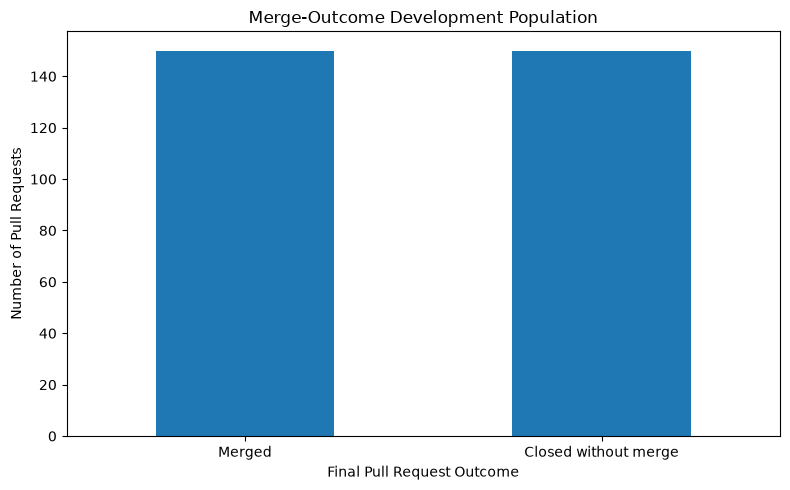

In [133]:
# Target distribution plot

plt.figure(figsize=(8, 5))

target_counts = (
    model1_eda_df["outcome_label"]
    .value_counts()
    .reindex(
        [
            "Merged",
            "Closed without merge",
        ]
    )
)

target_counts.plot(kind="bar")

plt.title("Merge-Outcome Development Population")
plt.xlabel("Final Pull Request Outcome")
plt.ylabel("Number of Pull Requests")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

 # Feature Engineering

In [ ]:
# Creating time based features

model1_eda_df["created_year"] = (model1_eda_df["created_at"].dt.year)

model1_eda_df["created_month"] = (model1_eda_df["created_at"].dt.month)

model1_eda_df["created_day_of_week"] = (model1_eda_df["created_at"].dt.dayofweek)

model1_eda_df["created_hour_utc"] = (model1_eda_df["created_at"].dt.hour)

model1_eda_df["created_on_weekend"] = (model1_eda_df["created_day_of_week"].isin([5, 6]))

day_name_mapping = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

model1_eda_df["created_day_name"] = (
    model1_eda_df["created_day_of_week"]
    .map(day_name_mapping)
)

display(
    model1_eda_df[
        [
            "pr_number",
            "created_at",
            "created_year",
            "created_month",
            "created_day_name",
            "created_hour_utc",
            "created_on_weekend",
        ]
    ].head()
)

,pr_number,created_at,created_year,created_month,created_day_name,created_hour_utc,created_on_weekend
0,5108,2023-05-02 14:07:29+00:00,2023,5,Tuesday,14,False
1,5109,2023-05-02 14:15:25+00:00,2023,5,Tuesday,14,False
2,5110,2023-05-02 14:35:48+00:00,2023,5,Tuesday,14,False
3,5111,2023-05-02 17:39:58+00:00,2023,5,Tuesday,17,False
4,5126,2023-05-14 15:10:35+00:00,2023,5,Sunday,15,True


In [135]:
# Creating description quality indicators

model1_eda_df["has_description"] = (model1_eda_df["body_length"] > 0)

model1_eda_df["has_detailed_description"] = (model1_eda_df["body_word_count"] >= 50)

model1_eda_df["short_title"] = (model1_eda_df["title_length"] < 15)

display(
    model1_eda_df[
        [
            "pr_number",
            "title_length",
            "body_word_count",
            "has_description",
            "has_detailed_description",
            "short_title",
        ]
    ].head()
)

,pr_number,title_length,body_word_count,has_description,has_detailed_description,short_title
0,5108,28,2,True,False,False
1,5109,66,7,True,False,False
2,5110,21,0,False,False,False
3,5111,12,30,True,False,True
4,5126,50,16,True,False,False


In [136]:
# Creating size related features

model1_eda_df["change_density_per_file"] = np.where(
    model1_eda_df["changed_files"] > 0,
    model1_eda_df["total_changes"]
    / model1_eda_df["changed_files"],
    0.0,
)

model1_eda_df["deletion_ratio"] = np.where(
    model1_eda_df["total_changes"] > 0,
    model1_eda_df["deletions"]
    / model1_eda_df["total_changes"],
    0.0,
)

model1_eda_df["has_zero_code_change"] = (
    model1_eda_df["total_changes"] == 0
)

display(
    model1_eda_df[
        [
            "pr_number",
            "total_changes",
            "changed_files",
            "change_density_per_file",
            "deletion_ratio",
            "has_zero_code_change",
        ]
    ].head()
)

,pr_number,total_changes,changed_files,change_density_per_file,deletion_ratio,has_zero_code_change
0,5108,19,2,9.500000,0.157895,False
1,5109,34,3,11.333333,0.117647,False
2,5110,4,2,2.000000,0.500000,False
3,5111,178,5,35.600000,0.668539,False
4,5126,8,1,8.000000,0.375000,False


In [ ]:
# creating repository role groups to simplify GitHub’s detailed association values into business friendly groups.

model1_eda_df["author_role_group"] = (model1_eda_df["author_association"].fillna("UNKNOWN").replace(
        {
            "OWNER": "Internal or trusted",
            "MEMBER": "Internal or trusted",
            "COLLABORATOR": "Internal or trusted",
            "CONTRIBUTOR": "Previous contributor",
            "FIRST_TIME_CONTRIBUTOR": "New contributor",
            "FIRST_TIMER": "New contributor",
            "NONE": "External or unknown",
        }
    )
)

display(
    model1_eda_df[
        [
            "author_association",
            "author_role_group",
        ]
    ].drop_duplicates()
)

,author_association,author_role_group
0,MEMBER,Internal or trusted
6,CONTRIBUTOR,Previous contributor
83,NONE,External or unknown


# Comparing merged and unmerged PRs

In [138]:
# Comparing numerical feature medians

model1_numeric_eda_features = [
    "title_length",
    "body_length",
    "body_word_count",
    "log1p_body_length",
    "log1p_body_word_count",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "log1p_additions",
    "log1p_deletions",
    "log1p_total_changes",
    "log1p_changed_files",
    "test_files_changed",
    "documentation_files_changed",
    "configuration_files_changed",
    "security_sensitive_files_changed",
    "change_density_per_file",
    "deletion_ratio",
]

available_numeric_eda_features = [
    feature
    for feature in model1_numeric_eda_features
    if feature in model1_eda_df.columns
]

numeric_outcome_comparison_df = (
    model1_eda_df
    .groupby("outcome_label")[
        available_numeric_eda_features
    ]
    .median()
    .T
)

numeric_outcome_comparison_df[
    "Merged minus Closed"
] = (
    numeric_outcome_comparison_df["Merged"]
    - numeric_outcome_comparison_df[
        "Closed without merge"
    ]
)

display(numeric_outcome_comparison_df)

outcome_label,Closed without merge,Merged,Merged minus Closed
title_length,44.500000,37.000000,-7.500000
body_length,714.500000,274.500000,-440.000000
body_word_count,98.500000,38.500000,-60.000000
log1p_body_length,6.572962,5.618546,-0.954415
log1p_body_word_count,4.600145,3.676221,-0.923924
additions,10.000000,5.000000,-5.000000
deletions,1.000000,3.000000,2.000000
total_changes,12.000000,8.000000,-4.000000
changed_files,1.000000,2.000000,1.000000
log1p_additions,2.397895,1.791759,-0.606136


In [139]:
# Reusable categorical outcome function

def calculate_merge_rate(
    dataframe,
    grouping_column,
):
    """
    Calculate PR count and merge rate for each group.
    """

    summary_df = (
        dataframe
        .groupby(
            grouping_column,
            dropna=False,
        )
        .agg(
            pr_count=(
                "pr_number",
                "count",
            ),
            merged_pr_count=(
                "was_merged",
                "sum",
            ),
            merge_rate=(
                "was_merged",
                "mean",
            ),
        )
        .reset_index()
    )

    summary_df["merge_rate_percentage"] = (
        summary_df["merge_rate"]
        * 100
    ).round(2)

    return summary_df.sort_values(
        by=[
            "merge_rate",
            "pr_count",
        ],
        ascending=[
            False,
            False,
        ],
    ).reset_index(drop=True)

In [140]:
# Merge rate by author relationship

author_role_merge_rate_df = (
    calculate_merge_rate(
        dataframe=model1_eda_df,
        grouping_column="author_role_group",
    )
)

display(author_role_merge_rate_df)

,author_role_group,pr_count,merged_pr_count,merge_rate,merge_rate_percentage
0,Internal or trusted,67,67,1.000000,100.00
1,Previous contributor,84,80,0.952381,95.24
2,External or unknown,149,3,0.020134,2.01


In [141]:
# Merge rate by description availability

description_merge_rate_df = (
    calculate_merge_rate(
        dataframe=model1_eda_df,
        grouping_column="has_description",
    )
)

display(description_merge_rate_df)

,has_description,pr_count,merged_pr_count,merge_rate,merge_rate_percentage
0,False,16,15,0.937500,93.75
1,True,284,135,0.475352,47.54


In [142]:
# Merge rate by detailed descripton status

detailed_description_merge_rate_df = (
    calculate_merge_rate(
        dataframe=model1_eda_df,
        grouping_column="has_detailed_description",
    )
)

display(detailed_description_merge_rate_df)

,has_detailed_description,pr_count,merged_pr_count,merge_rate,merge_rate_percentage
0,False,133,80,0.601504,60.15
1,True,167,70,0.419162,41.92


In [143]:
# Merge rate by test changes

test_change_merge_rate_df = (
    calculate_merge_rate(
        dataframe=model1_eda_df,
        grouping_column="has_test_changes",
    )
)

display(test_change_merge_rate_df)

,has_test_changes,pr_count,merged_pr_count,merge_rate,merge_rate_percentage
0,False,236,125,0.529661,52.97
1,True,64,25,0.390625,39.06


In [144]:
# Merge rate by configuration changes

configuration_merge_rate_df = (
    calculate_merge_rate(
        dataframe=model1_eda_df,
        grouping_column="has_configuration_changes",
    )
)

display(configuration_merge_rate_df)

,has_configuration_changes,pr_count,merged_pr_count,merge_rate,merge_rate_percentage
0,True,82,63,0.768293,76.83
1,False,218,87,0.399083,39.91


In [145]:
# Merge rate by security sensitive changes

security_merge_rate_df = (
    calculate_merge_rate(
        dataframe=model1_eda_df,
        grouping_column="has_security_sensitive_changes",
    )
)

display(security_merge_rate_df)

,has_security_sensitive_changes,pr_count,merged_pr_count,merge_rate,merge_rate_percentage
0,True,21,13,0.619048,61.9
1,False,279,137,0.491039,49.1


In [147]:
weekday_merge_rate_df = (
    calculate_merge_rate(
        dataframe=model1_eda_df,
        grouping_column="created_day_name",
    )
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_merge_rate_df["weekday_order"] = (
    weekday_merge_rate_df[
        "created_day_name"
    ].map(
        {
            day: position
            for position, day
            in enumerate(weekday_order)
        }
    )
)

weekday_merge_rate_df = (
    weekday_merge_rate_df
    .sort_values("weekday_order")
    .drop(columns="weekday_order")
    .reset_index(drop=True)
)

display(weekday_merge_rate_df)

,created_day_name,pr_count,merged_pr_count,merge_rate,merge_rate_percentage
0,Monday,45,25,0.555556,55.56
1,Tuesday,49,28,0.571429,57.14
2,Wednesday,44,15,0.340909,34.09
3,Thursday,47,23,0.489362,48.94
4,Friday,31,18,0.580645,58.06
5,Saturday,46,24,0.521739,52.17
6,Sunday,38,17,0.447368,44.74


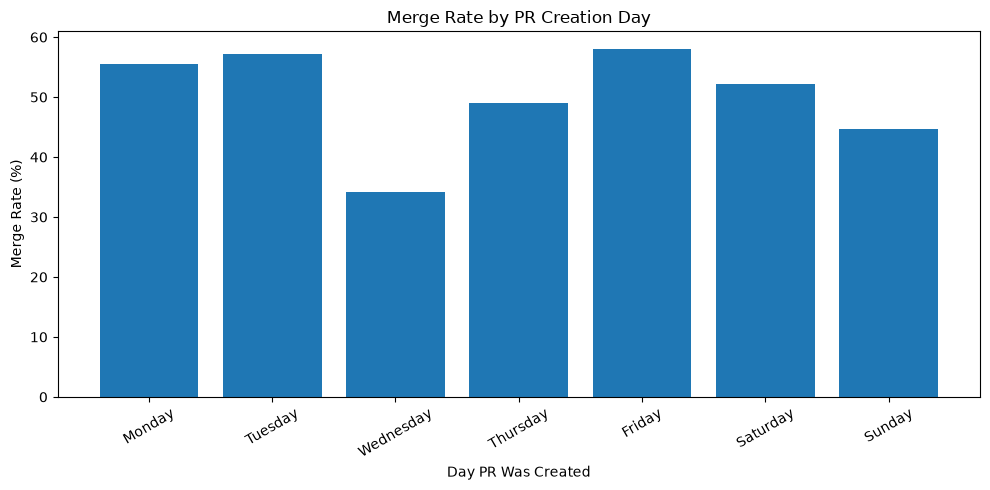

In [148]:
# Merge rate by weekday plot

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_merge_rate_df["created_day_name"],
    weekday_merge_rate_df[
        "merge_rate_percentage"
    ],
)

plt.title("Merge Rate by PR Creation Day")
plt.xlabel("Day PR Was Created")
plt.ylabel("Merge Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Checking class differences visually

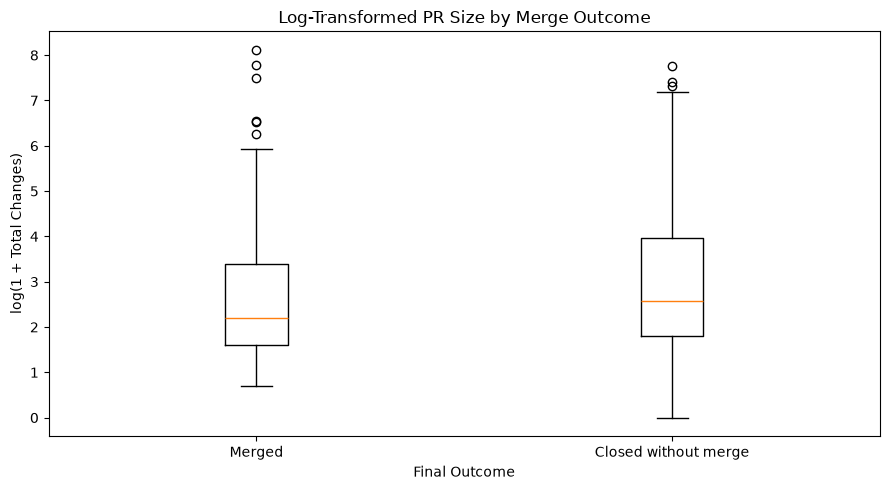

In [149]:
# Total changes by outcome

plot_total_changes_df = model1_eda_df[
    [
        "outcome_label",
        "log1p_total_changes",
    ]
].dropna()

merged_change_values = (
    plot_total_changes_df.loc[
        plot_total_changes_df[
            "outcome_label"
        ] == "Merged",
        "log1p_total_changes",
    ]
)

closed_change_values = (
    plot_total_changes_df.loc[
        plot_total_changes_df[
            "outcome_label"
        ] == "Closed without merge",
        "log1p_total_changes",
    ]
)

plt.figure(figsize=(9, 5))

plt.boxplot(
    [
        merged_change_values,
        closed_change_values,
    ],
    tick_labels=[
        "Merged",
        "Closed without merge",
    ],
)

plt.title(
    "Log-Transformed PR Size by Merge Outcome"
)
plt.xlabel("Final Outcome")
plt.ylabel("log(1 + Total Changes)")

plt.tight_layout()
plt.show()

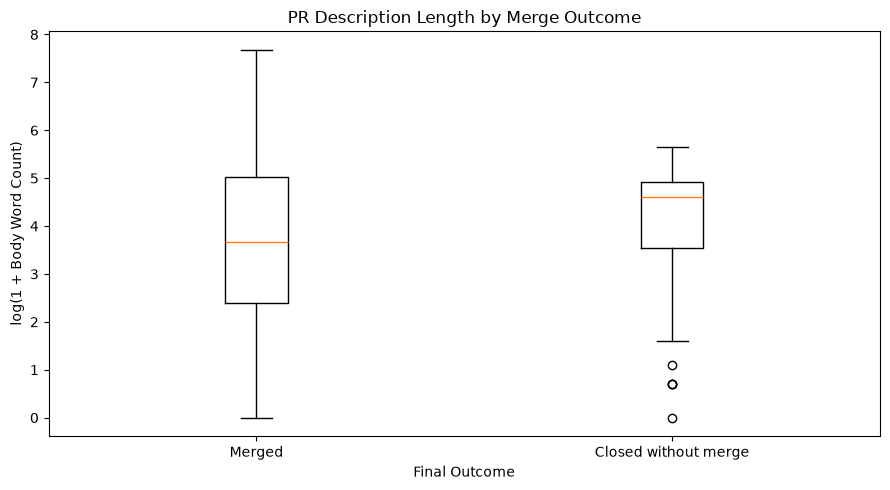

In [150]:
# Description length by outcome

merged_body_values = (
    model1_eda_df.loc[
        model1_eda_df[
            "outcome_label"
        ] == "Merged",
        "log1p_body_word_count",
    ]
)

closed_body_values = (
    model1_eda_df.loc[
        model1_eda_df[
            "outcome_label"
        ] == "Closed without merge",
        "log1p_body_word_count",
    ]
)

plt.figure(figsize=(9, 5))

plt.boxplot(
    [
        merged_body_values,
        closed_body_values,
    ],
    tick_labels=[
        "Merged",
        "Closed without merge",
    ],
)

plt.title(
    "PR Description Length by Merge Outcome"
)
plt.xlabel("Final Outcome")
plt.ylabel("log(1 + Body Word Count)")

plt.tight_layout()
plt.show()

# Initial leakage controlled feature sets

In [ ]:
# Defining the strict early feature set
# This creates a list of features that are already known when the PR is first created

strict_early_numeric_features = [
    "title_length",
    "log1p_body_length",
    "log1p_body_word_count",
    "created_month",
    "created_day_of_week",
    "created_hour_utc",
]

strict_early_boolean_features = [
    "created_on_weekend",
    "has_description",
    "has_detailed_description",
    "short_title",
]

strict_early_categorical_features = [
    "author_association",
    "base_branch",
]

strict_early_features = (
    strict_early_numeric_features
    + strict_early_boolean_features
    + strict_early_categorical_features
)

print(
    "Strict early feature count:",
    len(strict_early_features),
)

print(strict_early_features)

Strict early feature count: 12
['title_length', 'log1p_body_length', 'log1p_body_word_count', 'created_month', 'created_day_of_week', 'created_hour_utc', 'created_on_weekend', 'has_description', 'has_detailed_description', 'short_title', 'author_association', 'base_branch']


In [ ]:
# Defining the historical snapshot benchmark features
# This creates a larger feature list that also includes PR size and changed file information. 
# These values come from the final version of old PRs, so it is mainly used as a comparison benchmark.

snapshot_numeric_features = [
    "title_length",
    "log1p_body_length",
    "log1p_body_word_count",
    "log1p_additions",
    "log1p_deletions",
    "log1p_total_changes",
    "log1p_changed_files",
    "test_files_changed",
    "documentation_files_changed",
    "configuration_files_changed",
    "security_sensitive_files_changed",
    "change_density_per_file",
    "deletion_ratio",
    "created_month",
    "created_day_of_week",
    "created_hour_utc",
]

snapshot_boolean_features = [
    "draft",
    "has_test_changes",
    "has_documentation_changes",
    "has_configuration_changes",
    "has_security_sensitive_changes",
    "created_on_weekend",
    "has_description",
    "has_detailed_description",
    "short_title",
    "has_zero_code_change",
]

snapshot_categorical_features = [
    "author_association",
    "base_branch",
]

snapshot_benchmark_features = (
    snapshot_numeric_features
    + snapshot_boolean_features
    + snapshot_categorical_features
)

print(
    "Snapshot benchmark feature count:",
    len(snapshot_benchmark_features),
)

Snapshot benchmark feature count: 28


In [153]:
# Confirming excluded leakage features

excluded_leakage_features = [
    "updated_at",
    "closed_at",
    "merged_at",
    "was_merged",
    "mergeable_state",
    "commit_count",
    "issue_comment_count",
    "review_comment_count",
    "requested_reviewer_count",
    "review_count",
    "unique_reviewer_count",
    "approved_review_count",
    "changes_requested_count",
    "commented_review_count",
    "dismissed_review_count",
    "first_review_at",
    "first_review_hours",
    "ci_check_count",
    "ci_success_count",
    "ci_failure_count",
    "ci_cancelled_count",
    "ci_neutral_count",
    "ci_skipped_count",
    "ci_other_count",
    "ci_has_failure",
    "resolution_hours",
    "merge_hours",
]

leakage_check_records = []

for feature in excluded_leakage_features:
    leakage_check_records.append(
        {
            "feature": feature,
            "exists_in_dataset": (
                feature in model1_eda_df.columns
            ),
            "included_in_strict_model": (
                feature in strict_early_features
            ),
            "included_in_snapshot_model": (
                feature in snapshot_benchmark_features
            ),
        }
    )

leakage_check_df = pd.DataFrame(
    leakage_check_records
)

display(leakage_check_df)

,feature,exists_in_dataset,included_in_strict_model,included_in_snapshot_model
0,updated_at,True,False,False
1,closed_at,True,False,False
2,merged_at,True,False,False
3,was_merged,True,False,False
4,mergeable_state,True,False,False
5,commit_count,True,False,False
6,issue_comment_count,True,False,False
7,review_comment_count,True,False,False
8,requested_reviewer_count,True,False,False
9,review_count,True,False,False


In [154]:
# Saving post EDA dataset

model1_eda_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_merge_outcome_eda_ready.csv"
)

numeric_comparison_file = (
    EVALUATION_DIR
    / "merge_outcome_numeric_comparison.csv"
)

strict_feature_file = (
    EVALUATION_DIR
    / "model1_strict_early_features.csv"
)

snapshot_feature_file = (
    EVALUATION_DIR
    / "model1_snapshot_benchmark_features.csv"
)

model1_eda_df.to_csv(
    model1_eda_file,
    index=False,
    encoding="utf-8",
)

numeric_outcome_comparison_df.to_csv(
    numeric_comparison_file,
    encoding="utf-8",
)

pd.DataFrame(
    {"feature": strict_early_features}
).to_csv(
    strict_feature_file,
    index=False,
    encoding="utf-8",
)

pd.DataFrame(
    {"feature": snapshot_benchmark_features}
).to_csv(
    snapshot_feature_file,
    index=False,
    encoding="utf-8",
)

print("EDA-ready dataset:")
print(model1_eda_file)

print("\nStrict feature list:")
print(strict_feature_file)

print("\nSnapshot benchmark feature list:")
print(snapshot_feature_file)

EDA-ready dataset:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_merge_outcome_eda_ready.csv

Strict feature list:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\model1_strict_early_features.csv

Snapshot benchmark feature list:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\model1_snapshot_benchmark_features.csv


# Splitting the dataset into Test, Validation and Train datasets for model building
The records are divided according to pull request creation time rather than randomly.

Older pull requests are used to train the model, while newer pull requests are used to evaluate whether the model can generalize to future pull requests.


In [155]:
# Confirming the required columns

required_split_columns = [
    "pr_number",
    "created_at",
    "was_merged",
]

missing_split_columns = [
    column
    for column in required_split_columns
    if column not in model1_eda_df.columns
]

if missing_split_columns:
    raise ValueError(
        f"Missing required columns: {missing_split_columns}"
    )

print("Required split columns are available.")

Required split columns are available.


In [156]:
# Preparing the modelling dataset

model1_data_df = (
    model1_eda_df
    .copy()
    .sort_values(
        by="created_at",
        ascending=True,
    )
    .reset_index(drop=True)
)

model1_data_df["merge_target"] = (
    model1_data_df["was_merged"]
    .astype(int)
)

print("Total records:", len(model1_data_df))
print(
    "Oldest PR:",
    model1_data_df["created_at"].min(),
)
print(
    "Newest PR:",
    model1_data_df["created_at"].max(),
)

Total records: 300
Oldest PR: 2023-05-02 14:07:29+00:00
Newest PR: 2026-07-27 20:04:49+00:00


In [157]:
# Defining split percentage
# 70% train, 15% validation, 15% test

TRAIN_PERCENTAGE = 0.70
VALIDATION_PERCENTAGE = 0.15
TEST_PERCENTAGE = 0.15

total_records = len(model1_data_df)

train_end_position = int(
    total_records * TRAIN_PERCENTAGE
)

validation_end_position = int(
    total_records
    * (
        TRAIN_PERCENTAGE
        + VALIDATION_PERCENTAGE
    )
)

print("Total records:", total_records)
print("Training end position:", train_end_position)
print(
    "Validation end position:",
    validation_end_position,
)

Total records: 300
Training end position: 210
Validation end position: 255


In [158]:
test_start_position = validation_end_position

print("Total records:", total_records)
print("Training end position:", train_end_position)
print("Validation end position:", validation_end_position)
print("Test start position:", test_start_position)
print("Expected test records:", total_records - test_start_position)

Total records: 300
Training end position: 210
Validation end position: 255
Test start position: 255
Expected test records: 45


In [159]:
train_df = model1_data_df.iloc[:210].copy()

validation_df = model1_data_df.iloc[210:255].copy()

test_df = model1_data_df.iloc[255:].copy()

print("Training records:", len(train_df))
print("Validation records:", len(validation_df))
print("Test records:", len(test_df))

Training records: 210
Validation records: 45
Test records: 45


In [161]:
# Checking date range

split_date_summary = [
    {
        "split": "Training",
        "record_count": len(train_df),
        "start_date": train_df[
            "created_at"
        ].min(),
        "end_date": train_df[
            "created_at"
        ].max(),
    },
    {
        "split": "Validation",
        "record_count": len(
            validation_df
        ),
        "start_date": validation_df[
            "created_at"
        ].min(),
        "end_date": validation_df[
            "created_at"
        ].max(),
    },
    {
        "split": "Test",
        "record_count": len(test_df),
        "start_date": test_df[
            "created_at"
        ].min(),
        "end_date": test_df[
            "created_at"
        ].max(),
    },
]

split_date_summary_df = pd.DataFrame(
    split_date_summary
)

display(split_date_summary_df)

,split,record_count,start_date,end_date
0,Training,210,2023-05-02 14:07:29+00:00,2026-03-15 17:25:49+00:00
1,Validation,45,2026-03-17 13:01:28+00:00,2026-05-24 23:39:08+00:00
2,Test,45,2026-05-24 23:40:20+00:00,2026-07-27 20:04:49+00:00


In [162]:
# checking target balance in each split

def summarize_split_target(
    dataframe,
    split_name,
):
    """
    Summarize merge outcomes for one split.
    """

    total = len(dataframe)

    merged_count = int(
        dataframe["merge_target"].sum()
    )

    unmerged_count = (
        total - merged_count
    )

    return {
        "split": split_name,
        "total_records": total,
        "merged_records": merged_count,
        "unmerged_records": unmerged_count,
        "merged_percentage": round(
            merged_count / total * 100,
            2,
        ),
        "unmerged_percentage": round(
            unmerged_count / total * 100,
            2,
        ),
    }

In [163]:
split_target_summary_df = pd.DataFrame(
    [
        summarize_split_target(
            train_df,
            "Training",
        ),
        summarize_split_target(
            validation_df,
            "Validation",
        ),
        summarize_split_target(
            test_df,
            "Test",
        ),
    ]
)

display(split_target_summary_df)

,split,total_records,merged_records,unmerged_records,merged_percentage,unmerged_percentage
0,Training,210,148,62,70.48,29.52
1,Validation,45,2,43,4.44,95.56
2,Test,45,0,45,0.00,100.00


In [164]:
outcome_date_summary_df = (
    model1_data_df
    .groupby("outcome_label")
    .agg(
        record_count=("pr_number", "count"),
        oldest_created_at=("created_at", "min"),
        newest_created_at=("created_at", "max"),
        median_created_at=("created_at", "median"),
    )
    .reset_index()
)

display(outcome_date_summary_df)

,outcome_label,record_count,oldest_created_at,newest_created_at,median_created_at
0,Closed without merge,150,2025-10-19 10:08:40+00:00,2026-07-27 20:04:49+00:00,2026-04-07 08:18:01+00:00
1,Merged,150,2023-05-02 14:07:29+00:00,2026-05-02 03:56:17+00:00,2024-05-06 19:42:32+00:00


In [165]:
outcome_by_year_df = (
    model1_data_df
    .groupby(
        [
            "created_year",
            "outcome_label",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

display(outcome_by_year_df)

outcome_label,created_year,Closed without merge,Merged
0,2023,0,53
1,2024,0,59
2,2025,31,28
3,2026,119,10


Important project insight - A balanced target count is not enough. Both classes must also be reasonably aligned across time.

In [166]:
monthly_outcome_summary_df = (
    model1_data_df
    .assign(
        created_month_period=(
            model1_data_df["created_at"]
            .dt.to_period("M")
            .astype(str)
        )
    )
    .groupby(
        [
            "created_month_period",
            "outcome_label",
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(monthly_outcome_summary_df)

outcome_label,created_month_period,Closed without merge,Merged
0,2023-05,0,8
1,2023-06,0,9
2,2023-07,0,6
3,2023-08,0,10
4,2023-09,0,6
5,2023-10,0,5
6,2023-11,0,5
7,2023-12,0,4
8,2024-01,0,7
9,2024-02,0,5


# Insight:

Identified temporal sampling bias in the initial dataset and redesigned extraction using time-stratified sampling to align merged and unmerged pull requests across comparable historical periods.

# Correcting Temporal Sampling Bias

The initial balanced dataset contained equal numbers of merged and unmerged pull
requests, but the two outcomes came from substantially different periods (merged PRs were mainly older and unmerged PRs were mainly newer.)

This could cause the model to learn time related differences (date) rather than
genuine pull request characteristics.

The dataset will therefore be rebuilt using time stratified sampling, where
merged and unmerged pull requests are collected from matching historical
periods.

Workflow:

1. Data collection
2. Inspecting class distribution
3. Inspecting time distribution
4. Detecting sampling bias
5. Redesigning the sample
6. Splitting chronologically
7. Model training and evaluation

In [167]:
# Counting PR outcomes by year directly from GitHub

def get_github_search_count(search_query):
    """
    Return the total number of GitHub search results
    without downloading all records.
    """

    response = github_get(
        endpoint="/search/issues",
        params={
            "q": search_query,
            "per_page": 1,
            "page": 1,
        },
    )

    return int(
        response.json().get(
            "total_count",
            0,
        )
    )

In [168]:
population_years = [
    2023,
    2024,
    2025,
    2026,
]

yearly_population_records = []

for year in population_years:
    date_range = (
        f"{year}-01-01.."
        f"{year}-12-31"
    )

    all_closed_query = (
        f"repo:{REPOSITORY_FULL_NAME} "
        f"is:pr is:closed "
        f"created:{date_range}"
    )

    merged_query = (
        f"repo:{REPOSITORY_FULL_NAME} "
        f"is:pr is:merged "
        f"created:{date_range}"
    )

    unmerged_query = (
        f"repo:{REPOSITORY_FULL_NAME} "
        f"is:pr is:closed -is:merged "
        f"created:{date_range}"
    )

    total_closed_count = (
        get_github_search_count(
            all_closed_query
        )
    )

    merged_count = (
        get_github_search_count(
            merged_query
        )
    )

    unmerged_count = (
        get_github_search_count(
            unmerged_query
        )
    )

    yearly_population_records.append(
        {
            "created_year": year,
            "total_closed_prs": total_closed_count,
            "merged_prs": merged_count,
            "closed_without_merge_prs": unmerged_count,
            "merge_rate_percentage": round(
                merged_count
                / total_closed_count
                * 100,
                2,
            )
            if total_closed_count > 0
            else np.nan,
            "count_consistency_check": (
                merged_count
                + unmerged_count
                == total_closed_count
            ),
        }
    )

    print(
        f"{year}: "
        f"{merged_count} merged, "
        f"{unmerged_count} unmerged"
    )

yearly_population_df = pd.DataFrame(
    yearly_population_records
)

display(yearly_population_df)

2026-07-30 02:07:09,171 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+created%3A2023-01-01..2023-12-31&per_page=1&page=1 | status=200 | remaining=29
2026-07-30 02:07:09,773 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Amerged+created%3A2023-01-01..2023-12-31&per_page=1&page=1 | status=200 | remaining=28
2026-07-30 02:07:10,367 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+-is%3Amerged+created%3A2023-01-01..2023-12-31&per_page=1&page=1 | status=200 | remaining=27


2023: 111 merged, 81 unmerged


2026-07-30 02:07:11,005 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+created%3A2024-01-01..2024-12-31&per_page=1&page=1 | status=200 | remaining=26
2026-07-30 02:07:11,721 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Amerged+created%3A2024-01-01..2024-12-31&per_page=1&page=1 | status=200 | remaining=25
2026-07-30 02:07:12,440 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+-is%3Amerged+created%3A2024-01-01..2024-12-31&per_page=1&page=1 | status=200 | remaining=24


2024: 59 merged, 51 unmerged


2026-07-30 02:07:13,250 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+created%3A2025-01-01..2025-12-31&per_page=1&page=1 | status=200 | remaining=23
2026-07-30 02:07:13,849 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Amerged+created%3A2025-01-01..2025-12-31&per_page=1&page=1 | status=200 | remaining=22
2026-07-30 02:07:14,460 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+-is%3Amerged+created%3A2025-01-01..2025-12-31&per_page=1&page=1 | status=200 | remaining=21


2025: 28 merged, 100 unmerged


2026-07-30 02:07:15,019 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+created%3A2026-01-01..2026-12-31&per_page=1&page=1 | status=200 | remaining=20
2026-07-30 02:07:15,607 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Amerged+created%3A2026-01-01..2026-12-31&per_page=1&page=1 | status=200 | remaining=19
2026-07-30 02:07:16,215 | INFO | GET https://api.github.com/search/issues?q=repo%3Apallets%2Fflask+is%3Apr+is%3Aclosed+-is%3Amerged+created%3A2026-01-01..2026-12-31&per_page=1&page=1 | status=200 | remaining=18


2026: 10 merged, 119 unmerged


,created_year,total_closed_prs,merged_prs,closed_without_merge_prs,merge_rate_percentage,count_consistency_check
0,2023,192,111,81,57.81,True
1,2024,110,59,51,53.64,True
2,2025,128,28,100,21.88,True
3,2026,129,10,119,7.75,True


In [169]:
# Validating github counts

invalid_population_counts_df = (
    yearly_population_df.loc[
        ~yearly_population_df[
            "count_consistency_check"
        ]
    ]
)

print(
    "Years with inconsistent counts:",
    len(invalid_population_counts_df),
)

display(
    invalid_population_counts_df
)

Years with inconsistent counts: 0


,created_year,total_closed_prs,merged_prs,closed_without_merge_prs,merge_rate_percentage,count_consistency_check


In [ ]:
# Calculating safe sample sizes

MAX_RECORDS_PER_OUTCOME_PER_YEAR = 40

yearly_population_df[
    "merged_sample_size"
] = yearly_population_df[
    "merged_prs"
].clip(
    upper=MAX_RECORDS_PER_OUTCOME_PER_YEAR
)

yearly_population_df[
    "unmerged_sample_size"
] = yearly_population_df[
    "closed_without_merge_prs"
].clip(
    upper=MAX_RECORDS_PER_OUTCOME_PER_YEAR
)

yearly_population_df[
    "balanced_sample_per_outcome"
] = (
    yearly_population_df[
        [
            "merged_sample_size",
            "unmerged_sample_size",
        ]
    ]
    .min(axis=1)
    .astype(int)
)

yearly_population_df[
    "planned_year_total"
] = (
    yearly_population_df[
        "balanced_sample_per_outcome"
    ]
    * 2
)

display(
    yearly_population_df[
        [
            "created_year",
            "merged_prs",
            "closed_without_merge_prs",
            "balanced_sample_per_outcome",
            "planned_year_total",
        ]
    ]
)

# Building a Time Matched 600 PR Population

The first step is not extraction. First, we check how many merged and unmerged PRs are available in each quarter.

In [189]:
GITHUB_BASE_URL = "https://api.github.com"

TARGET_PER_OUTCOME = 300
TARGET_TOTAL_PRS = 600

START_YEAR = 2018

# Prevent one quarter from dominating the dataset.
MAX_PER_OUTCOME_PER_QUARTER = 25

print("Repository:", REPOSITORY_FULL_NAME)
print("Target merged PRs:", TARGET_PER_OUTCOME)
print("Target unmerged PRs:", TARGET_PER_OUTCOME)
print("Target total PRs:", TARGET_TOTAL_PRS)

Repository: pallets/flask
Target merged PRs: 300
Target unmerged PRs: 300
Target total PRs: 600


In [190]:
# Generating quarter windows

# Important issue is with 2026-Q3 and Q4. The current date is July 2026. Therefore 2026-Q3 is incomplete, 2026-Q4 is still in the future.
# We should not include future or incomplete quarters in the main historical population design.

today_utc = pd.Timestamp.now(
    tz="UTC"
).normalize()

current_year = today_utc.year

quarter_definitions = [
    {
        "quarter": "Q1",
        "start_month": 1,
        "start_day": 1,
        "end_month": 3,
        "end_day": 31,
    },
    {
        "quarter": "Q2",
        "start_month": 4,
        "start_day": 1,
        "end_month": 6,
        "end_day": 30,
    },
    {
        "quarter": "Q3",
        "start_month": 7,
        "start_day": 1,
        "end_month": 9,
        "end_day": 30,
    },
    {
        "quarter": "Q4",
        "start_month": 10,
        "start_day": 1,
        "end_month": 12,
        "end_day": 31,
    },
]

quarter_window_records = []

for year in range(
    START_YEAR,
    current_year + 1,
):
    for quarter_info in quarter_definitions:
        start_date = pd.Timestamp(
            year=year,
            month=quarter_info["start_month"],
            day=quarter_info["start_day"],
            tz="UTC",
        )

        end_date = pd.Timestamp(
            year=year,
            month=quarter_info["end_month"],
            day=quarter_info["end_day"],
            tz="UTC",
        )

        # Include only fully completed quarters.
        if end_date >= today_utc:
            continue

        quarter_window_records.append(
            {
                "year": year,
                "quarter": quarter_info["quarter"],
                "period": (
                    f"{year}-"
                    f"{quarter_info['quarter']}"
                ),
                "start_date": (
                    start_date.strftime("%Y-%m-%d")
                ),
                "end_date": (
                    end_date.strftime("%Y-%m-%d")
                ),
            }
        )

quarter_windows_df = pd.DataFrame(
    quarter_window_records
)

print(
    "Completed quarters created:",
    len(quarter_windows_df),
)

display(
    quarter_windows_df.tail(10)
)

Completed quarters created: 34


,year,quarter,period,start_date,end_date
24,2024,Q1,2024-Q1,2024-01-01,2024-03-31
25,2024,Q2,2024-Q2,2024-04-01,2024-06-30
26,2024,Q3,2024-Q3,2024-07-01,2024-09-30
27,2024,Q4,2024-Q4,2024-10-01,2024-12-31
28,2025,Q1,2025-Q1,2025-01-01,2025-03-31
29,2025,Q2,2025-Q2,2025-04-01,2025-06-30
30,2025,Q3,2025-Q3,2025-07-01,2025-09-30
31,2025,Q4,2025-Q4,2025-10-01,2025-12-31
32,2026,Q1,2026-Q1,2026-01-01,2026-03-31
33,2026,Q2,2026-Q2,2026-04-01,2026-06-30


In [191]:
# handling GitHub search rate 

# Defining checkpoint files

quarterly_availability_checkpoint_file = (
    CACHE_DIR
    / "time_matched_quarterly_availability.csv"
)

selected_population_checkpoint_file = (
    CACHE_DIR
    / "time_matched_selected_population_checkpoint.csv"
)

final_population_file = (
    RAW_DATA_DIR
    / "pallets_flask_time_matched_600_pr_population.csv"
)

availability_report_file = (
    EVALUATION_DIR
    / "time_matched_quarterly_availability.csv"
)

sampling_plan_file = (
    EVALUATION_DIR
    / "time_matched_sampling_plan.csv"
)

print("Availability checkpoint:")
print(quarterly_availability_checkpoint_file)

print("\nFinal population:")
print(final_population_file)

Availability checkpoint:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\cache\time_matched_quarterly_availability.csv

Final population:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\raw\pallets_flask_time_matched_600_pr_population.csv


In [192]:
# GitHub search rate status

def get_search_rate_limit():
    """
    Return GitHub Search API rate-limit information.
    """

    response = github_session.get(
        f"{GITHUB_BASE_URL}/rate_limit",
        timeout=30,
    )

    response.raise_for_status()

    return (
        response.json()
        ["resources"]
        ["search"]
    )

In [193]:
search_limit = get_search_rate_limit()

print(
    "Search limit:",
    search_limit["limit"],
)

print(
    "Search requests remaining:",
    search_limit["remaining"],
)

print(
    "Reset time:",
    datetime.fromtimestamp(
        int(search_limit["reset"]),
        tz=timezone.utc,
    ),
)

Search limit: 30
Search requests remaining: 30
Reset time: 2026-07-29 22:42:54+00:00


In [194]:
# Creating an automatic waiting function

def wait_for_search_capacity(
    requests_required=1,
):
    """
    Wait until GitHub Search API has enough
    requests available.
    """

    while True:
        search_limit = get_search_rate_limit()

        remaining = int(
            search_limit["remaining"]
        )

        if remaining >= requests_required:
            return

        reset_timestamp = int(
            search_limit["reset"]
        )

        current_timestamp = int(
            time.time()
        )

        wait_seconds = max(
            reset_timestamp
            - current_timestamp
            + 5,
            5,
        )

        reset_time = datetime.fromtimestamp(
            reset_timestamp,
            tz=timezone.utc,
        )

        print(
            "\nGitHub search limit reached."
        )

        print(
            "Search limit resets at:",
            reset_time,
        )

        print(
            "Waiting",
            wait_seconds,
            "seconds..."
        )

        time.sleep(wait_seconds)

In [195]:
# Creating a safe GitHub search request

def github_search_request(
    search_query,
    per_page=1,
    page=1,
    sort="created",
    order="asc",
):
    """
    Send one GitHub Search API request.

    Handles normal and secondary rate limits.
    """

    while True:
        wait_for_search_capacity(
            requests_required=1
        )

        response = github_session.get(
            f"{GITHUB_BASE_URL}/search/issues",
            params={
                "q": search_query,
                "per_page": per_page,
                "page": page,
                "sort": sort,
                "order": order,
            },
            timeout=60,
        )

        if response.status_code == 200:
            return response.json()

        message = ""

        try:
            message = (
                response.json()
                .get("message", "")
            )
        except ValueError:
            message = response.text

        remaining = response.headers.get(
            "X-RateLimit-Remaining"
        )

        retry_after = response.headers.get(
            "Retry-After"
        )

        message_lower = message.lower()

        normal_rate_limit = (
            remaining == "0"
            or "rate limit exceeded"
            in message_lower
        )

        secondary_rate_limit = (
            "secondary rate limit"
            in message_lower
            or "abuse detection"
            in message_lower
            or response.status_code == 429
        )

        if normal_rate_limit:
            print(
                "\nGitHub search rate limit reached."
            )
            continue

        if secondary_rate_limit:
            wait_seconds = (
                int(retry_after)
                if retry_after
                else 60
            )

            print(
                "\nGitHub secondary rate limit reached."
            )

            print(
                "Waiting",
                wait_seconds,
                "seconds..."
            )

            time.sleep(wait_seconds)
            continue

        raise PermissionError(
            "GitHub search request failed. "
            f"Status: {response.status_code}. "
            f"Message: {message}"
        )

In [196]:
# Count available PRs by quarter

# Creating the search count helper

def get_github_search_count(
    search_query,
):
    """
    Return the total number of records matching
    a GitHub search query.
    """

    search_data = github_search_request(
        search_query=search_query,
        per_page=1,
        page=1,
    )

    return int(
        search_data.get(
            "total_count",
            0,
        )
    )

In [197]:
# Loading any saved availability progress

if quarterly_availability_checkpoint_file.exists():
    quarterly_availability_df = pd.read_csv(
        quarterly_availability_checkpoint_file
    )

    quarterly_availability_records = (
        quarterly_availability_df
        .to_dict("records")
    )

    completed_availability_periods = set(
        quarterly_availability_df[
            "period"
        ].astype(str)
    )

else:
    quarterly_availability_records = []
    completed_availability_periods = set()

print(
    "Previously completed quarters:",
    len(completed_availability_periods),
)

print(
    "Remaining quarters:",
    len(quarter_windows_df)
    - len(completed_availability_periods),
)

Previously completed quarters: 0
Remaining quarters: 34


In [198]:
# Counting merged and unmerged PRs

for _, quarter_row in (
    quarter_windows_df.iterrows()
):
    period = str(
        quarter_row["period"]
    )

    if period in completed_availability_periods:
        print(
            f"{period}: already completed"
        )
        continue

    start_date = str(
        quarter_row["start_date"]
    )

    end_date = str(
        quarter_row["end_date"]
    )

    date_filter = (
        f"{start_date}..{end_date}"
    )

    merged_query = (
        f"repo:{REPOSITORY_FULL_NAME} "
        f"is:pr is:merged "
        f"created:{date_filter}"
    )

    unmerged_query = (
        f"repo:{REPOSITORY_FULL_NAME} "
        f"is:pr is:closed -is:merged "
        f"created:{date_filter}"
    )

    merged_count = (
        get_github_search_count(
            merged_query
        )
    )

    # Small pause reduces secondary-rate-limit risk.
    time.sleep(2)

    unmerged_count = (
        get_github_search_count(
            unmerged_query
        )
    )

    quarter_record = {
        "year": int(
            quarter_row["year"]
        ),
        "quarter": quarter_row[
            "quarter"
        ],
        "period": period,
        "start_date": start_date,
        "end_date": end_date,
        "merged_available": int(
            merged_count
        ),
        "unmerged_available": int(
            unmerged_count
        ),
    }

    quarterly_availability_records.append(
        quarter_record
    )

    completed_availability_periods.add(
        period
    )

    quarterly_availability_df = (
        pd.DataFrame(
            quarterly_availability_records
        )
        .drop_duplicates(
            subset=["period"],
            keep="last",
        )
        .sort_values(
            by=[
                "year",
                "quarter",
            ]
        )
        .reset_index(drop=True)
    )

    quarterly_availability_df.to_csv(
        quarterly_availability_checkpoint_file,
        index=False,
        encoding="utf-8",
    )

    print(
        f"{period}: "
        f"{merged_count} merged, "
        f"{unmerged_count} unmerged"
    )

    time.sleep(2)

print("\nQuarterly availability collection complete.")

2018-Q1: 29 merged, 15 unmerged
2018-Q2: 55 merged, 22 unmerged
2018-Q3: 17 merged, 12 unmerged
2018-Q4: 28 merged, 22 unmerged
2019-Q1: 21 merged, 10 unmerged
2019-Q2: 59 merged, 22 unmerged
2019-Q3: 25 merged, 15 unmerged
2019-Q4: 18 merged, 12 unmerged
2020-Q1: 21 merged, 11 unmerged
2020-Q2: 29 merged, 21 unmerged
2020-Q3: 44 merged, 17 unmerged
2020-Q4: 24 merged, 26 unmerged
2021-Q1: 36 merged, 16 unmerged
2021-Q2: 82 merged, 36 unmerged
2021-Q3: 32 merged, 17 unmerged
2021-Q4: 28 merged, 42 unmerged
2022-Q1: 28 merged, 18 unmerged
2022-Q2: 46 merged, 18 unmerged
2022-Q3: 41 merged, 24 unmerged
2022-Q4: 16 merged, 25 unmerged
2023-Q1: 32 merged, 15 unmerged
2023-Q2: 43 merged, 22 unmerged
2023-Q3: 22 merged, 20 unmerged
2023-Q4: 14 merged, 24 unmerged
2024-Q1: 12 merged, 13 unmerged
2024-Q2: 19 merged, 15 unmerged
2024-Q3: 9 merged, 17 unmerged
2024-Q4: 19 merged, 6 unmerged
2025-Q1: 6 merged, 14 unmerged
2025-Q2: 9 merged, 25 unmerged
2025-Q3: 9 merged, 28 unmerged
2025-Q4: 4 me

In [199]:
# Loading and inspecting completed availability

quarterly_availability_df = pd.read_csv(
    quarterly_availability_checkpoint_file
)

quarterly_availability_df = (
    quarterly_availability_df
    .sort_values(
        by=[
            "year",
            "quarter",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Completed quarterly periods:",
    len(quarterly_availability_df),
)

display(
    quarterly_availability_df
)

Completed quarterly periods: 34


,year,quarter,period,start_date,end_date,merged_available,unmerged_available
0,2018,Q1,2018-Q1,2018-01-01,2018-03-31,29,15
1,2018,Q2,2018-Q2,2018-04-01,2018-06-30,55,22
2,2018,Q3,2018-Q3,2018-07-01,2018-09-30,17,12
3,2018,Q4,2018-Q4,2018-10-01,2018-12-31,28,22
4,2019,Q1,2019-Q1,2019-01-01,2019-03-31,21,10
5,2019,Q2,2019-Q2,2019-04-01,2019-06-30,59,22
6,2019,Q3,2019-Q3,2019-07-01,2019-09-30,25,15
7,2019,Q4,2019-Q4,2019-10-01,2019-12-31,18,12
8,2020,Q1,2020-Q1,2020-01-01,2020-03-31,21,11
9,2020,Q2,2020-Q2,2020-04-01,2020-06-30,29,21


In [200]:
# Planning the 600 record sample
# Calculating matched capacity

quarterly_availability_df[
    "matched_available"
] = (
    quarterly_availability_df[
        [
            "merged_available",
            "unmerged_available",
        ]
    ]
    .min(axis=1)
    .astype(int)
)

quarterly_availability_df[
    "maximum_allowed_per_outcome"
] = (
    quarterly_availability_df[
        "matched_available"
    ]
    .clip(
        upper=MAX_PER_OUTCOME_PER_QUARTER
    )
    .astype(int)
)

maximum_matched_per_outcome = int(
    quarterly_availability_df[
        "maximum_allowed_per_outcome"
    ].sum()
)

maximum_matched_total = (
    maximum_matched_per_outcome
    * 2
)

print(
    "Maximum matched records per outcome:",
    maximum_matched_per_outcome,
)

print(
    "Maximum matched total records:",
    maximum_matched_total,
)

print(
    "Can create 600-record population:",
    maximum_matched_total
    >= TARGET_TOTAL_PRS,
)

Maximum matched records per outcome: 513
Maximum matched total records: 1026
Can create 600-record population: True


In [201]:
# Allocating 300 PRs to each outcome (This distributes records across quarters rather than allowing one period to dominate.)

sampling_plan_df = (
    quarterly_availability_df
    .copy()
)

sampling_plan_df[
    "planned_per_outcome"
] = 0

records_still_needed = (
    TARGET_PER_OUTCOME
)

while records_still_needed > 0:
    allocation_made = False

    for row_index in (
        sampling_plan_df.index
    ):
        current_allocation = int(
            sampling_plan_df.loc[
                row_index,
                "planned_per_outcome",
            ]
        )

        maximum_allocation = int(
            sampling_plan_df.loc[
                row_index,
                "maximum_allowed_per_outcome",
            ]
        )

        if current_allocation >= maximum_allocation:
            continue

        sampling_plan_df.loc[
            row_index,
            "planned_per_outcome",
        ] += 1

        records_still_needed -= 1
        allocation_made = True

        if records_still_needed == 0:
            break

    if not allocation_made:
        break

sampling_plan_df[
    "planned_total"
] = (
    sampling_plan_df[
        "planned_per_outcome"
    ]
    * 2
)

planned_per_outcome_total = int(
    sampling_plan_df[
        "planned_per_outcome"
    ].sum()
)

planned_population_total = int(
    sampling_plan_df[
        "planned_total"
    ].sum()
)

print(
    "Planned merged PRs:",
    planned_per_outcome_total,
)

print(
    "Planned unmerged PRs:",
    planned_per_outcome_total,
)

print(
    "Planned total PRs:",
    planned_population_total,
)

Planned merged PRs: 300
Planned unmerged PRs: 300
Planned total PRs: 600


In [202]:
# Checking the samping plan

active_sampling_plan_df = (
    sampling_plan_df.loc[
        sampling_plan_df[
            "planned_per_outcome"
        ] > 0
    ]
    .copy()
    .reset_index(drop=True)
)

display(
    active_sampling_plan_df[
        [
            "period",
            "merged_available",
            "unmerged_available",
            "planned_per_outcome",
            "planned_total",
        ]
    ]
)

print(
    "Quarters used:",
    len(active_sampling_plan_df),
)

,period,merged_available,unmerged_available,planned_per_outcome,planned_total
0,2018-Q1,29,15,10,20
1,2018-Q2,55,22,10,20
2,2018-Q3,17,12,10,20
3,2018-Q4,28,22,10,20
4,2019-Q1,21,10,10,20
5,2019-Q2,59,22,10,20
6,2019-Q3,25,15,10,20
7,2019-Q4,18,12,10,20
8,2020-Q1,21,11,10,20
9,2020-Q2,29,21,10,20


Quarters used: 34


In [203]:
# To stop if 600 records are not possible

if planned_population_total < TARGET_TOTAL_PRS:
    raise ValueError(
        "The Flask repository does not have enough "
        "time-matched PRs under the current quarterly cap. "
        f"Only {planned_population_total} records can be planned."
    )

print("The 600-record time-matched plan is valid.")

The 600-record time-matched plan is valid.


In [204]:
# Retrieving PR numbers for the selected population

# Creating a helper to retrieve search results

def retrieve_search_items(
    search_query,
):
    """
    Retrieve GitHub search results across pages.

    GitHub Search returns up to 100 records per page.
    """

    all_items = []
    page_number = 1

    while True:
        search_data = github_search_request(
            search_query=search_query,
            per_page=100,
            page=page_number,
            sort="created",
            order="asc",
        )

        page_items = search_data.get(
            "items",
            []
        )

        if not page_items:
            break

        all_items.extend(
            page_items
        )

        if len(page_items) < 100:
            break

        # GitHub Search exposes at most
        # the first 1,000 results.
        if page_number >= 10:
            break

        page_number += 1
        time.sleep(2)

    return all_items

In [205]:
# Creating evenly distributed sampling

def select_evenly_spaced_items(
    items,
    required_count,
):
    """
    Select records from across the full ordered
    quarterly result rather than only from the start.
    """

    if required_count <= 0:
        return []

    if len(items) <= required_count:
        return items

    selected_positions = np.linspace(
        0,
        len(items) - 1,
        num=required_count,
        dtype=int,
    )

    return [
        items[position]
        for position in selected_positions
    ]

In [206]:
# Loading selected population checkpoint

if selected_population_checkpoint_file.exists():
    selected_population_df = pd.read_csv(
        selected_population_checkpoint_file
    )

    selected_population_records = (
        selected_population_df
        .to_dict("records")
    )

    completed_selection_keys = set(
        zip(
            selected_population_df[
                "period"
            ].astype(str),
            selected_population_df[
                "expected_outcome"
            ].astype(str),
        )
    )

else:
    selected_population_records = []
    completed_selection_keys = set()

print(
    "Previously selected records:",
    len(selected_population_records),
)

print(
    "Completed quarter-outcome groups:",
    len(completed_selection_keys),
)

Previously selected records: 0
Completed quarter-outcome groups: 0


In [207]:
# retrieving and selecting the 600 PRs

for _, plan_row in (
    active_sampling_plan_df.iterrows()
):
    period = str(
        plan_row["period"]
    )

    start_date = str(
        plan_row["start_date"]
    )

    end_date = str(
        plan_row["end_date"]
    )

    required_count = int(
        plan_row["planned_per_outcome"]
    )

    date_filter = (
        f"{start_date}..{end_date}"
    )

    outcome_queries = {
        "Merged": (
            f"repo:{REPOSITORY_FULL_NAME} "
            f"is:pr is:merged "
            f"created:{date_filter}"
        ),

        "Closed without merge": (
            f"repo:{REPOSITORY_FULL_NAME} "
            f"is:pr is:closed -is:merged "
            f"created:{date_filter}"
        ),
    }

    for outcome_name, search_query in (
        outcome_queries.items()
    ):
        selection_key = (
            period,
            outcome_name,
        )

        if selection_key in completed_selection_keys:
            print(
                f"{period} — {outcome_name}: "
                "already selected"
            )
            continue

        available_items = (
            retrieve_search_items(
                search_query
            )
        )

        selected_items = (
            select_evenly_spaced_items(
                items=available_items,
                required_count=required_count,
            )
        )

        if len(selected_items) < required_count:
            raise ValueError(
                f"{period} — {outcome_name}: "
                f"needed {required_count}, but only "
                f"{len(selected_items)} records were retrieved."
            )

        for item in selected_items:
            selected_population_records.append(
                {
                    "repository": (
                        REPOSITORY_FULL_NAME
                    ),
                    "pr_number": int(
                        item["number"]
                    ),
                    "expected_outcome": (
                        outcome_name
                    ),
                    "period": period,
                    "period_start_date": (
                        start_date
                    ),
                    "period_end_date": (
                        end_date
                    ),
                    "created_at": item.get(
                        "created_at"
                    ),
                    "html_url": item.get(
                        "html_url"
                    ),
                }
            )

        completed_selection_keys.add(
            selection_key
        )

        selected_population_df = (
            pd.DataFrame(
                selected_population_records
            )
            .drop_duplicates(
                subset=["pr_number"],
                keep="first",
            )
            .sort_values(
                by=[
                    "created_at",
                    "pr_number",
                ]
            )
            .reset_index(drop=True)
        )

        selected_population_df.to_csv(
            selected_population_checkpoint_file,
            index=False,
            encoding="utf-8",
        )

        print(
            f"{period} — {outcome_name}: "
            f"{len(selected_items)} selected"
        )

        time.sleep(2)

print("\nPopulation selection complete.")

2018-Q1 — Merged: 10 selected
2018-Q1 — Closed without merge: 10 selected
2018-Q2 — Merged: 10 selected
2018-Q2 — Closed without merge: 10 selected
2018-Q3 — Merged: 10 selected
2018-Q3 — Closed without merge: 10 selected
2018-Q4 — Merged: 10 selected
2018-Q4 — Closed without merge: 10 selected
2019-Q1 — Merged: 10 selected
2019-Q1 — Closed without merge: 10 selected
2019-Q2 — Merged: 10 selected
2019-Q2 — Closed without merge: 10 selected
2019-Q3 — Merged: 10 selected
2019-Q3 — Closed without merge: 10 selected
2019-Q4 — Merged: 10 selected
2019-Q4 — Closed without merge: 10 selected
2020-Q1 — Merged: 10 selected
2020-Q1 — Closed without merge: 10 selected
2020-Q2 — Merged: 10 selected
2020-Q2 — Closed without merge: 10 selected
2020-Q3 — Merged: 10 selected
2020-Q3 — Closed without merge: 10 selected
2020-Q4 — Merged: 10 selected
2020-Q4 — Closed without merge: 10 selected
2021-Q1 — Merged: 10 selected
2021-Q1 — Closed without merge: 10 selected
2021-Q2 — Merged: 9 selected
2021-Q2 —

In [208]:
# Validating the new population

# Loading the selected population

selected_population_df = pd.read_csv(
    selected_population_checkpoint_file
)

selected_population_df[
    "created_at"
] = pd.to_datetime(
    selected_population_df[
        "created_at"
    ],
    utc=True,
    errors="coerce",
)

print(
    "Selected population shape:",
    selected_population_df.shape,
)

print(
    "Unique PR numbers:",
    selected_population_df[
        "pr_number"
    ].nunique(),
)

Selected population shape: (600, 8)
Unique PR numbers: 600


In [209]:
# checking outcome counts

selected_outcome_summary_df = (
    selected_population_df[
        "expected_outcome"
    ]
    .value_counts()
    .rename_axis(
        "expected_outcome"
    )
    .reset_index(
        name="record_count"
    )
)

display(
    selected_outcome_summary_df
)

,expected_outcome,record_count
0,Closed without merge,300
1,Merged,300


In [210]:
# Checking duplicates

duplicate_population_prs = int(
    selected_population_df[
        "pr_number"
    ]
    .duplicated()
    .sum()
)

print(
    "Duplicate PR numbers:",
    duplicate_population_prs,
)

if duplicate_population_prs > 0:
    display(
        selected_population_df.loc[
            selected_population_df[
                "pr_number"
            ].duplicated(
                keep=False
            )
        ]
    )

Duplicate PR numbers: 0


In [211]:
# Checking quarterly class alignment

selected_quarterly_summary_df = (
    selected_population_df
    .groupby(
        [
            "period",
            "expected_outcome",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

display(
    selected_quarterly_summary_df
)

expected_outcome,period,Closed without merge,Merged
0,2018-Q1,10,10
1,2018-Q2,10,10
2,2018-Q3,10,10
3,2018-Q4,10,10
4,2019-Q1,10,10
5,2019-Q2,10,10
6,2019-Q3,10,10
7,2019-Q4,10,10
8,2020-Q1,10,10
9,2020-Q2,10,10


In [212]:
# checking date ranges by outcome

selected_date_summary_df = (
    selected_population_df
    .groupby(
        "expected_outcome"
    )
    .agg(
        record_count=(
            "pr_number",
            "count",
        ),
        oldest_created_at=(
            "created_at",
            "min",
        ),
        newest_created_at=(
            "created_at",
            "max",
        ),
        median_created_at=(
            "created_at",
            "median",
        ),
    )
    .reset_index()
)

display(
    selected_date_summary_df
)

,expected_outcome,record_count,oldest_created_at,newest_created_at,median_created_at
0,Closed without merge,300,2018-01-03 10:46:23+00:00,2026-04-07 00:18:44+00:00,2021-10-16 20:04:11.500000+00:00
1,Merged,300,2018-01-03 21:10:09+00:00,2026-05-02 03:56:17+00:00,2021-10-06 02:01:19.500000+00:00


In [213]:
# Final validation

population_validation = {
    "total_records": len(
        selected_population_df
    ),

    "unique_pr_numbers": int(
        selected_population_df[
            "pr_number"
        ].nunique()
    ),

    "merged_records": int(
        (
            selected_population_df[
                "expected_outcome"
            ] == "Merged"
        ).sum()
    ),

    "unmerged_records": int(
        (
            selected_population_df[
                "expected_outcome"
            ] == "Closed without merge"
        ).sum()
    ),

    "duplicate_pr_numbers": int(
        selected_population_df[
            "pr_number"
        ].duplicated().sum()
    ),

    "missing_created_dates": int(
        selected_population_df[
            "created_at"
        ].isna().sum()
    ),
}

population_validation_df = pd.DataFrame(
    population_validation.items(),
    columns=[
        "Validation Metric",
        "Result",
    ],
)

display(
    population_validation_df
)

,Validation Metric,Result
0,total_records,600
1,unique_pr_numbers,600
2,merged_records,300
3,unmerged_records,300
4,duplicate_pr_numbers,0
5,missing_created_dates,0


In [214]:
# saving final population and reports

selected_population_df.to_csv(
    final_population_file,
    index=False,
    encoding="utf-8",
)

quarterly_availability_df.to_csv(
    availability_report_file,
    index=False,
    encoding="utf-8",
)

sampling_plan_df.to_csv(
    sampling_plan_file,
    index=False,
    encoding="utf-8",
)

print("Final 600-PR population saved to:")
print(final_population_file)

print("\nQuarterly availability report:")
print(availability_report_file)

print("\nSampling plan:")
print(sampling_plan_file)

Final 600-PR population saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\raw\pallets_flask_time_matched_600_pr_population.csv

Quarterly availability report:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\time_matched_quarterly_availability.csv

Sampling plan:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\time_matched_sampling_plan.csv


In [215]:
# Defining extraction output files

detailed_extraction_checkpoint_file = (
    CACHE_DIR
    / "time_matched_600_pr_extraction_checkpoint.json"
)

detailed_dataset_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_time_matched_600_detailed.csv"
)

detailed_failures_file = (
    EVALUATION_DIR
    / "time_matched_600_extraction_failures.csv"
)

print("Extraction checkpoint:")
print(detailed_extraction_checkpoint_file)

print("\nDetailed dataset:")
print(detailed_dataset_file)

print("\nFailure report:")
print(detailed_failures_file)

Extraction checkpoint:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\cache\time_matched_600_pr_extraction_checkpoint.json

Detailed dataset:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_time_matched_600_detailed.csv

Failure report:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\time_matched_600_extraction_failures.csv


In [216]:
# Creating a pagination helper

def get_paginated_github_items(
    endpoint,
    per_page=100,
):
    """
    Retrieve all list records from a paginated
    GitHub API endpoint.
    """

    all_items = []
    page_number = 1

    while True:
        response = github_get(
            endpoint=endpoint,
            params={
                "per_page": per_page,
                "page": page_number,
            },
        )

        page_items = response.json()

        if not isinstance(page_items, list):
            raise TypeError(
                f"Expected a list from {endpoint}"
            )

        if not page_items:
            break

        all_items.extend(page_items)

        if len(page_items) < per_page:
            break

        page_number += 1

    return all_items

In [217]:
# Confirming the file summary helper (summarize_changed_files()) exists

required_extraction_functions = [
    "summarize_changed_files",
    "text_length",
]

missing_extraction_functions = [
    function_name
    for function_name
    in required_extraction_functions
    if function_name not in globals()
]

if missing_extraction_functions:
    raise NameError(
        "Rerun the earlier reusable feature-extraction "
        "cells. Missing functions: "
        f"{missing_extraction_functions}"
    )

print("Required extraction functions are available.")

Required extraction functions are available.


In [218]:
# creating light weight core extractor

def extract_core_pull_request(
    pr_number,
):
    """
    Extract core PR information and changed-file
    features for merge-outcome modelling.

    Reviews, comments and CI checks are excluded
    from this extraction stage.
    """

    pull_response = github_get(
        endpoint=(
            f"/repos/{REPOSITORY_FULL_NAME}"
            f"/pulls/{pr_number}"
        )
    )

    pull_data = pull_response.json()

    changed_files = get_paginated_github_items(
        endpoint=(
            f"/repos/{REPOSITORY_FULL_NAME}"
            f"/pulls/{pr_number}/files"
        )
    )

    file_summary = summarize_changed_files(
        changed_files
    )

    created_at = pd.to_datetime(
        pull_data.get("created_at"),
        utc=True,
        errors="coerce",
    )

    closed_at = pd.to_datetime(
        pull_data.get("closed_at"),
        utc=True,
        errors="coerce",
    )

    merged_at = pd.to_datetime(
        pull_data.get("merged_at"),
        utc=True,
        errors="coerce",
    )

    resolution_hours = np.nan

    if pd.notna(created_at) and pd.notna(closed_at):
        resolution_hours = (
            closed_at - created_at
        ).total_seconds() / 3600

    merge_hours = np.nan

    if pd.notna(created_at) and pd.notna(merged_at):
        merge_hours = (
            merged_at - created_at
        ).total_seconds() / 3600

    body_text = pull_data.get("body") or ""
    title_text = pull_data.get("title") or ""

    labels = [
        label.get("name")
        for label in pull_data.get("labels", [])
        if label.get("name")
    ]

    requested_reviewers = [
        reviewer.get("login")
        for reviewer in pull_data.get(
            "requested_reviewers",
            [],
        )
        if reviewer.get("login")
    ]

    record = {
        "repository": REPOSITORY_FULL_NAME,
        "pr_number": int(pr_number),
        "title": title_text,
        "body": body_text,
        "html_url": pull_data.get("html_url"),

        "author_login": (
            pull_data.get("user", {})
            .get("login")
        ),
        "author_association": pull_data.get(
            "author_association"
        ),

        "state": pull_data.get("state"),
        "draft": bool(
            pull_data.get("draft", False)
        ),

        "base_branch": (
            pull_data.get("base", {})
            .get("ref")
        ),
        "head_branch": (
            pull_data.get("head", {})
            .get("ref")
        ),

        "created_at": created_at,
        "updated_at": pd.to_datetime(
            pull_data.get("updated_at"),
            utc=True,
            errors="coerce",
        ),
        "closed_at": closed_at,
        "merged_at": merged_at,

        "was_merged": pd.notna(merged_at),
        "resolution_hours": resolution_hours,
        "merge_hours": merge_hours,

        "additions": int(
            pull_data.get("additions") or 0
        ),
        "deletions": int(
            pull_data.get("deletions") or 0
        ),
        "total_changes": int(
            (pull_data.get("additions") or 0)
            + (pull_data.get("deletions") or 0)
        ),
        "changed_files": int(
            pull_data.get("changed_files") or 0
        ),
        "commit_count": int(
            pull_data.get("commits") or 0
        ),

        "title_length": text_length(
            title_text
        ),
        "body_length": text_length(
            body_text
        ),
        "body_word_count": len(
            body_text.split()
        ),

        "labels": labels,
        "label_count": len(labels),

        "requested_reviewers": (
            requested_reviewers
        ),
        "requested_reviewer_count": len(
            requested_reviewers
        ),
    }

    record.update(file_summary)

    return record

In [219]:
# Testing the extractor on 1 PR

test_pr_number = int(
    selected_population_df.iloc[0][
        "pr_number"
    ]
)

test_core_record = extract_core_pull_request(
    test_pr_number
)

print(
    "Tested PR number:",
    test_pr_number,
)

display(
    pd.DataFrame(
        [test_core_record]
    ).T
)

2026-07-30 03:10:04,839 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2575 | status=200 | remaining=4998
2026-07-30 03:10:05,394 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2575/files?per_page=100&page=1 | status=200 | remaining=4997


Tested PR number: 2575


,0
repository,pallets/flask
pr_number,2575
title,docs: add Hasura as hosted deployment option
body,Hasura is Kubernetes based microservices platf...
html_url,https://github.com/pallets/flask/pull/2575
author_login,shahidhk
author_association,NONE
state,closed
draft,False
base_branch,master


In [220]:
# Creating checkpoint helpers

def save_detailed_extraction_checkpoint(
    records,
    failures,
    file_path,
):
    """
    Save successful records and failures.
    """

    checkpoint_data = {
        "records": records,
        "failures": failures,
    }

    with open(
        file_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            checkpoint_data,
            file,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

In [221]:
def load_detailed_extraction_checkpoint(
    file_path,
):
    """
    Load previously saved extraction progress.
    """

    if not file_path.exists():
        return [], []

    with open(
        file_path,
        "r",
        encoding="utf-8",
    ) as file:
        checkpoint_data = json.load(file)

    return (
        checkpoint_data.get("records", []),
        checkpoint_data.get("failures", []),
    )

In [222]:
# Loading previous extraction process

detailed_records, detailed_failures = (
    load_detailed_extraction_checkpoint(
        detailed_extraction_checkpoint_file
    )
)

completed_detailed_pr_numbers = {
    int(record["pr_number"])
    for record in detailed_records
    if record.get("pr_number") is not None
}

selected_pr_numbers = (
    selected_population_df[
        "pr_number"
    ]
    .astype(int)
    .tolist()
)

remaining_detailed_pr_numbers = [
    pr_number
    for pr_number in selected_pr_numbers
    if pr_number
    not in completed_detailed_pr_numbers
]

print(
    "Previously completed:",
    len(completed_detailed_pr_numbers),
)

print(
    "Remaining PRs:",
    len(remaining_detailed_pr_numbers),
)

print(
    "Previous failures:",
    len(detailed_failures),
)

Previously completed: 0
Remaining PRs: 600
Previous failures: 0


In [223]:
# extracting the 600 detailed records

for position, pr_number in enumerate(
    tqdm(
        remaining_detailed_pr_numbers,
        desc="Extracting 600 detailed PR records",
    ),
    start=1,
):
    try:
        extracted_record = (
            extract_core_pull_request(
                pr_number
            )
        )

        detailed_records.append(
            extracted_record
        )

        logger.info(
            "Core extraction completed for PR #%s",
            pr_number,
        )

    except Exception as error:
        detailed_failures.append(
            {
                "pr_number": int(pr_number),
                "error_type": (
                    type(error).__name__
                ),
                "error_message": str(error),
            }
        )

        logger.exception(
            "Core extraction failed for PR #%s",
            pr_number,
        )

    if position % 20 == 0:
        save_detailed_extraction_checkpoint(
            records=detailed_records,
            failures=detailed_failures,
            file_path=(
                detailed_extraction_checkpoint_file
            ),
        )

        print(
            f"\nCheckpoint saved after "
            f"{position} attempted PRs."
        )

save_detailed_extraction_checkpoint(
    records=detailed_records,
    failures=detailed_failures,
    file_path=(
        detailed_extraction_checkpoint_file
    ),
)

print("\nDetailed extraction complete.")
print(
    "Successful records:",
    len(detailed_records),
)
print(
    "Failures:",
    len(detailed_failures),
)

Extracting 600 detailed PR records:   0%|          | 0/600 [00:00<?, ?it/s]

2026-07-30 03:12:05,709 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2575 | status=200 | remaining=4996
2026-07-30 03:12:06,232 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2575/files?per_page=100&page=1 | status=200 | remaining=4995
2026-07-30 03:12:06,240 | INFO | Core extraction completed for PR #2575
2026-07-30 03:12:07,101 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2577 | status=200 | remaining=4994
2026-07-30 03:12:07,680 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2577/files?per_page=100&page=1 | status=200 | remaining=4993
2026-07-30 03:12:07,696 | INFO | Core extraction completed for PR #2577
2026-07-30 03:12:08,493 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2579 | status=200 | remaining=4992
2026-07-30 03:12:09,098 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2579/files?per_page=100&page=1 | status=200 | remaining=4991
2026-07-30 03:12:09,110 | INFO | Core extraction com


Checkpoint saved after 20 attempted PRs.


2026-07-30 03:12:35,679 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2682 | status=200 | remaining=4955
2026-07-30 03:12:36,229 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2682/files?per_page=100&page=1 | status=200 | remaining=4954
2026-07-30 03:12:36,235 | INFO | Core extraction completed for PR #2682
2026-07-30 03:12:36,945 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2685 | status=200 | remaining=4953
2026-07-30 03:12:37,561 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2685/files?per_page=100&page=1 | status=200 | remaining=4952
2026-07-30 03:12:37,565 | INFO | Core extraction completed for PR #2685
2026-07-30 03:12:38,992 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2699 | status=200 | remaining=4951
2026-07-30 03:12:39,581 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/2699/files?per_page=100&page=1 | status=200 | remaining=4950
2026-07-30 03:12:39,591 | INFO | Core extraction com


Checkpoint saved after 40 attempted PRs.


...


Checkpoint saved after 560 attempted PRs.


2026-07-30 03:28:16,950 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5795 | status=200 | remaining=3850
2026-07-30 03:28:17,520 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5795/files?per_page=100&page=1 | status=200 | remaining=3849
2026-07-30 03:28:17,530 | INFO | Core extraction completed for PR #5795
2026-07-30 03:28:18,417 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5797 | status=200 | remaining=3848
2026-07-30 03:28:18,988 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5797/files?per_page=100&page=1 | status=200 | remaining=3847
2026-07-30 03:28:18,995 | INFO | Core extraction completed for PR #5797
2026-07-30 03:28:19,639 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5798 | status=200 | remaining=3846
2026-07-30 03:28:20,306 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5798/files?per_page=100&page=1 | status=200 | remaining=3845
2026-07-30 03:28:20,315 | INFO | Core extraction com


Checkpoint saved after 580 attempted PRs.


2026-07-30 03:28:50,397 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5875 | status=200 | remaining=3810
2026-07-30 03:28:51,026 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5875/files?per_page=100&page=1 | status=200 | remaining=3809
2026-07-30 03:28:51,031 | INFO | Core extraction completed for PR #5875
2026-07-30 03:28:52,203 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5885 | status=200 | remaining=3808
2026-07-30 03:28:52,866 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5885/files?per_page=100&page=1 | status=200 | remaining=3807
2026-07-30 03:28:52,870 | INFO | Core extraction completed for PR #5885
2026-07-30 03:28:53,910 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5896 | status=200 | remaining=3806
2026-07-30 03:28:54,555 | INFO | GET https://api.github.com/repos/pallets/flask/pulls/5896/files?per_page=100&page=1 | status=200 | remaining=3805
2026-07-30 03:28:54,563 | INFO | Core extraction com


Checkpoint saved after 600 attempted PRs.

Detailed extraction complete.
Successful records: 600
Failures: 0


In [224]:
# Creating the detailed dataframe

time_matched_detailed_df = pd.DataFrame(
    detailed_records
)

detailed_failures_df = pd.DataFrame(
    detailed_failures
)

print(
    "Detailed dataset shape:",
    time_matched_detailed_df.shape,
)

print(
    "Extraction failures:",
    len(detailed_failures_df),
)

display(
    time_matched_detailed_df.head()
)

Detailed dataset shape: (600, 43)
Extraction failures: 0


,repository,pr_number,title,body,html_url,author_login,author_association,state,draft,base_branch,...,configuration_files_changed,security_sensitive_files_changed,files_added,files_modified,files_removed,files_renamed,has_test_changes,has_documentation_changes,has_configuration_changes,has_security_sensitive_changes
0,pallets/flask,2575,docs: add Hasura as hosted deployment option,Hasura is Kubernetes based microservices platf...,https://github.com/pallets/flask/pull/2575,shahidhk,NONE,closed,False,master,...,0,0,0,1,0,0,False,True,False,False
1,pallets/flask,2577,Use string concat in jsonify,#1262 added a newline at the end of the respon...,https://github.com/pallets/flask/pull/2577,davidism,MEMBER,closed,False,master,...,0,0,0,1,0,0,False,False,False,False
2,pallets/flask,2579,implement session.new for the default session,`new` is set when no session data is loaded (n...,https://github.com/pallets/flask/pull/2579,davidism,MEMBER,closed,False,master,...,0,1,0,3,0,0,True,False,False,True
3,pallets/flask,2582,cleanup werkzeug import,Flask now requires werkzeug >= 0.9. There is n...,https://github.com/pallets/flask/pull/2582,lepture,CONTRIBUTOR,closed,False,master,...,0,0,0,2,0,0,False,False,False,False
4,pallets/flask,2588,Remove the imported app module from sys.module...,When a SyntaxError occurrs in a package's `__i...,https://github.com/pallets/flask/pull/2588,segevfiner,NONE,closed,False,master,...,0,0,1,2,0,0,True,False,False,False


In [225]:
# restoring datetime columns

detailed_datetime_columns = [
    "created_at",
    "updated_at",
    "closed_at",
    "merged_at",
]

for column in detailed_datetime_columns:
    if column in time_matched_detailed_df.columns:
        time_matched_detailed_df[column] = (
            pd.to_datetime(
                time_matched_detailed_df[
                    column
                ],
                utc=True,
                errors="coerce",
            )
        )

print("Datetime columns restored.")

Datetime columns restored.


In [226]:
# Attaching planned period and expected outcome

population_metadata_columns = [
    "pr_number",
    "expected_outcome",
    "period",
    "period_start_date",
    "period_end_date",
]

time_matched_detailed_df = (
    time_matched_detailed_df
    .merge(
        selected_population_df[
            population_metadata_columns
        ],
        on="pr_number",
        how="left",
        validate="one_to_one",
    )
)

print(
    "Dataset after metadata merge:",
    time_matched_detailed_df.shape,
)

Dataset after metadata merge: (600, 47)


In [227]:
# Validating actual vs expected outcome

time_matched_detailed_df[
    "actual_outcome"
] = np.where(
    time_matched_detailed_df[
        "was_merged"
    ],
    "Merged",
    "Closed without merge",
)

time_matched_detailed_df[
    "outcome_matches_selection"
] = (
    time_matched_detailed_df[
        "expected_outcome"
    ]
    == time_matched_detailed_df[
        "actual_outcome"
    ]
)

outcome_validation_summary_df = (
    time_matched_detailed_df[
        "outcome_matches_selection"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "outcome_matches_selection"
    )
    .reset_index(
        name="record_count"
    )
)

display(
    outcome_validation_summary_df
)

,outcome_matches_selection,record_count
0,True,600


In [228]:
# Saving the detailed dataset

detailed_save_df = (
    time_matched_detailed_df.copy()
)

for column in [
    "labels",
    "requested_reviewers",
]:
    if column in detailed_save_df.columns:
        detailed_save_df[column] = (
            detailed_save_df[column]
            .apply(
                lambda value: json.dumps(value)
                if isinstance(value, list)
                else value
            )
        )

detailed_save_df.to_csv(
    detailed_dataset_file,
    index=False,
    encoding="utf-8",
)

detailed_failures_df.to_csv(
    detailed_failures_file,
    index=False,
    encoding="utf-8",
)

print("Detailed dataset saved to:")
print(detailed_dataset_file)

print("\nExtraction failures saved to:")
print(detailed_failures_file)

Detailed dataset saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_time_matched_600_detailed.csv

Extraction failures saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\time_matched_600_extraction_failures.csv


In [229]:
# Final extraction summary

detailed_extraction_summary = {
    "selected_population": len(
        selected_population_df
    ),
    "successful_records": len(
        time_matched_detailed_df
    ),
    "failed_records": len(
        detailed_failures_df
    ),
    "unique_pr_numbers": int(
        time_matched_detailed_df[
            "pr_number"
        ].nunique()
    ),
    "merged_records": int(
        time_matched_detailed_df[
            "was_merged"
        ].sum()
    ),
    "unmerged_records": int(
        (
            ~time_matched_detailed_df[
                "was_merged"
            ]
        ).sum()
    ),
    "outcome_mismatches": int(
        (
            ~time_matched_detailed_df[
                "outcome_matches_selection"
            ]
        ).sum()
    ),
}

detailed_extraction_summary_df = pd.DataFrame(
    detailed_extraction_summary.items(),
    columns=[
        "Extraction Metric",
        "Result",
    ],
)

display(
    detailed_extraction_summary_df
)

,Extraction Metric,Result
0,selected_population,600
1,successful_records,600
2,failed_records,0
3,unique_pr_numbers,600
4,merged_records,300
5,unmerged_records,300
6,outcome_mismatches,0


In [230]:
# Creating the working analysis dataset

corrected_outcome_df = (
    time_matched_detailed_df
    .copy()
    .sort_values(
        by=[
            "created_at",
            "pr_number",
        ],
        ascending=True,
    )
    .reset_index(drop=True)
)

print(
    "Corrected dataset shape:",
    corrected_outcome_df.shape,
)

print(
    "Unique PR numbers:",
    corrected_outcome_df[
        "pr_number"
    ].nunique(),
)

Corrected dataset shape: (600, 49)
Unique PR numbers: 600


In [232]:
# verifying actual and expected outcome counts

corrected_outcome_summary_df = (
    corrected_outcome_df
    .groupby(
        [
            "expected_outcome",
            "actual_outcome",
        ],
        dropna=False,
    )
    .size()
    .reset_index(
        name="record_count"
    )
)

display(
    corrected_outcome_summary_df
)

,expected_outcome,actual_outcome,record_count
0,Closed without merge,Closed without merge,300
1,Merged,Merged,300


In [233]:
# Checking quarterly alignment

corrected_quarterly_summary_df = (
    corrected_outcome_df
    .groupby(
        [
            "period",
            "actual_outcome",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

display(
    corrected_quarterly_summary_df
)

actual_outcome,period,Closed without merge,Merged
0,2018-Q1,10,10
1,2018-Q2,10,10
2,2018-Q3,10,10
3,2018-Q4,10,10
4,2019-Q1,10,10
5,2019-Q2,10,10
6,2019-Q3,10,10
7,2019-Q4,10,10
8,2020-Q1,10,10
9,2020-Q2,10,10


In [234]:
# checking date ranges by outcome

corrected_date_summary_df = (
    corrected_outcome_df
    .groupby(
        "actual_outcome"
    )
    .agg(
        record_count=(
            "pr_number",
            "count",
        ),
        oldest_created_at=(
            "created_at",
            "min",
        ),
        newest_created_at=(
            "created_at",
            "max",
        ),
        median_created_at=(
            "created_at",
            "median",
        ),
    )
    .reset_index()
)

display(
    corrected_date_summary_df
)

,actual_outcome,record_count,oldest_created_at,newest_created_at,median_created_at
0,Closed without merge,300,2018-01-03 10:46:23+00:00,2026-04-07 00:18:44+00:00,2021-10-16 20:04:11.500000+00:00
1,Merged,300,2018-01-03 21:10:09+00:00,2026-05-02 03:56:17+00:00,2021-10-06 02:01:19.500000+00:00


In [235]:
# missing value analysis

corrected_missing_report_df = (
    corrected_outcome_df
    .isna()
    .sum()
    .reset_index()
)

corrected_missing_report_df.columns = [
    "feature",
    "missing_values",
]

corrected_missing_report_df[
    "missing_percentage"
] = (
    corrected_missing_report_df[
        "missing_values"
    ]
    / len(corrected_outcome_df)
    * 100
).round(2)

corrected_missing_report_df = (
    corrected_missing_report_df
    .sort_values(
        by=[
            "missing_percentage",
            "feature",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    corrected_missing_report_df
)

,feature,missing_values,missing_percentage
0,merge_hours,300,50.0
1,merged_at,300,50.0
2,actual_outcome,0,0.0
3,additions,0,0.0
4,author_association,0,0.0
5,author_login,0,0.0
6,base_branch,0,0.0
7,body,0,0.0
8,body_length,0,0.0
9,body_word_count,0,0.0


In [236]:
# Checking for impossible numerical values

corrected_non_negative_features = [
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
    "title_length",
    "body_length",
    "body_word_count",
    "label_count",
    "requested_reviewer_count",
    "test_files_changed",
    "documentation_files_changed",
    "configuration_files_changed",
    "security_sensitive_files_changed",
    "files_added",
    "files_modified",
    "files_removed",
    "files_renamed",
    "resolution_hours",
    "merge_hours",
]

corrected_invalid_value_records = []

for feature in corrected_non_negative_features:
    if feature not in corrected_outcome_df.columns:
        continue

    negative_count = int(
        (
            corrected_outcome_df[
                feature
            ] < 0
        ).sum()
    )

    corrected_invalid_value_records.append(
        {
            "feature": feature,
            "negative_value_count": negative_count,
        }
    )

corrected_invalid_values_df = pd.DataFrame(
    corrected_invalid_value_records
)

display(
    corrected_invalid_values_df
)

,feature,negative_value_count
0,additions,0
1,deletions,0
2,total_changes,0
3,changed_files,0
4,commit_count,0
5,title_length,0
6,body_length,0
7,body_word_count,0
8,label_count,0
9,requested_reviewer_count,0


In [237]:
# checking timestamp consistency

timestamp_validation = {
    "created_after_closed": int(
        (
            corrected_outcome_df[
                "created_at"
            ]
            >
            corrected_outcome_df[
                "closed_at"
            ]
        ).sum()
    ),

    "created_after_merged": int(
        (
            corrected_outcome_df[
                "created_at"
            ]
            >
            corrected_outcome_df[
                "merged_at"
            ]
        ).sum()
    ),

    "merged_without_merged_at": int(
        (
            corrected_outcome_df[
                "was_merged"
            ]
            &
            corrected_outcome_df[
                "merged_at"
            ].isna()
        ).sum()
    ),

    "unmerged_with_merged_at": int(
        (
            ~corrected_outcome_df[
                "was_merged"
            ]
            &
            corrected_outcome_df[
                "merged_at"
            ].notna()
        ).sum()
    ),
}

timestamp_validation_df = pd.DataFrame(
    timestamp_validation.items(),
    columns=[
        "Timestamp Validation",
        "Invalid Record Count",
    ],
)

display(
    timestamp_validation_df
)

,Timestamp Validation,Invalid Record Count
0,created_after_closed,0
1,created_after_merged,0
2,merged_without_merged_at,0
3,unmerged_with_merged_at,0


In [238]:
# saving corrected quality reports

corrected_missing_report_file = (
    EVALUATION_DIR
    / "corrected_600_missing_value_report.csv"
)

corrected_quality_report_file = (
    EVALUATION_DIR
    / "corrected_600_data_quality_checks.csv"
)

corrected_quarter_summary_file = (
    EVALUATION_DIR
    / "corrected_600_quarterly_outcome_summary.csv"
)

corrected_dataset_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_corrected_600_validated.csv"
)

corrected_missing_report_df.to_csv(
    corrected_missing_report_file,
    index=False,
    encoding="utf-8",
)

corrected_dataset_checks_df.to_csv(
    corrected_quality_report_file,
    index=False,
    encoding="utf-8",
)

corrected_quarterly_summary_df.to_csv(
    corrected_quarter_summary_file,
    index=False,
    encoding="utf-8",
)

corrected_outcome_df.to_csv(
    corrected_dataset_file,
    index=False,
    encoding="utf-8",
)

print("Validated dataset:")
print(corrected_dataset_file)

print("\nData-quality report:")
print(corrected_quality_report_file)

print("\nMissing-value report:")
print(corrected_missing_report_file)

print("\nQuarterly outcome report:")
print(corrected_quarter_summary_file)

Validated dataset:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_corrected_600_validated.csv

Data-quality report:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_600_data_quality_checks.csv

Missing-value report:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_600_missing_value_report.csv

Quarterly outcome report:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_600_quarterly_outcome_summary.csv


# Outlier Analysis

In [239]:
# selecting numerical features

corrected_outlier_features = [
    "title_length",
    "body_length",
    "body_word_count",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
    "label_count",
    "requested_reviewer_count",
    "test_files_changed",
    "documentation_files_changed",
    "configuration_files_changed",
    "security_sensitive_files_changed",
    "files_added",
    "files_modified",
    "files_removed",
    "files_renamed",
    "resolution_hours",
]

available_corrected_outlier_features = [
    feature
    for feature in corrected_outlier_features
    if feature in corrected_outcome_df.columns
]

print(
    "Features selected for outlier analysis:",
    len(available_corrected_outlier_features),
)

print(
    available_corrected_outlier_features
)

Features selected for outlier analysis: 19
['title_length', 'body_length', 'body_word_count', 'additions', 'deletions', 'total_changes', 'changed_files', 'commit_count', 'label_count', 'requested_reviewer_count', 'test_files_changed', 'documentation_files_changed', 'configuration_files_changed', 'security_sensitive_files_changed', 'files_added', 'files_modified', 'files_removed', 'files_renamed', 'resolution_hours']


In [240]:
# Creating IQR analysis function

def calculate_corrected_iqr_summary(
    dataframe,
    feature,
):
    """
    Calculate IQR limits and outlier counts
    for one numerical feature.
    """

    values = (
        dataframe[feature]
        .dropna()
    )

    if values.empty:
        return None

    q1 = values.quantile(0.25)
    median = values.quantile(0.50)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    lower_outliers = int(
        (
            values < lower_limit
        ).sum()
    )

    upper_outliers = int(
        (
            values > upper_limit
        ).sum()
    )

    total_outliers = (
        lower_outliers
        + upper_outliers
    )

    return {
        "feature": feature,
        "record_count": len(values),
        "minimum": values.min(),
        "q1": q1,
        "median": median,
        "q3": q3,
        "maximum": values.max(),
        "iqr": iqr,
        "lower_limit": lower_limit,
        "upper_limit": upper_limit,
        "lower_outliers": lower_outliers,
        "upper_outliers": upper_outliers,
        "total_outliers": total_outliers,
        "outlier_percentage": round(
            total_outliers
            / len(values)
            * 100,
            2,
        ),
        "skewness": values.skew(),
    }

In [241]:
# IQR Analysis

corrected_iqr_records = []

for feature in available_corrected_outlier_features:
    feature_summary = (
        calculate_corrected_iqr_summary(
            dataframe=corrected_outcome_df,
            feature=feature,
        )
    )

    if feature_summary is not None:
        corrected_iqr_records.append(
            feature_summary
        )

corrected_iqr_summary_df = pd.DataFrame(
    corrected_iqr_records
)

corrected_iqr_summary_df = (
    corrected_iqr_summary_df
    .sort_values(
        by="outlier_percentage",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    corrected_iqr_summary_df
)

,feature,record_count,minimum,q1,median,q3,maximum,iqr,lower_limit,upper_limit,lower_outliers,upper_outliers,total_outliers,outlier_percentage,skewness
0,commit_count,600,0.000000,1.000000,1.000000,1.000000,2701.0000,0.000000,1.000000,1.000000,1,143,144,24.00,14.012891
1,resolution_hours,600,0.002778,0.090208,1.396667,66.498056,16024.9225,66.407847,-99.521562,166.109826,0,124,124,20.67,7.715806
2,configuration_files_changed,600,0.000000,0.000000,0.000000,0.000000,22.0000,0.000000,0.000000,0.000000,0,120,120,20.00,7.252743
3,test_files_changed,600,0.000000,0.000000,0.000000,0.000000,68.0000,0.000000,0.000000,0.000000,0,111,111,18.50,9.094149
4,deletions,600,0.000000,1.000000,2.000000,8.250000,33395.0000,7.250000,-9.875000,19.125000,0,102,102,17.00,11.549458
5,files_modified,600,0.000000,1.000000,1.000000,2.000000,125.0000,1.000000,-0.500000,3.500000,0,98,98,16.33,8.960264
6,additions,600,0.000000,1.000000,5.000000,22.000000,321388.0000,21.000000,-30.500000,53.500000,0,77,77,12.83,23.068808
7,total_changes,600,0.000000,2.000000,8.500000,34.000000,321388.0000,32.000000,-46.000000,82.000000,0,72,72,12.00,21.230078
8,body_length,600,0.000000,108.750000,399.000000,922.500000,55207.0000,813.750000,-1111.875000,2143.125000,0,62,62,10.33,6.339899
9,body_word_count,600,0.000000,15.000000,58.000000,140.250000,3779.0000,125.250000,-172.875000,328.125000,0,61,61,10.17,5.619048


In [242]:
# Adding outlier flags to each PR

corrected_outlier_df = (
    corrected_outcome_df.copy()
)

for _, summary_row in (
    corrected_iqr_summary_df.iterrows()
):
    feature = summary_row["feature"]

    lower_limit = summary_row[
        "lower_limit"
    ]

    upper_limit = summary_row[
        "upper_limit"
    ]

    flag_column = (
        f"{feature}_iqr_outlier"
    )

    corrected_outlier_df[
        flag_column
    ] = (
        (
            corrected_outlier_df[
                feature
            ] < lower_limit
        )
        |
        (
            corrected_outlier_df[
                feature
            ] > upper_limit
        )
    )

In [243]:
# Counting outlier features per PR

corrected_iqr_flag_columns = [
    column
    for column in corrected_outlier_df.columns
    if column.endswith(
        "_iqr_outlier"
    )
]

corrected_outlier_df[
    "iqr_outlier_feature_count"
] = (
    corrected_outlier_df[
        corrected_iqr_flag_columns
    ]
    .sum(axis=1)
)

corrected_outlier_df[
    "has_any_iqr_outlier"
] = (
    corrected_outlier_df[
        "iqr_outlier_feature_count"
    ] > 0
)

corrected_overall_outlier_summary = {
    "total_prs": len(
        corrected_outlier_df
    ),

    "prs_with_any_outlier": int(
        corrected_outlier_df[
            "has_any_iqr_outlier"
        ].sum()
    ),

    "prs_without_outliers": int(
        (
            ~corrected_outlier_df[
                "has_any_iqr_outlier"
            ]
        ).sum()
    ),

    "maximum_outlier_features_in_one_pr": int(
        corrected_outlier_df[
            "iqr_outlier_feature_count"
        ].max()
    ),
}

corrected_overall_outlier_summary_df = (
    pd.DataFrame(
        corrected_overall_outlier_summary.items(),
        columns=[
            "Outlier Metric",
            "Result",
        ],
    )
)

display(
    corrected_overall_outlier_summary_df
)

,Outlier Metric,Result
0,total_prs,600
1,prs_with_any_outlier,419
2,prs_without_outliers,181
3,maximum_outlier_features_in_one_pr,13


In [244]:
# Inspecting most unusual PRs

corrected_extreme_columns = [
    "pr_number",
    "title",
    "actual_outcome",
    "period",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
    "test_files_changed",
    "resolution_hours",
    "iqr_outlier_feature_count",
    "html_url",
]

available_corrected_extreme_columns = [
    column
    for column in corrected_extreme_columns
    if column in corrected_outlier_df.columns
]

corrected_extreme_prs_df = (
    corrected_outlier_df[
        available_corrected_extreme_columns
    ]
    .sort_values(
        by=[
            "iqr_outlier_feature_count",
            "total_changes",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(25)
    .reset_index(drop=True)
)

display(
    corrected_extreme_prs_df
)

,pr_number,title,actual_outcome,period,additions,deletions,total_changes,changed_files,commit_count,test_files_changed,resolution_hours,iqr_outlier_feature_count,html_url
0,5449,Number of characters in lines,Closed without merge,2024-Q1,27031,21002,48033,345,2571,57,0.022778,13,https://github.com/pallets/flask/pull/5449
1,5068,Documentation for Flask,Closed without merge,2023-Q2,26696,20429,47125,334,2325,57,0.559167,13,https://github.com/pallets/flask/pull/5068
2,4272,docs/debugging.rst typo fix,Closed without merge,2021-Q3,27207,18685,45892,377,2701,66,3.532222,13,https://github.com/pallets/flask/pull/4272
3,3670,revising/consolidating error docs,Closed without merge,2020-Q2,2286,3761,6047,146,184,27,655.330000,13,https://github.com/pallets/flask/pull/3670
4,2676,rewrite tutorial docs and example,Merged,2018-Q1,3340,2237,5577,103,1,10,251.181389,13,https://github.com/pallets/flask/pull/2676
5,5457,update project files,Merged,2024-Q2,377,317,694,35,20,2,17.028333,13,https://github.com/pallets/flask/pull/5457
6,5767,Collapsable posts,Closed without merge,2025-Q3,400,33395,33795,244,21,68,0.009167,12,https://github.com/pallets/flask/pull/5767
7,5602,Sept 6th demo,Closed without merge,2024-Q3,339,33219,33558,238,12,68,0.002778,12,https://github.com/pallets/flask/pull/5602
8,3876,Increase the point in the comment.,Closed without merge,2021-Q1,4056,5492,9548,153,285,28,0.050278,12,https://github.com/pallets/flask/pull/3876
9,5713,try 3,Closed without merge,2025-Q2,48432,102,48534,192,4,0,0.041944,11,https://github.com/pallets/flask/pull/5713


In [245]:
# Calculating 99th percentile limit

corrected_percentile_records = []

for feature in available_corrected_outlier_features:
    values = (
        corrected_outcome_df[
            feature
        ]
        .dropna()
    )

    if values.empty:
        continue

    percentile_99 = values.quantile(
        0.99
    )

    corrected_percentile_records.append(
        {
            "feature": feature,
            "percentile_99": percentile_99,
            "maximum": values.max(),
            "records_above_99th_percentile": int(
                (
                    values > percentile_99
                ).sum()
            ),
        }
    )

corrected_percentile_summary_df = (
    pd.DataFrame(
        corrected_percentile_records
    )
)

display(
    corrected_percentile_summary_df
)

,feature,percentile_99,maximum,records_above_99th_percentile
0,title_length,82.000000,97.0000,5
1,body_length,24406.390000,55207.0000,6
2,body_word_count,1722.280000,3779.0000,6
3,additions,3800.580000,321388.0000,6
4,deletions,3778.310000,33395.0000,6
5,total_changes,33560.370000,321388.0000,6
6,changed_files,192.460000,950.0000,6
7,commit_count,61.360000,2701.0000,6
8,label_count,2.000000,2.0000,0
9,requested_reviewer_count,0.010000,1.0000,6


In [246]:
# Identifying stronngly skewed features

corrected_skewness_df = (
    corrected_iqr_summary_df[
        [
            "feature",
            "skewness",
            "outlier_percentage",
        ]
    ]
    .copy()
)

corrected_skewness_df[
    "absolute_skewness"
] = (
    corrected_skewness_df[
        "skewness"
    ].abs()
)

corrected_skewness_df[
    "skewness_category"
] = pd.cut(
    corrected_skewness_df[
        "absolute_skewness"
    ],
    bins=[
        -np.inf,
        0.5,
        1.0,
        np.inf,
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
    ],
)

corrected_skewness_df = (
    corrected_skewness_df
    .sort_values(
        by="absolute_skewness",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    corrected_skewness_df
)

,feature,skewness,outlier_percentage,absolute_skewness,skewness_category
0,additions,23.068808,12.83,23.068808,High
1,files_added,21.247803,9.33,21.247803,High
2,total_changes,21.230078,12.00,21.230078,High
3,commit_count,14.012891,24.00,14.012891,High
4,changed_files,13.772696,8.67,13.772696,High
5,files_renamed,13.213610,2.00,13.213610,High
6,files_removed,11.816890,3.67,11.816890,High
7,deletions,11.549458,17.00,11.549458,High
8,requested_reviewer_count,9.874073,1.00,9.874073,High
9,documentation_files_changed,9.242745,8.00,9.242745,High


In [247]:
# Saving outlier reports

corrected_iqr_file = (
    EVALUATION_DIR
    / "corrected_600_iqr_outlier_summary.csv"
)

corrected_percentile_file = (
    EVALUATION_DIR
    / "corrected_600_percentile_summary.csv"
)

corrected_extreme_prs_file = (
    EVALUATION_DIR
    / "corrected_600_extreme_prs.csv"
)

corrected_skewness_file = (
    EVALUATION_DIR
    / "corrected_600_skewness_summary.csv"
)

corrected_outlier_dataset_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_corrected_600_outlier_flagged.csv"
)

corrected_iqr_summary_df.to_csv(
    corrected_iqr_file,
    index=False,
    encoding="utf-8",
)

corrected_percentile_summary_df.to_csv(
    corrected_percentile_file,
    index=False,
    encoding="utf-8",
)

corrected_extreme_prs_df.to_csv(
    corrected_extreme_prs_file,
    index=False,
    encoding="utf-8",
)

corrected_skewness_df.to_csv(
    corrected_skewness_file,
    index=False,
    encoding="utf-8",
)

corrected_outlier_df.to_csv(
    corrected_outlier_dataset_file,
    index=False,
    encoding="utf-8",
)

print("IQR summary:")
print(corrected_iqr_file)

print("\nPercentile summary:")
print(corrected_percentile_file)

print("\nExtreme PRs:")
print(corrected_extreme_prs_file)

print("\nSkewness summary:")
print(corrected_skewness_file)

print("\nOutlier-flagged dataset:")
print(corrected_outlier_dataset_file)

IQR summary:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_600_iqr_outlier_summary.csv

Percentile summary:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_600_percentile_summary.csv

Extreme PRs:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_600_extreme_prs.csv

Skewness summary:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_600_skewness_summary.csv

Outlier-flagged dataset:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_corrected_600_outlier_flagged.csv


# Feature Engineering

In [248]:
# Creating feature engineering dataset

model1_feature_df = (
    corrected_outlier_df
    .copy()
    .sort_values(
        by=[
            "created_at",
            "pr_number",
        ]
    )
    .reset_index(drop=True)
)

model1_feature_df["merge_target"] = (
    model1_feature_df["was_merged"]
    .astype(int)
)

model1_feature_df["outcome_label"] = np.where(
    model1_feature_df["was_merged"],
    "Merged",
    "Closed without merge",
)

print(
    "Feature-engineering dataset shape:",
    model1_feature_df.shape,
)

Feature-engineering dataset shape: (600, 72)


In [249]:
# Creating log transformed features

log_transform_features = [
    "body_length",
    "body_word_count",
    "additions",
    "deletions",
    "total_changes",
    "changed_files",
    "commit_count",
]

available_log_features = [
    feature
    for feature in log_transform_features
    if feature in model1_feature_df.columns
]

for feature in available_log_features:
    model1_feature_df[
        f"log1p_{feature}"
    ] = np.log1p(
        model1_feature_df[feature]
    )

print(
    "Log-transformed features created:",
    len(available_log_features),
)

Log-transformed features created: 7


In [250]:
# Skewness before and after transformation

corrected_skewness_comparison_records = []

for feature in available_log_features:
    transformed_feature = (
        f"log1p_{feature}"
    )

    original_skewness = (
        model1_feature_df[
            feature
        ].skew()
    )

    transformed_skewness = (
        model1_feature_df[
            transformed_feature
        ].skew()
    )

    corrected_skewness_comparison_records.append(
        {
            "original_feature": feature,
            "original_skewness": round(
                original_skewness,
                3,
            ),
            "transformed_feature": (
                transformed_feature
            ),
            "transformed_skewness": round(
                transformed_skewness,
                3,
            ),
            "absolute_skewness_reduction": round(
                abs(original_skewness)
                - abs(transformed_skewness),
                3,
            ),
        }
    )

corrected_skewness_comparison_df = (
    pd.DataFrame(
        corrected_skewness_comparison_records
    )
)

display(
    corrected_skewness_comparison_df
)

,original_feature,original_skewness,transformed_feature,transformed_skewness,absolute_skewness_reduction
0,body_length,6.340,log1p_body_length,-0.807,5.532
1,body_word_count,5.619,log1p_body_word_count,-0.401,5.218
2,additions,23.069,log1p_additions,1.797,21.271
3,deletions,11.549,log1p_deletions,2.107,9.442
4,total_changes,21.230,log1p_total_changes,1.817,19.413
5,changed_files,13.773,log1p_changed_files,3.367,10.406
6,commit_count,14.013,log1p_commit_count,6.137,7.876


In [ ]:
# Description features 
# Creating description indicators
# These convert text lengths into understandable categories.

model1_feature_df["has_description"] = (
    model1_feature_df["body_length"] > 0
)

model1_feature_df[
    "has_detailed_description"
] = (
    model1_feature_df[
        "body_word_count"
    ] >= 50
)

model1_feature_df["short_title"] = (
    model1_feature_df[
        "title_length"
    ] < 15
)

model1_feature_df[
    "very_long_description"
] = (
    model1_feature_df[
        "body_word_count"
    ] >= 300
)

display(
    model1_feature_df[
        [
            "pr_number",
            "title_length",
            "body_word_count",
            "has_description",
            "has_detailed_description",
            "short_title",
            "very_long_description",
        ]
    ].head()
)

,pr_number,title_length,body_word_count,has_description,has_detailed_description,short_title,very_long_description
0,2575,44,119,True,True,False,False
1,2577,28,54,True,True,False,False
2,2579,45,35,True,False,False,False
3,2582,23,16,True,False,False,False
4,2588,62,172,True,True,False,False


In [252]:
# File category features
# Creating file change indicators

model1_feature_df[
    "has_test_changes"
] = (
    model1_feature_df[
        "test_files_changed"
    ] > 0
)

model1_feature_df[
    "has_documentation_changes"
] = (
    model1_feature_df[
        "documentation_files_changed"
    ] > 0
)

model1_feature_df[
    "has_configuration_changes"
] = (
    model1_feature_df[
        "configuration_files_changed"
    ] > 0
)

model1_feature_df[
    "has_security_sensitive_changes"
] = (
    model1_feature_df[
        "security_sensitive_files_changed"
    ] > 0
)

display(
    model1_feature_df[
        [
            "pr_number",
            "has_test_changes",
            "has_documentation_changes",
            "has_configuration_changes",
            "has_security_sensitive_changes",
        ]
    ].head()
)

,pr_number,has_test_changes,has_documentation_changes,has_configuration_changes,has_security_sensitive_changes
0,2575,False,True,False,False
1,2577,False,False,False,False
2,2579,True,False,False,True
3,2582,False,False,False,False
4,2588,True,False,False,False


In [253]:
# PR size features
# Creating change density features

model1_feature_df[
    "change_density_per_file"
] = np.where(
    model1_feature_df[
        "changed_files"
    ] > 0,
    (
        model1_feature_df[
            "total_changes"
        ]
        /
        model1_feature_df[
            "changed_files"
        ]
    ),
    0.0,
)

model1_feature_df[
    "deletion_ratio"
] = np.where(
    model1_feature_df[
        "total_changes"
    ] > 0,
    (
        model1_feature_df[
            "deletions"
        ]
        /
        model1_feature_df[
            "total_changes"
        ]
    ),
    0.0,
)

model1_feature_df[
    "has_zero_code_change"
] = (
    model1_feature_df[
        "total_changes"
    ] == 0
)

model1_feature_df[
    "has_multiple_commits"
] = (
    model1_feature_df[
        "commit_count"
    ] > 1
)

display(
    model1_feature_df[
        [
            "pr_number",
            "total_changes",
            "changed_files",
            "change_density_per_file",
            "deletion_ratio",
            "has_zero_code_change",
            "has_multiple_commits",
        ]
    ].head()
)

,pr_number,total_changes,changed_files,change_density_per_file,deletion_ratio,has_zero_code_change,has_multiple_commits
0,2575,1,1,1.000000,0.000000,False,False
1,2577,2,1,2.000000,0.500000,False,False
2,2579,86,3,28.666667,0.325581,False,False
3,2582,19,2,9.500000,0.842105,False,False
4,2588,15,3,5.000000,0.000000,False,True


In [254]:
# Creating PR size bands

def assign_pr_size_band(
    total_changes,
):
    """
    Convert total changed lines into a
    simple PR-size category.
    """

    if total_changes == 0:
        return "No code change"

    if total_changes <= 10:
        return "Very small"

    if total_changes <= 50:
        return "Small"

    if total_changes <= 200:
        return "Medium"

    if total_changes <= 500:
        return "Large"

    return "Very large"

In [255]:
model1_feature_df[
    "pr_size_band"
] = (
    model1_feature_df[
        "total_changes"
    ]
    .apply(
        assign_pr_size_band
    )
)

display(
    model1_feature_df[
        "pr_size_band"
    ].value_counts()
)

pr_size_band
Very small        312
Small             167
Medium             71
Very large         27
Large              13
No code change     10
Name: count, dtype: int64

In [256]:
# Creation-time features
# Creating date and time features

model1_feature_df[
    "created_year"
] = (
    model1_feature_df[
        "created_at"
    ].dt.year
)

model1_feature_df[
    "created_month"
] = (
    model1_feature_df[
        "created_at"
    ].dt.month
)

model1_feature_df[
    "created_quarter"
] = (
    model1_feature_df[
        "created_at"
    ].dt.quarter
)

model1_feature_df[
    "created_day_of_week"
] = (
    model1_feature_df[
        "created_at"
    ].dt.dayofweek
)

model1_feature_df[
    "created_hour_utc"
] = (
    model1_feature_df[
        "created_at"
    ].dt.hour
)

model1_feature_df[
    "created_on_weekend"
] = (
    model1_feature_df[
        "created_day_of_week"
    ].isin([5, 6])
)

day_name_mapping = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

model1_feature_df[
    "created_day_name"
] = (
    model1_feature_df[
        "created_day_of_week"
    ].map(
        day_name_mapping
    )
)

display(
    model1_feature_df[
        [
            "created_at",
            "created_year",
            "created_month",
            "created_quarter",
            "created_day_name",
            "created_hour_utc",
            "created_on_weekend",
        ]
    ].head()
)

,created_at,created_year,created_month,created_quarter,created_day_name,created_hour_utc,created_on_weekend
0,2018-01-03 10:46:23+00:00,2018,1,1,Wednesday,10,False
1,2018-01-03 21:10:09+00:00,2018,1,1,Wednesday,21,False
2,2018-01-04 16:43:16+00:00,2018,1,1,Thursday,16,False
3,2018-01-06 09:24:12+00:00,2018,1,1,Saturday,9,True
4,2018-01-08 19:13:50+00:00,2018,1,1,Monday,19,False


In [257]:
# Author features
# creating author relationship groups

model1_feature_df[
    "author_association"
] = (
    model1_feature_df[
        "author_association"
    ]
    .fillna("UNKNOWN")
)

author_role_mapping = {
    "OWNER": "Internal or trusted",
    "MEMBER": "Internal or trusted",
    "COLLABORATOR": "Internal or trusted",
    "CONTRIBUTOR": "Previous contributor",
    "FIRST_TIME_CONTRIBUTOR": "New contributor",
    "FIRST_TIMER": "New contributor",
    "NONE": "External or unknown",
    "UNKNOWN": "External or unknown",
}

model1_feature_df[
    "author_role_group"
] = (
    model1_feature_df[
        "author_association"
    ]
    .map(
        author_role_mapping
    )
    .fillna(
        "External or unknown"
    )
)

display(
    model1_feature_df[
        [
            "author_association",
            "author_role_group",
        ]
    ]
    .drop_duplicates()
)

,author_association,author_role_group
0,NONE,External or unknown
1,MEMBER,Internal or trusted
3,CONTRIBUTOR,Previous contributor


In [258]:
# Strict and retrospective feature sets
# Defining strict early features

strict_early_numeric_features = [
    "title_length",
    "log1p_body_length",
    "log1p_body_word_count",
    "created_month",
    "created_quarter",
    "created_day_of_week",
    "created_hour_utc",
]

strict_early_boolean_features = [
    "created_on_weekend",
    "has_description",
    "has_detailed_description",
    "short_title",
    "very_long_description",
]

strict_early_categorical_features = [
    "author_association",
    "base_branch",
]

strict_early_features = (
    strict_early_numeric_features
    + strict_early_boolean_features
    + strict_early_categorical_features
)

print(
    "Strict early feature count:",
    len(strict_early_features),
)

print(
    strict_early_features
)

Strict early feature count: 14
['title_length', 'log1p_body_length', 'log1p_body_word_count', 'created_month', 'created_quarter', 'created_day_of_week', 'created_hour_utc', 'created_on_weekend', 'has_description', 'has_detailed_description', 'short_title', 'very_long_description', 'author_association', 'base_branch']


In [259]:
# Defining retrospective snapshot features

snapshot_numeric_features = [
    "title_length",
    "log1p_body_length",
    "log1p_body_word_count",
    "log1p_additions",
    "log1p_deletions",
    "log1p_total_changes",
    "log1p_changed_files",
    "test_files_changed",
    "documentation_files_changed",
    "configuration_files_changed",
    "security_sensitive_files_changed",
    "change_density_per_file",
    "deletion_ratio",
    "created_month",
    "created_quarter",
    "created_day_of_week",
    "created_hour_utc",
]

snapshot_boolean_features = [
    "draft",
    "has_test_changes",
    "has_documentation_changes",
    "has_configuration_changes",
    "has_security_sensitive_changes",
    "created_on_weekend",
    "has_description",
    "has_detailed_description",
    "short_title",
    "very_long_description",
    "has_zero_code_change",
]

snapshot_categorical_features = [
    "author_association",
    "base_branch",
]

snapshot_benchmark_features = (
    snapshot_numeric_features
    + snapshot_boolean_features
    + snapshot_categorical_features
)

print(
    "Snapshot feature count:",
    len(snapshot_benchmark_features),
)

Snapshot feature count: 30


In [260]:
# Leakage validation
# Confirming excluded leakage fields

excluded_model1_leakage_features = [
    "updated_at",
    "closed_at",
    "merged_at",
    "was_merged",
    "merge_target",
    "actual_outcome",
    "expected_outcome",
    "outcome_matches_selection",
    "resolution_hours",
    "merge_hours",
    "requested_reviewer_count",
]

model1_leakage_check_records = []

for feature in excluded_model1_leakage_features:
    model1_leakage_check_records.append(
        {
            "feature": feature,
            "exists_in_dataset": (
                feature
                in model1_feature_df.columns
            ),
            "included_in_strict_features": (
                feature
                in strict_early_features
            ),
            "included_in_snapshot_features": (
                feature
                in snapshot_benchmark_features
            ),
        }
    )

model1_leakage_check_df = pd.DataFrame(
    model1_leakage_check_records
)

display(
    model1_leakage_check_df
)

,feature,exists_in_dataset,included_in_strict_features,included_in_snapshot_features
0,updated_at,True,False,False
1,closed_at,True,False,False
2,merged_at,True,False,False
3,was_merged,True,False,False
4,merge_target,True,False,False
5,actual_outcome,True,False,False
6,expected_outcome,True,False,False
7,outcome_matches_selection,True,False,False
8,resolution_hours,True,False,False
9,merge_hours,True,False,False


In [261]:
# Checking engineered feature missing values

all_model1_features = list(
    dict.fromkeys(
        strict_early_features
        + snapshot_benchmark_features
    )
)

engineered_missing_report_df = (
    model1_feature_df[
        all_model1_features
    ]
    .isna()
    .sum()
    .reset_index()
)

engineered_missing_report_df.columns = [
    "feature",
    "missing_values",
]

engineered_missing_report_df[
    "missing_percentage"
] = (
    engineered_missing_report_df[
        "missing_values"
    ]
    / len(model1_feature_df)
    * 100
).round(2)

display(
    engineered_missing_report_df
)

,feature,missing_values,missing_percentage
0,title_length,0,0.0
1,log1p_body_length,0,0.0
2,log1p_body_word_count,0,0.0
3,created_month,0,0.0
4,created_quarter,0,0.0
5,created_day_of_week,0,0.0
6,created_hour_utc,0,0.0
7,created_on_weekend,0,0.0
8,has_description,0,0.0
9,has_detailed_description,0,0.0


In [262]:
# Saving the engineered dataset

model1_feature_dataset_file = (
    PROCESSED_DATA_DIR
    / "pallets_flask_corrected_600_feature_engineered.csv"
)

corrected_skewness_comparison_file = (
    EVALUATION_DIR
    / "corrected_600_skewness_transformation_comparison.csv"
)

strict_feature_file = (
    EVALUATION_DIR
    / "corrected_model1_strict_early_features.csv"
)

snapshot_feature_file = (
    EVALUATION_DIR
    / "corrected_model1_snapshot_features.csv"
)

leakage_check_file = (
    EVALUATION_DIR
    / "corrected_model1_leakage_check.csv"
)

model1_feature_df.to_csv(
    model1_feature_dataset_file,
    index=False,
    encoding="utf-8",
)

corrected_skewness_comparison_df.to_csv(
    corrected_skewness_comparison_file,
    index=False,
    encoding="utf-8",
)

pd.DataFrame(
    {
        "feature": strict_early_features
    }
).to_csv(
    strict_feature_file,
    index=False,
    encoding="utf-8",
)

pd.DataFrame(
    {
        "feature": snapshot_benchmark_features
    }
).to_csv(
    snapshot_feature_file,
    index=False,
    encoding="utf-8",
)

model1_leakage_check_df.to_csv(
    leakage_check_file,
    index=False,
    encoding="utf-8",
)

print("Feature-engineered dataset:")
print(model1_feature_dataset_file)

print("\nStrict feature list:")
print(strict_feature_file)

print("\nSnapshot feature list:")
print(snapshot_feature_file)

print("\nLeakage-check report:")
print(leakage_check_file)

Feature-engineered dataset:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\processed\pallets_flask_corrected_600_feature_engineered.csv

Strict feature list:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_model1_strict_early_features.csv

Snapshot feature list:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_model1_snapshot_features.csv

Leakage-check report:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_model1_leakage_check.csv


# Splitting Dataset into Training, Validation and Test Dataset

Older quarters are used for training, while newer quarters are reserved for
validation and final testing.

This simulates using historical pull requests to predict future pull-request
outcomes.

In [263]:
# Preparing modelling dataset

model1_modelling_df = (
    model1_feature_df
    .copy()
    .sort_values(
        by=[
            "created_at",
            "pr_number",
        ]
    )
    .reset_index(drop=True)
)

model1_modelling_df["period"] = (
    model1_modelling_df["period"]
    .astype(str)
)

print(
    "Total records:",
    len(model1_modelling_df),
)

print(
    "Unique quarterly periods:",
    model1_modelling_df[
        "period"
    ].nunique(),
)

print(
    "Oldest PR:",
    model1_modelling_df[
        "created_at"
    ].min(),
)

print(
    "Newest PR:",
    model1_modelling_df[
        "created_at"
    ].max(),
)

Total records: 600
Unique quarterly periods: 34
Oldest PR: 2018-01-03 10:46:23+00:00
Newest PR: 2026-05-02 03:56:17+00:00


In [264]:
# Creating the ordered quarter list

ordered_periods = (
    model1_modelling_df[
        [
            "period",
            "period_start_date",
        ]
    ]
    .drop_duplicates()
)

ordered_periods[
    "period_start_date"
] = pd.to_datetime(
    ordered_periods[
        "period_start_date"
    ],
    utc=True,
    errors="coerce",
)

ordered_periods = (
    ordered_periods
    .sort_values(
        by="period_start_date"
    )
    .reset_index(drop=True)
)

display(ordered_periods)

,period,period_start_date
0,2018-Q1,2018-01-01 00:00:00+00:00
1,2018-Q2,2018-04-01 00:00:00+00:00
2,2018-Q3,2018-07-01 00:00:00+00:00
3,2018-Q4,2018-10-01 00:00:00+00:00
4,2019-Q1,2019-01-01 00:00:00+00:00
5,2019-Q2,2019-04-01 00:00:00+00:00
6,2019-Q3,2019-07-01 00:00:00+00:00
7,2019-Q4,2019-10-01 00:00:00+00:00
8,2020-Q1,2020-01-01 00:00:00+00:00
9,2020-Q2,2020-04-01 00:00:00+00:00


In [265]:
# Calculating quarter split positions

total_periods = len(
    ordered_periods
)

train_period_end = int(
    total_periods * 0.70
)

validation_period_end = int(
    total_periods * 0.85
)

print(
    "Total quarterly periods:",
    total_periods,
)

print(
    "Training periods:",
    train_period_end,
)

print(
    "Validation periods:",
    (
        validation_period_end
        - train_period_end
    ),
)

print(
    "Test periods:",
    (
        total_periods
        - validation_period_end
    ),
)

Total quarterly periods: 34
Training periods: 23
Validation periods: 5
Test periods: 6


In [266]:
# Assigning  period to each split

train_periods = (
    ordered_periods
    .iloc[
        :train_period_end
    ]["period"]
    .tolist()
)

validation_periods = (
    ordered_periods
    .iloc[
        train_period_end:
        validation_period_end
    ]["period"]
    .tolist()
)

test_periods = (
    ordered_periods
    .iloc[
        validation_period_end:
    ]["period"]
    .tolist()
)

print("Training period range:")
print(
    train_periods[0],
    "to",
    train_periods[-1],
)

print("\nValidation period range:")
print(
    validation_periods[0],
    "to",
    validation_periods[-1],
)

print("\nTest period range:")
print(
    test_periods[0],
    "to",
    test_periods[-1],
)

Training period range:
2018-Q1 to 2023-Q3

Validation period range:
2023-Q4 to 2024-Q4

Test period range:
2025-Q1 to 2026-Q2


In [267]:
# Creating the 3 (Training, validation and test) datasets

train_df = (
    model1_modelling_df.loc[
        model1_modelling_df[
            "period"
        ].isin(train_periods)
    ]
    .copy()
    .reset_index(drop=True)
)

validation_df = (
    model1_modelling_df.loc[
        model1_modelling_df[
            "period"
        ].isin(
            validation_periods
        )
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    model1_modelling_df.loc[
        model1_modelling_df[
            "period"
        ].isin(test_periods)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Training records:",
    len(train_df),
)

print(
    "Validation records:",
    len(validation_df),
)

print(
    "Test records:",
    len(test_df),
)

print(
    "Total split records:",
    (
        len(train_df)
        + len(validation_df)
        + len(test_df)
    ),
)

Training records: 440
Validation records: 84
Test records: 76
Total split records: 600


In [268]:
# Checking dates in each split

split_date_summary_df = pd.DataFrame(
    [
        {
            "split": "Training",
            "record_count": len(
                train_df
            ),
            "quarter_count": train_df[
                "period"
            ].nunique(),
            "start_date": train_df[
                "created_at"
            ].min(),
            "end_date": train_df[
                "created_at"
            ].max(),
        },
        {
            "split": "Validation",
            "record_count": len(
                validation_df
            ),
            "quarter_count": validation_df[
                "period"
            ].nunique(),
            "start_date": validation_df[
                "created_at"
            ].min(),
            "end_date": validation_df[
                "created_at"
            ].max(),
        },
        {
            "split": "Test",
            "record_count": len(
                test_df
            ),
            "quarter_count": test_df[
                "period"
            ].nunique(),
            "start_date": test_df[
                "created_at"
            ].min(),
            "end_date": test_df[
                "created_at"
            ].max(),
        },
    ]
)

display(
    split_date_summary_df
)

,split,record_count,quarter_count,start_date,end_date
0,Training,440,23,2018-01-03 10:46:23+00:00,2023-09-24 15:19:08+00:00
1,Validation,84,5,2023-10-01 16:25:23+00:00,2024-12-23 23:00:56+00:00
2,Test,76,6,2025-01-25 22:31:09+00:00,2026-05-02 03:56:17+00:00


In [269]:
# Checking target distribution in each split

def summarize_model_split(
    dataframe,
    split_name,
):
    total_records = len(
        dataframe
    )

    merged_records = int(
        dataframe[
            "merge_target"
        ].sum()
    )

    unmerged_records = (
        total_records
        - merged_records
    )

    return {
        "split": split_name,
        "total_records": total_records,
        "merged_records": merged_records,
        "unmerged_records": (
            unmerged_records
        ),
        "merged_percentage": round(
            merged_records
            / total_records
            * 100,
            2,
        ),
        "unmerged_percentage": round(
            unmerged_records
            / total_records
            * 100,
            2,
        ),
    }

In [270]:
split_target_summary_df = pd.DataFrame(
    [
        summarize_model_split(
            train_df,
            "Training",
        ),
        summarize_model_split(
            validation_df,
            "Validation",
        ),
        summarize_model_split(
            test_df,
            "Test",
        ),
    ]
)

display(
    split_target_summary_df
)

,split,total_records,merged_records,unmerged_records,merged_percentage,unmerged_percentage
0,Training,440,220,220,50.0,50.0
1,Validation,84,42,42,50.0,50.0
2,Test,76,38,38,50.0,50.0


In [271]:
# checking for PR overlap

train_pr_numbers = set(
    train_df["pr_number"]
)

validation_pr_numbers = set(
    validation_df["pr_number"]
)

test_pr_numbers = set(
    test_df["pr_number"]
)

split_overlap_df = pd.DataFrame(
    [
        {
            "overlap_check": (
                "Training vs validation"
            ),
            "overlapping_prs": len(
                train_pr_numbers
                .intersection(
                    validation_pr_numbers
                )
            ),
        },
        {
            "overlap_check": (
                "Training vs test"
            ),
            "overlapping_prs": len(
                train_pr_numbers
                .intersection(
                    test_pr_numbers
                )
            ),
        },
        {
            "overlap_check": (
                "Validation vs test"
            ),
            "overlapping_prs": len(
                validation_pr_numbers
                .intersection(
                    test_pr_numbers
                )
            ),
        },
    ]
)

display(
    split_overlap_df
)

,overlap_check,overlapping_prs
0,Training vs validation,0
1,Training vs test,0
2,Validation vs test,0


In [272]:
# Checking for quarter overlap

period_overlap_checks = {
    "train_validation_period_overlap": len(
        set(train_periods)
        .intersection(
            validation_periods
        )
    ),
    "train_test_period_overlap": len(
        set(train_periods)
        .intersection(
            test_periods
        )
    ),
    "validation_test_period_overlap": len(
        set(validation_periods)
        .intersection(
            test_periods
        )
    ),
}

period_overlap_checks_df = pd.DataFrame(
    period_overlap_checks.items(),
    columns=[
        "Period Overlap Check",
        "Overlapping Periods",
    ],
)

display(
    period_overlap_checks_df
)

,Period Overlap Check,Overlapping Periods
0,train_validation_period_overlap,0
1,train_test_period_overlap,0
2,validation_test_period_overlap,0


In [273]:
# Preparing strict model inputs

X_train_strict = train_df[
    strict_early_features
].copy()

X_validation_strict = validation_df[
    strict_early_features
].copy()

X_test_strict = test_df[
    strict_early_features
].copy()

y_train = train_df[
    "merge_target"
].copy()

y_validation = validation_df[
    "merge_target"
].copy()

y_test = test_df[
    "merge_target"
].copy()

print(
    "Strict training shape:",
    X_train_strict.shape,
)

print(
    "Strict validation shape:",
    X_validation_strict.shape,
)

print(
    "Strict test shape:",
    X_test_strict.shape,
)

Strict training shape: (440, 14)
Strict validation shape: (84, 14)
Strict test shape: (76, 14)


In [274]:
# Preparing snapshot model inputs

X_train_snapshot = train_df[
    snapshot_benchmark_features
].copy()

X_validation_snapshot = validation_df[
    snapshot_benchmark_features
].copy()

X_test_snapshot = test_df[
    snapshot_benchmark_features
].copy()

print(
    "Snapshot training shape:",
    X_train_snapshot.shape,
)

print(
    "Snapshot validation shape:",
    X_validation_snapshot.shape,
)

print(
    "Snapshot test shape:",
    X_test_snapshot.shape,
)

Snapshot training shape: (440, 30)
Snapshot validation shape: (84, 30)
Snapshot test shape: (76, 30)


In [275]:
# saving split assignments

split_assignment_frames = []

for dataframe, split_name in [
    (train_df, "Training"),
    (validation_df, "Validation"),
    (test_df, "Test"),
]:
    split_frame = dataframe[
        [
            "pr_number",
            "created_at",
            "period",
            "merge_target",
            "outcome_label",
        ]
    ].copy()

    split_frame["split"] = (
        split_name
    )

    split_assignment_frames.append(
        split_frame
    )

model1_split_assignment_df = (
    pd.concat(
        split_assignment_frames,
        ignore_index=True,
    )
)

model1_split_assignment_file = (
    EVALUATION_DIR
    / "corrected_model1_time_based_split_assignments.csv"
)

model1_split_assignment_df.to_csv(
    model1_split_assignment_file,
    index=False,
    encoding="utf-8",
)

print(
    "Split assignments saved to:"
)

print(
    model1_split_assignment_file
)

Split assignments saved to:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\corrected_model1_time_based_split_assignments.csv


# Model Training

# Logistic Regression Baseline Model



In [276]:
# Confirming strict feature groups

print(
    "Strict numerical features:",
    strict_early_numeric_features,
)

print(
    "\nStrict Boolean features:",
    strict_early_boolean_features,
)

print(
    "\nStrict categorical features:",
    strict_early_categorical_features,
)

Strict numerical features: ['title_length', 'log1p_body_length', 'log1p_body_word_count', 'created_month', 'created_quarter', 'created_day_of_week', 'created_hour_utc']

Strict Boolean features: ['created_on_weekend', 'has_description', 'has_detailed_description', 'short_title', 'very_long_description']

Strict categorical features: ['author_association', 'base_branch']


In [ ]:
# Building the numerical preprocessing pipeline
# This replaces missing numerical values with the training median and standardizes numerical features before Logistic Regression.

strict_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

In [283]:
# Building the Boolean preprocessing pipeline
# Boolean values usually remain as True and False. Missing values are replaced with the most common value from the training set.

from sklearn.preprocessing import FunctionTransformer

strict_boolean_pipeline = Pipeline(
    steps=[
        (
            "convert_to_integer",
            FunctionTransformer(
                lambda dataframe: dataframe.astype(int),
                feature_names_out="one-to-one",
            ),
        ),
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
    ]
)

In [284]:
# Building categorical preprocessing pipeline
# One hot encoding converts categories into model readable columns.

strict_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

In [285]:
# Combining all preprocessing steps

strict_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            strict_numeric_pipeline,
            strict_early_numeric_features,
        ),
        (
            "boolean",
            strict_boolean_pipeline,
            strict_early_boolean_features,
        ),
        (
            "categorical",
            strict_categorical_pipeline,
            strict_early_categorical_features,
        ),
    ],
    remainder="drop",
)

In [286]:
# Creating Logistic regression pipeline

strict_logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            strict_preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

In [287]:
# Model Training

strict_logistic_model.fit(
    X_train_strict,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['title_length','log1p_body_length','log1p_body_word_count',..., 'very_long_description','author_association','base_branch']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('boolean', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. 

In [288]:
# generating validation predictions

strict_validation_probabilities = (
    strict_logistic_model.predict_proba(
        X_validation_strict
    )[:, 1]
)

strict_validation_predictions = (
    strict_logistic_model.predict(
        X_validation_strict
    )
)

print(
    "Validation predictions created:",
    len(strict_validation_predictions),
)

Validation predictions created: 84


In [289]:
# Validation metrics

strict_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        strict_validation_predictions,
    ),
    "precision": precision_score(
        y_validation,
        strict_validation_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_validation,
        strict_validation_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_validation,
        strict_validation_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_validation,
        strict_validation_probabilities,
    ),
}

strict_validation_metrics_df = pd.DataFrame(
    [
        {
            "metric": metric_name,
            "score": metric_value,
            "score_percentage": round(
                metric_value * 100,
                2,
            ),
        }
        for metric_name, metric_value
        in strict_validation_metrics.items()
    ]
)

display(
    strict_validation_metrics_df
)

,metric,score,score_percentage
0,accuracy,0.833333,83.33
1,precision,0.769231,76.92
2,recall,0.952381,95.24
3,f1_score,0.851064,85.11
4,roc_auc,0.874717,87.47


In [290]:
# Confusion matrix

strict_validation_confusion_matrix = (
    confusion_matrix(
        y_validation,
        strict_validation_predictions,
    )
)

strict_validation_confusion_df = (
    pd.DataFrame(
        strict_validation_confusion_matrix,
        index=[
            "Actual Unmerged",
            "Actual Merged",
        ],
        columns=[
            "Predicted Unmerged",
            "Predicted Merged",
        ],
    )
)

display(
    strict_validation_confusion_df
)

,Predicted Unmerged,Predicted Merged
Actual Unmerged,30,12
Actual Merged,2,40


In [291]:
# Classification report

strict_validation_report = (
    classification_report(
        y_validation,
        strict_validation_predictions,
        target_names=[
            "Closed without merge",
            "Merged",
        ],
        output_dict=True,
        zero_division=0,
    )
)

strict_validation_report_df = (
    pd.DataFrame(
        strict_validation_report
    )
    .T
)

display(
    strict_validation_report_df
)

,precision,recall,f1-score,support
Closed without merge,0.937500,0.714286,0.810811,42.000000
Merged,0.769231,0.952381,0.851064,42.000000
accuracy,0.833333,0.833333,0.833333,0.833333
macro avg,0.853365,0.833333,0.830937,84.000000
weighted avg,0.853365,0.833333,0.830937,84.000000


In [292]:
# Evaluating multiple probability thresholds 
# The default threshold is 0.50. But we should test whether another threshold gives a better balance between precision and recall.

threshold_records = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):
    threshold_predictions = (
        strict_validation_probabilities
        >= threshold
    ).astype(int)

    threshold_records.append(
        {
            "threshold": round(
                threshold,
                2,
            ),
            "accuracy": accuracy_score(
                y_validation,
                threshold_predictions,
            ),
            "precision": precision_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
        }
    )

strict_threshold_analysis_df = (
    pd.DataFrame(
        threshold_records
    )
)

display(
    strict_threshold_analysis_df
)

,threshold,accuracy,precision,recall,f1_score
0,0.20,0.833333,0.769231,0.952381,0.851064
1,0.25,0.833333,0.769231,0.952381,0.851064
2,0.30,0.833333,0.769231,0.952381,0.851064
3,0.35,0.833333,0.769231,0.952381,0.851064
4,0.40,0.833333,0.769231,0.952381,0.851064
5,0.45,0.833333,0.769231,0.952381,0.851064
6,0.50,0.833333,0.769231,0.952381,0.851064
7,0.55,0.797619,0.755102,0.880952,0.813187
8,0.60,0.809524,0.770833,0.880952,0.822222
9,0.65,0.797619,0.765957,0.857143,0.808989


In [293]:
# Best validation threshold

best_threshold_row = (
    strict_threshold_analysis_df
    .sort_values(
        by=[
            "f1_score",
            "accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)

STRICT_SELECTED_THRESHOLD = float(
    best_threshold_row[
        "threshold"
    ]
)

print(
    "Selected validation threshold:",
    STRICT_SELECTED_THRESHOLD,
)

display(
    best_threshold_row.to_frame().T
)

Selected validation threshold: 0.2


,threshold,accuracy,precision,recall,f1_score
0,0.2,0.833333,0.769231,0.952381,0.851064


In [294]:
# Creating predictions using the selected threshold

strict_validation_selected_predictions = (
    strict_validation_probabilities
    >= STRICT_SELECTED_THRESHOLD
).astype(int)

strict_selected_threshold_metrics = {
    "threshold": (
        STRICT_SELECTED_THRESHOLD
    ),
    "accuracy": accuracy_score(
        y_validation,
        strict_validation_selected_predictions,
    ),
    "precision": precision_score(
        y_validation,
        strict_validation_selected_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_validation,
        strict_validation_selected_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_validation,
        strict_validation_selected_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_validation,
        strict_validation_probabilities,
    ),
}

strict_selected_threshold_metrics_df = (
    pd.DataFrame(
        strict_selected_threshold_metrics.items(),
        columns=[
            "Metric",
            "Result",
        ],
    )
)

display(
    strict_selected_threshold_metrics_df
)

,Metric,Result
0,threshold,0.200000
1,accuracy,0.833333
2,precision,0.769231
3,recall,0.952381
4,f1_score,0.851064
5,roc_auc,0.874717


In [295]:
# saving validation results

strict_validation_metrics_file = (
    EVALUATION_DIR
    / "strict_logistic_validation_metrics.csv"
)

strict_threshold_analysis_file = (
    EVALUATION_DIR
    / "strict_logistic_threshold_analysis.csv"
)

strict_validation_predictions_file = (
    EVALUATION_DIR
    / "strict_logistic_validation_predictions.csv"
)

strict_validation_metrics_df.to_csv(
    strict_validation_metrics_file,
    index=False,
    encoding="utf-8",
)

strict_threshold_analysis_df.to_csv(
    strict_threshold_analysis_file,
    index=False,
    encoding="utf-8",
)

strict_validation_predictions_df = (
    validation_df[
        [
            "pr_number",
            "created_at",
            "period",
            "merge_target",
            "outcome_label",
        ]
    ]
    .copy()
)

strict_validation_predictions_df[
    "merge_probability"
] = strict_validation_probabilities

strict_validation_predictions_df[
    "predicted_target_default"
] = strict_validation_predictions

strict_validation_predictions_df[
    "predicted_target_selected_threshold"
] = (
    strict_validation_selected_predictions
)

strict_validation_predictions_df.to_csv(
    strict_validation_predictions_file,
    index=False,
    encoding="utf-8",
)

print("Validation metrics:")
print(strict_validation_metrics_file)

print("\nThreshold analysis:")
print(strict_threshold_analysis_file)

print("\nValidation predictions:")
print(strict_validation_predictions_file)

Validation metrics:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\strict_logistic_validation_metrics.csv

Threshold analysis:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\strict_logistic_threshold_analysis.csv

Validation predictions:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\strict_logistic_validation_predictions.csv


# Random Forest

In [298]:
from sklearn.ensemble import RandomForestClassifier

In [299]:
# Building tree model numerical preprocessing

# Random Forest does not require numerical scaling.

strict_tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
    ]
)

In [300]:
# Reusing Boolean and categorical preprocessing

strict_tree_boolean_pipeline = Pipeline(
    steps=[
        (
            "convert_to_integer",
            FunctionTransformer(
                lambda dataframe: dataframe.astype(int),
                feature_names_out="one-to-one",
            ),
        ),
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
    ]
)

strict_tree_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

In [301]:
# Building random Forest preprocessor

strict_tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            strict_tree_numeric_pipeline,
            strict_early_numeric_features,
        ),
        (
            "boolean",
            strict_tree_boolean_pipeline,
            strict_early_boolean_features,
        ),
        (
            "categorical",
            strict_tree_categorical_pipeline,
            strict_early_categorical_features,
        ),
    ],
    remainder="drop",
)

In [302]:
# Creating Random Forest pipeline

strict_random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            strict_tree_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

In [303]:
# Training Random Forest Model

strict_random_forest_model.fit(
    X_train_strict,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['title_length','log1p_body_length','log1p_body_word_count',..., 'very_long_description','author_association','base_branch']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('boolean', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. 

In [304]:
# Generating training and validation predictions

strict_rf_train_probabilities = (
    strict_random_forest_model.predict_proba(
        X_train_strict
    )[:, 1]
)

strict_rf_train_predictions = (
    strict_random_forest_model.predict(
        X_train_strict
    )
)

strict_rf_validation_probabilities = (
    strict_random_forest_model.predict_proba(
        X_validation_strict
    )[:, 1]
)

strict_rf_validation_predictions = (
    strict_random_forest_model.predict(
        X_validation_strict
    )
)

print(
    "Training predictions:",
    len(strict_rf_train_predictions),
)

print(
    "Validation predictions:",
    len(strict_rf_validation_predictions),
)

Training predictions: 440
Validation predictions: 84


In [305]:
# Calculating training and validation merics

def calculate_binary_metrics(
    actual_values,
    predicted_values,
    probabilities,
):
    return {
        "accuracy": accuracy_score(
            actual_values,
            predicted_values,
        ),
        "precision": precision_score(
            actual_values,
            predicted_values,
            zero_division=0,
        ),
        "recall": recall_score(
            actual_values,
            predicted_values,
            zero_division=0,
        ),
        "f1_score": f1_score(
            actual_values,
            predicted_values,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            actual_values,
            probabilities,
        ),
    }

In [306]:
strict_rf_train_metrics = (
    calculate_binary_metrics(
        actual_values=y_train,
        predicted_values=(
            strict_rf_train_predictions
        ),
        probabilities=(
            strict_rf_train_probabilities
        ),
    )
)

strict_rf_validation_metrics = (
    calculate_binary_metrics(
        actual_values=y_validation,
        predicted_values=(
            strict_rf_validation_predictions
        ),
        probabilities=(
            strict_rf_validation_probabilities
        ),
    )
)

strict_rf_metrics_df = pd.DataFrame(
    [
        {
            "dataset": "Training",
            **strict_rf_train_metrics,
        },
        {
            "dataset": "Validation",
            **strict_rf_validation_metrics,
        },
    ]
)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]:
    strict_rf_metrics_df[
        f"{metric}_percentage"
    ] = (
        strict_rf_metrics_df[metric]
        * 100
    ).round(2)

display(
    strict_rf_metrics_df
)

,dataset,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Training,0.888636,0.830116,0.977273,0.897704,0.980041,88.86,83.01,97.73,89.77,98.00
1,Validation,0.833333,0.769231,0.952381,0.851064,0.860544,83.33,76.92,95.24,85.11,86.05


In [307]:
# Confusion matrix

strict_rf_validation_confusion_df = (
    pd.DataFrame(
        confusion_matrix(
            y_validation,
            strict_rf_validation_predictions,
        ),
        index=[
            "Actual Unmerged",
            "Actual Merged",
        ],
        columns=[
            "Predicted Unmerged",
            "Predicted Merged",
        ],
    )
)

display(
    strict_rf_validation_confusion_df
)

,Predicted Unmerged,Predicted Merged
Actual Unmerged,30,12
Actual Merged,2,40


In [308]:
# Evaluating Random Forest thresholds

strict_rf_threshold_records = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):
    threshold_predictions = (
        strict_rf_validation_probabilities
        >= threshold
    ).astype(int)

    strict_rf_threshold_records.append(
        {
            "threshold": round(
                float(threshold),
                2,
            ),
            "accuracy": accuracy_score(
                y_validation,
                threshold_predictions,
            ),
            "precision": precision_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
        }
    )

strict_rf_threshold_analysis_df = (
    pd.DataFrame(
        strict_rf_threshold_records
    )
)

display(
    strict_rf_threshold_analysis_df
)

,threshold,accuracy,precision,recall,f1_score
0,0.20,0.821429,0.754717,0.952381,0.842105
1,0.25,0.821429,0.754717,0.952381,0.842105
2,0.30,0.833333,0.769231,0.952381,0.851064
3,0.35,0.833333,0.769231,0.952381,0.851064
4,0.40,0.833333,0.769231,0.952381,0.851064
5,0.45,0.833333,0.769231,0.952381,0.851064
6,0.50,0.833333,0.769231,0.952381,0.851064
7,0.55,0.833333,0.769231,0.952381,0.851064
8,0.60,0.845238,0.784314,0.952381,0.860215
9,0.65,0.833333,0.804348,0.880952,0.840909


In [309]:
# selecting random forest threshold

best_rf_threshold_row = (
    strict_rf_threshold_analysis_df
    .sort_values(
        by=[
            "f1_score",
            "accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)

STRICT_RF_SELECTED_THRESHOLD = float(
    best_rf_threshold_row[
        "threshold"
    ]
)

strict_rf_validation_selected_predictions = (
    strict_rf_validation_probabilities
    >= STRICT_RF_SELECTED_THRESHOLD
).astype(int)

print(
    "Selected Random Forest threshold:",
    STRICT_RF_SELECTED_THRESHOLD,
)

display(
    best_rf_threshold_row.to_frame().T
)

Selected Random Forest threshold: 0.6


,threshold,accuracy,precision,recall,f1_score
8,0.6,0.845238,0.784314,0.952381,0.860215


In [310]:
# Comparing Logistic Regression ad Random Forest

strict_model_comparison_records = [
    {
        "model": "Logistic Regression",
        "threshold": (
            STRICT_SELECTED_THRESHOLD
        ),
        "accuracy": accuracy_score(
            y_validation,
            strict_validation_selected_predictions,
        ),
        "precision": precision_score(
            y_validation,
            strict_validation_selected_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            strict_validation_selected_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            strict_validation_selected_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            strict_validation_probabilities,
        ),
    },
    {
        "model": "Random Forest",
        "threshold": (
            STRICT_RF_SELECTED_THRESHOLD
        ),
        "accuracy": accuracy_score(
            y_validation,
            strict_rf_validation_selected_predictions,
        ),
        "precision": precision_score(
            y_validation,
            strict_rf_validation_selected_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            strict_rf_validation_selected_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            strict_rf_validation_selected_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            strict_rf_validation_probabilities,
        ),
    },
]

strict_model_comparison_df = pd.DataFrame(
    strict_model_comparison_records
)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]:
    strict_model_comparison_df[
        f"{metric}_percentage"
    ] = (
        strict_model_comparison_df[
            metric
        ]
        * 100
    ).round(2)

display(
    strict_model_comparison_df
)

,model,threshold,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Logistic Regression,0.2,0.833333,0.769231,0.952381,0.851064,0.874717,83.33,76.92,95.24,85.11,87.47
1,Random Forest,0.6,0.845238,0.784314,0.952381,0.860215,0.860544,84.52,78.43,95.24,86.02,86.05


In [311]:
# selecting current strict model candidate

strict_model_ranking_df = (
    strict_model_comparison_df
    .sort_values(
        by=[
            "f1_score",
            "roc_auc",
            "accuracy",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

STRICT_CURRENT_BEST_MODEL_NAME = (
    strict_model_ranking_df
    .iloc[0][
        "model"
    ]
)

print(
    "Current best strict model:",
    STRICT_CURRENT_BEST_MODEL_NAME,
)

display(
    strict_model_ranking_df
)

Current best strict model: Random Forest


,model,threshold,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Random Forest,0.6,0.845238,0.784314,0.952381,0.860215,0.860544,84.52,78.43,95.24,86.02,86.05
1,Logistic Regression,0.2,0.833333,0.769231,0.952381,0.851064,0.874717,83.33,76.92,95.24,85.11,87.47


In [312]:
# saving results

strict_rf_metrics_file = (
    EVALUATION_DIR
    / "strict_random_forest_metrics.csv"
)

strict_rf_threshold_file = (
    EVALUATION_DIR
    / "strict_random_forest_threshold_analysis.csv"
)

strict_model_comparison_file = (
    EVALUATION_DIR
    / "strict_model_validation_comparison.csv"
)

strict_rf_predictions_file = (
    EVALUATION_DIR
    / "strict_random_forest_validation_predictions.csv"
)

strict_rf_metrics_df.to_csv(
    strict_rf_metrics_file,
    index=False,
    encoding="utf-8",
)

strict_rf_threshold_analysis_df.to_csv(
    strict_rf_threshold_file,
    index=False,
    encoding="utf-8",
)

strict_model_comparison_df.to_csv(
    strict_model_comparison_file,
    index=False,
    encoding="utf-8",
)

strict_rf_predictions_df = (
    validation_df[
        [
            "pr_number",
            "created_at",
            "period",
            "merge_target",
            "outcome_label",
        ]
    ]
    .copy()
)

strict_rf_predictions_df[
    "merge_probability"
] = strict_rf_validation_probabilities

strict_rf_predictions_df[
    "predicted_target_default"
] = strict_rf_validation_predictions

strict_rf_predictions_df[
    "predicted_target_selected_threshold"
] = (
    strict_rf_validation_selected_predictions
)

strict_rf_predictions_df.to_csv(
    strict_rf_predictions_file,
    index=False,
    encoding="utf-8",
)

print("Random Forest metrics:")
print(strict_rf_metrics_file)

print("\nRandom Forest threshold analysis:")
print(strict_rf_threshold_file)

print("\nStrict-model comparison:")
print(strict_model_comparison_file)

Random Forest metrics:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\strict_random_forest_metrics.csv

Random Forest threshold analysis:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\strict_random_forest_threshold_analysis.csv

Strict-model comparison:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\strict_model_validation_comparison.csv


# Snapshot Benchmark Models


Training Logistic Regression and Random Forest models using the
retrospective snapshot feature set.

The snapshot feature set includes PR size and changed file information
captured from the final historical PR record.

These models are used as analytical benchmarks. They are not presented as
perfect creation-time production models because some values may have changed
after the PR was opened.

In [313]:
# Building the snapshot Logistic Regression preprocessor

snapshot_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

snapshot_boolean_pipeline = Pipeline(
    steps=[
        (
            "convert_to_integer",
            FunctionTransformer(
                lambda dataframe: dataframe.astype(int),
                feature_names_out="one-to-one",
            ),
        ),
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
    ]
)

snapshot_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

In [314]:
# Combining snapshot preprocessing

snapshot_logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            snapshot_numeric_pipeline,
            snapshot_numeric_features,
        ),
        (
            "boolean",
            snapshot_boolean_pipeline,
            snapshot_boolean_features,
        ),
        (
            "categorical",
            snapshot_categorical_pipeline,
            snapshot_categorical_features,
        ),
    ],
    remainder="drop",
)

In [315]:
# Creating and training snapshot Logistic Regression

snapshot_logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            snapshot_logistic_preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

snapshot_logistic_model.fit(
    X_train_snapshot,
    y_train,
)

print(
    "Snapshot Logistic Regression training complete."
)

Snapshot Logistic Regression training complete.


In [316]:
# generating validation predictions

snapshot_logistic_validation_probabilities = (
    snapshot_logistic_model.predict_proba(
        X_validation_snapshot
    )[:, 1]
)

snapshot_logistic_validation_predictions = (
    snapshot_logistic_model.predict(
        X_validation_snapshot
    )
)

In [317]:
# Analyzing snapshot Logistic Regression thresholds

snapshot_logistic_threshold_records = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):
    threshold_predictions = (
        snapshot_logistic_validation_probabilities
        >= threshold
    ).astype(int)

    snapshot_logistic_threshold_records.append(
        {
            "threshold": round(
                float(threshold),
                2,
            ),
            "accuracy": accuracy_score(
                y_validation,
                threshold_predictions,
            ),
            "precision": precision_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
        }
    )

snapshot_logistic_threshold_df = pd.DataFrame(
    snapshot_logistic_threshold_records
)

display(
    snapshot_logistic_threshold_df
)

,threshold,accuracy,precision,recall,f1_score
0,0.20,0.821429,0.754717,0.952381,0.842105
1,0.25,0.833333,0.769231,0.952381,0.851064
2,0.30,0.833333,0.769231,0.952381,0.851064
3,0.35,0.833333,0.769231,0.952381,0.851064
4,0.40,0.833333,0.769231,0.952381,0.851064
5,0.45,0.833333,0.769231,0.952381,0.851064
6,0.50,0.821429,0.764706,0.928571,0.838710
7,0.55,0.809524,0.760000,0.904762,0.826087
8,0.60,0.797619,0.755102,0.880952,0.813187
9,0.65,0.797619,0.765957,0.857143,0.808989


In [318]:
# Selecting snapshot Logistic Regression threshold

best_snapshot_logistic_threshold_row = (
    snapshot_logistic_threshold_df
    .sort_values(
        by=[
            "f1_score",
            "accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)

SNAPSHOT_LOGISTIC_THRESHOLD = float(
    best_snapshot_logistic_threshold_row[
        "threshold"
    ]
)

snapshot_logistic_selected_predictions = (
    snapshot_logistic_validation_probabilities
    >= SNAPSHOT_LOGISTIC_THRESHOLD
).astype(int)

print(
    "Selected snapshot Logistic Regression threshold:",
    SNAPSHOT_LOGISTIC_THRESHOLD,
)

Selected snapshot Logistic Regression threshold: 0.25


In [319]:
# Snapshot Random Forest
# Building the tree preprocessor

snapshot_tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
    ]
)

snapshot_tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            snapshot_tree_numeric_pipeline,
            snapshot_numeric_features,
        ),
        (
            "boolean",
            snapshot_boolean_pipeline,
            snapshot_boolean_features,
        ),
        (
            "categorical",
            snapshot_categorical_pipeline,
            snapshot_categorical_features,
        ),
    ],
    remainder="drop",
)

In [320]:
# Creating and training snapshot Random Forest

snapshot_random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            snapshot_tree_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=7,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

snapshot_random_forest_model.fit(
    X_train_snapshot,
    y_train,
)

print(
    "Snapshot Random Forest training complete."
)

Snapshot Random Forest training complete.


In [321]:
# Generating training and validation predictions

snapshot_rf_train_probabilities = (
    snapshot_random_forest_model.predict_proba(
        X_train_snapshot
    )[:, 1]
)

snapshot_rf_train_predictions = (
    snapshot_random_forest_model.predict(
        X_train_snapshot
    )
)

snapshot_rf_validation_probabilities = (
    snapshot_random_forest_model.predict_proba(
        X_validation_snapshot
    )[:, 1]
)

snapshot_rf_validation_predictions = (
    snapshot_random_forest_model.predict(
        X_validation_snapshot
    )
)

In [322]:
# Comparing training and validation performance


snapshot_rf_train_metrics = (
    calculate_binary_metrics(
        actual_values=y_train,
        predicted_values=(
            snapshot_rf_train_predictions
        ),
        probabilities=(
            snapshot_rf_train_probabilities
        ),
    )
)

snapshot_rf_validation_metrics = (
    calculate_binary_metrics(
        actual_values=y_validation,
        predicted_values=(
            snapshot_rf_validation_predictions
        ),
        probabilities=(
            snapshot_rf_validation_probabilities
        ),
    )
)

snapshot_rf_metrics_df = pd.DataFrame(
    [
        {
            "dataset": "Training",
            **snapshot_rf_train_metrics,
        },
        {
            "dataset": "Validation",
            **snapshot_rf_validation_metrics,
        },
    ]
)

display(
    snapshot_rf_metrics_df
)

,dataset,accuracy,precision,recall,f1_score,roc_auc
0,Training,0.902273,0.849802,0.977273,0.909091,0.984008
1,Validation,0.833333,0.769231,0.952381,0.851064,0.889456


In [323]:
# Analyzing snapshot Random Forest thresholds

snapshot_rf_threshold_records = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):
    threshold_predictions = (
        snapshot_rf_validation_probabilities
        >= threshold
    ).astype(int)

    snapshot_rf_threshold_records.append(
        {
            "threshold": round(
                float(threshold),
                2,
            ),
            "accuracy": accuracy_score(
                y_validation,
                threshold_predictions,
            ),
            "precision": precision_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_validation,
                threshold_predictions,
                zero_division=0,
            ),
        }
    )

snapshot_rf_threshold_df = pd.DataFrame(
    snapshot_rf_threshold_records
)

display(
    snapshot_rf_threshold_df
)

,threshold,accuracy,precision,recall,f1_score
0,0.20,0.797619,0.727273,0.952381,0.824742
1,0.25,0.821429,0.754717,0.952381,0.842105
2,0.30,0.821429,0.754717,0.952381,0.842105
3,0.35,0.833333,0.769231,0.952381,0.851064
4,0.40,0.833333,0.769231,0.952381,0.851064
5,0.45,0.833333,0.769231,0.952381,0.851064
6,0.50,0.833333,0.769231,0.952381,0.851064
7,0.55,0.833333,0.769231,0.952381,0.851064
8,0.60,0.833333,0.769231,0.952381,0.851064
9,0.65,0.845238,0.784314,0.952381,0.860215


In [324]:
# Selecting the snapshot Random Forest threshold

best_snapshot_rf_threshold_row = (
    snapshot_rf_threshold_df
    .sort_values(
        by=[
            "f1_score",
            "accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)

SNAPSHOT_RF_THRESHOLD = float(
    best_snapshot_rf_threshold_row[
        "threshold"
    ]
)

snapshot_rf_selected_predictions = (
    snapshot_rf_validation_probabilities
    >= SNAPSHOT_RF_THRESHOLD
).astype(int)

print(
    "Selected snapshot Random Forest threshold:",
    SNAPSHOT_RF_THRESHOLD,
)

Selected snapshot Random Forest threshold: 0.65


In [325]:
# Comparing all four models
### Creating the full validation comparison

all_model_comparison_records = [
    {
        "feature_set": "Strict early",
        "model": "Logistic Regression",
        "threshold": STRICT_SELECTED_THRESHOLD,
        "accuracy": accuracy_score(
            y_validation,
            strict_validation_selected_predictions,
        ),
        "precision": precision_score(
            y_validation,
            strict_validation_selected_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            strict_validation_selected_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            strict_validation_selected_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            strict_validation_probabilities,
        ),
    },
    {
        "feature_set": "Strict early",
        "model": "Random Forest",
        "threshold": STRICT_RF_SELECTED_THRESHOLD,
        "accuracy": accuracy_score(
            y_validation,
            strict_rf_validation_selected_predictions,
        ),
        "precision": precision_score(
            y_validation,
            strict_rf_validation_selected_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            strict_rf_validation_selected_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            strict_rf_validation_selected_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            strict_rf_validation_probabilities,
        ),
    },
    {
        "feature_set": "Snapshot benchmark",
        "model": "Logistic Regression",
        "threshold": SNAPSHOT_LOGISTIC_THRESHOLD,
        "accuracy": accuracy_score(
            y_validation,
            snapshot_logistic_selected_predictions,
        ),
        "precision": precision_score(
            y_validation,
            snapshot_logistic_selected_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            snapshot_logistic_selected_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            snapshot_logistic_selected_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            snapshot_logistic_validation_probabilities,
        ),
    },
    {
        "feature_set": "Snapshot benchmark",
        "model": "Random Forest",
        "threshold": SNAPSHOT_RF_THRESHOLD,
        "accuracy": accuracy_score(
            y_validation,
            snapshot_rf_selected_predictions,
        ),
        "precision": precision_score(
            y_validation,
            snapshot_rf_selected_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            snapshot_rf_selected_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            snapshot_rf_selected_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_validation,
            snapshot_rf_validation_probabilities,
        ),
    },
]

all_model_validation_comparison_df = pd.DataFrame(
    all_model_comparison_records
)

all_model_validation_comparison_df = (
    all_model_validation_comparison_df
    .sort_values(
        by=[
            "f1_score",
            "roc_auc",
            "accuracy",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]:
    all_model_validation_comparison_df[
        f"{metric}_percentage"
    ] = (
        all_model_validation_comparison_df[
            metric
        ]
        * 100
    ).round(2)

display(
    all_model_validation_comparison_df
)

,feature_set,model,threshold,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Snapshot benchmark,Random Forest,0.65,0.845238,0.784314,0.952381,0.860215,0.889456,84.52,78.43,95.24,86.02,88.95
1,Strict early,Random Forest,0.60,0.845238,0.784314,0.952381,0.860215,0.860544,84.52,78.43,95.24,86.02,86.05
2,Snapshot benchmark,Logistic Regression,0.25,0.833333,0.769231,0.952381,0.851064,0.882653,83.33,76.92,95.24,85.11,88.27
3,Strict early,Logistic Regression,0.20,0.833333,0.769231,0.952381,0.851064,0.874717,83.33,76.92,95.24,85.11,87.47


In [326]:
# Identifying the strongest validation model

best_validation_model_row = (
    all_model_validation_comparison_df
    .iloc[0]
)

BEST_FEATURE_SET = (
    best_validation_model_row[
        "feature_set"
    ]
)

BEST_MODEL_NAME = (
    best_validation_model_row[
        "model"
    ]
)

BEST_MODEL_THRESHOLD = float(
    best_validation_model_row[
        "threshold"
    ]
)

print(
    "Best validation feature set:",
    BEST_FEATURE_SET,
)

print(
    "Best validation model:",
    BEST_MODEL_NAME,
)

print(
    "Selected threshold:",
    BEST_MODEL_THRESHOLD,
)

Best validation feature set: Snapshot benchmark
Best validation model: Random Forest
Selected threshold: 0.65


In [327]:
# Saving benchmark results

all_model_comparison_file = (
    EVALUATION_DIR
    / "model1_all_validation_model_comparison.csv"
)

snapshot_logistic_threshold_file = (
    EVALUATION_DIR
    / "snapshot_logistic_threshold_analysis.csv"
)

snapshot_rf_metrics_file = (
    EVALUATION_DIR
    / "snapshot_random_forest_metrics.csv"
)

snapshot_rf_threshold_file = (
    EVALUATION_DIR
    / "snapshot_random_forest_threshold_analysis.csv"
)

all_model_validation_comparison_df.to_csv(
    all_model_comparison_file,
    index=False,
    encoding="utf-8",
)

snapshot_logistic_threshold_df.to_csv(
    snapshot_logistic_threshold_file,
    index=False,
    encoding="utf-8",
)

snapshot_rf_metrics_df.to_csv(
    snapshot_rf_metrics_file,
    index=False,
    encoding="utf-8",
)

snapshot_rf_threshold_df.to_csv(
    snapshot_rf_threshold_file,
    index=False,
    encoding="utf-8",
)

print("All-model validation comparison:")
print(all_model_comparison_file)

All-model validation comparison:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\model1_all_validation_model_comparison.csv


# Final Test Evaluation

This evaluates the finalized merge outcome models on the untouched test
dataset.

Model type and probability threshold were selected using validation data only.

The strict early model is treated as the primary deployable model.

The snapshot model is reported separately as a retrospective benchmark.

In [328]:
# Selecting the best strict model

if STRICT_CURRENT_BEST_MODEL_NAME == "Logistic Regression":
    selected_strict_model = (
        strict_logistic_model
    )

    selected_strict_threshold = (
        STRICT_SELECTED_THRESHOLD
    )

elif STRICT_CURRENT_BEST_MODEL_NAME == "Random Forest":
    selected_strict_model = (
        strict_random_forest_model
    )

    selected_strict_threshold = (
        STRICT_RF_SELECTED_THRESHOLD
    )

else:
    raise ValueError(
        "Unknown strict model selection: "
        f"{STRICT_CURRENT_BEST_MODEL_NAME}"
    )

print(
    "Selected strict model:",
    STRICT_CURRENT_BEST_MODEL_NAME,
)

print(
    "Selected strict threshold:",
    selected_strict_threshold,
)

Selected strict model: Random Forest
Selected strict threshold: 0.6


In [329]:
# Selecting the best snapshot model

snapshot_model_validation_comparison_df = (
    all_model_validation_comparison_df.loc[
        all_model_validation_comparison_df[
            "feature_set"
        ] == "Snapshot benchmark"
    ]
    .sort_values(
        by=[
            "f1_score",
            "roc_auc",
            "accuracy",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    snapshot_model_validation_comparison_df
)

,feature_set,model,threshold,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Snapshot benchmark,Random Forest,0.65,0.845238,0.784314,0.952381,0.860215,0.889456,84.52,78.43,95.24,86.02,88.95
1,Snapshot benchmark,Logistic Regression,0.25,0.833333,0.769231,0.952381,0.851064,0.882653,83.33,76.92,95.24,85.11,88.27


In [330]:
BEST_SNAPSHOT_MODEL_NAME = (
    snapshot_model_validation_comparison_df
    .iloc[0]["model"]
)

if BEST_SNAPSHOT_MODEL_NAME == "Logistic Regression":
    selected_snapshot_model = (
        snapshot_logistic_model
    )

    selected_snapshot_threshold = (
        SNAPSHOT_LOGISTIC_THRESHOLD
    )

elif BEST_SNAPSHOT_MODEL_NAME == "Random Forest":
    selected_snapshot_model = (
        snapshot_random_forest_model
    )

    selected_snapshot_threshold = (
        SNAPSHOT_RF_THRESHOLD
    )

else:
    raise ValueError(
        "Unknown snapshot model selection: "
        f"{BEST_SNAPSHOT_MODEL_NAME}"
    )

print(
    "Selected snapshot model:",
    BEST_SNAPSHOT_MODEL_NAME,
)

print(
    "Selected snapshot threshold:",
    selected_snapshot_threshold,
)

Selected snapshot model: Random Forest
Selected snapshot threshold: 0.65


In [331]:
# Strict early model test results
# Generating strict model test probabilities

strict_test_probabilities = (
    selected_strict_model.predict_proba(
        X_test_strict
    )[:, 1]
)

strict_test_predictions = (
    strict_test_probabilities
    >= selected_strict_threshold
).astype(int)

print(
    "Strict-model test predictions:",
    len(strict_test_predictions),
)

Strict-model test predictions: 76


In [332]:
# Calculating strict model test metrics

strict_test_metrics = {
    "feature_set": "Strict early",
    "model": (
        STRICT_CURRENT_BEST_MODEL_NAME
    ),
    "threshold": (
        selected_strict_threshold
    ),
    "accuracy": accuracy_score(
        y_test,
        strict_test_predictions,
    ),
    "precision": precision_score(
        y_test,
        strict_test_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        strict_test_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        strict_test_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        strict_test_probabilities,
    ),
}

strict_test_metrics_df = pd.DataFrame(
    [strict_test_metrics]
)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]:
    strict_test_metrics_df[
        f"{metric}_percentage"
    ] = (
        strict_test_metrics_df[
            metric
        ]
        * 100
    ).round(2)

display(
    strict_test_metrics_df
)

,feature_set,model,threshold,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Strict early,Random Forest,0.6,0.973684,0.973684,0.973684,0.973684,0.989612,97.37,97.37,97.37,97.37,98.96


In [333]:
# Strict-model test confusion matrix

strict_test_confusion_df = pd.DataFrame(
    confusion_matrix(
        y_test,
        strict_test_predictions,
    ),
    index=[
        "Actual Unmerged",
        "Actual Merged",
    ],
    columns=[
        "Predicted Unmerged",
        "Predicted Merged",
    ],
)

display(
    strict_test_confusion_df
)

,Predicted Unmerged,Predicted Merged
Actual Unmerged,37,1
Actual Merged,1,37


In [334]:
# Strict-model classification report

strict_test_classification_report = (
    classification_report(
        y_test,
        strict_test_predictions,
        target_names=[
            "Closed without merge",
            "Merged",
        ],
        output_dict=True,
        zero_division=0,
    )
)

strict_test_classification_report_df = (
    pd.DataFrame(
        strict_test_classification_report
    )
    .T
)

display(
    strict_test_classification_report_df
)

,precision,recall,f1-score,support
Closed without merge,0.973684,0.973684,0.973684,38.000000
Merged,0.973684,0.973684,0.973684,38.000000
accuracy,0.973684,0.973684,0.973684,0.973684
macro avg,0.973684,0.973684,0.973684,76.000000
weighted avg,0.973684,0.973684,0.973684,76.000000


In [335]:
# Snapshot benchmark test results
# Generating snapshot-model test predictions

snapshot_test_probabilities = (
    selected_snapshot_model.predict_proba(
        X_test_snapshot
    )[:, 1]
)

snapshot_test_predictions = (
    snapshot_test_probabilities
    >= selected_snapshot_threshold
).astype(int)

print(
    "Snapshot-model test predictions:",
    len(snapshot_test_predictions),
)

Snapshot-model test predictions: 76


In [336]:
# Calculating snapshot-model test metrics

snapshot_test_metrics = {
    "feature_set": "Snapshot benchmark",
    "model": (
        BEST_SNAPSHOT_MODEL_NAME
    ),
    "threshold": (
        selected_snapshot_threshold
    ),
    "accuracy": accuracy_score(
        y_test,
        snapshot_test_predictions,
    ),
    "precision": precision_score(
        y_test,
        snapshot_test_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        snapshot_test_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        snapshot_test_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        snapshot_test_probabilities,
    ),
}

snapshot_test_metrics_df = pd.DataFrame(
    [snapshot_test_metrics]
)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]:
    snapshot_test_metrics_df[
        f"{metric}_percentage"
    ] = (
        snapshot_test_metrics_df[
            metric
        ]
        * 100
    ).round(2)

display(
    snapshot_test_metrics_df
)

,feature_set,model,threshold,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Snapshot benchmark,Random Forest,0.65,0.947368,0.972222,0.921053,0.945946,0.989612,94.74,97.22,92.11,94.59,98.96


In [337]:
# Comparing strict and snapshot test performance

final_test_comparison_df = pd.concat(
    [
        strict_test_metrics_df,
        snapshot_test_metrics_df,
    ],
    ignore_index=True,
)

display(
    final_test_comparison_df[
        [
            "feature_set",
            "model",
            "threshold",
            "accuracy_percentage",
            "precision_percentage",
            "recall_percentage",
            "f1_score_percentage",
            "roc_auc_percentage",
        ]
    ]
)

,feature_set,model,threshold,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Strict early,Random Forest,0.60,97.37,97.37,97.37,97.37,98.96
1,Snapshot benchmark,Random Forest,0.65,94.74,97.22,92.11,94.59,98.96


In [338]:
# Inspecting individual predictions
# Creating strict-model test prediction records

strict_test_predictions_df = (
    test_df[
        [
            "pr_number",
            "title",
            "created_at",
            "period",
            "merge_target",
            "outcome_label",
            "html_url",
        ]
    ]
    .copy()
)

strict_test_predictions_df[
    "merge_probability"
] = strict_test_probabilities

strict_test_predictions_df[
    "predicted_target"
] = strict_test_predictions

strict_test_predictions_df[
    "predicted_outcome"
] = np.where(
    strict_test_predictions_df[
        "predicted_target"
    ] == 1,
    "Merged",
    "Closed without merge",
)

strict_test_predictions_df[
    "prediction_correct"
] = (
    strict_test_predictions_df[
        "predicted_target"
    ]
    == strict_test_predictions_df[
        "merge_target"
    ]
)

display(
    strict_test_predictions_df.head()
)

,pr_number,title,created_at,period,merge_target,outcome_label,html_url,merge_probability,predicted_target,predicted_outcome,prediction_correct
0,5671,Update app factory docs,2025-01-25 22:31:09+00:00,2025-Q1,1,Merged,https://github.com/pallets/flask/pull/5671,0.815413,1,Merged,True
1,5672,Fixes typo in `globals`,2025-01-27 21:26:10+00:00,2025-Q1,0,Closed without merge,https://github.com/pallets/flask/pull/5672,0.172612,0,Closed without merge,True
2,5674,Handle help arg by itself the same as no args,2025-01-30 03:42:21+00:00,2025-Q1,1,Merged,https://github.com/pallets/flask/pull/5674,0.782694,1,Merged,True
3,5678,Enable PDF and ePub offline documentation down...,2025-02-16 13:31:20+00:00,2025-Q1,0,Closed without merge,https://github.com/pallets/flask/pull/5678,0.045792,0,Closed without merge,True
4,5685,Improve invalid response error messages,2025-03-01 01:29:13+00:00,2025-Q1,0,Closed without merge,https://github.com/pallets/flask/pull/5685,0.042317,0,Closed without merge,True


In [339]:
# Inspecting incorrect predictions

strict_test_errors_df = (
    strict_test_predictions_df.loc[
        ~strict_test_predictions_df[
            "prediction_correct"
        ]
    ]
    .sort_values(
        by="merge_probability",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Incorrect strict-model predictions:",
    len(strict_test_errors_df),
)

display(
    strict_test_errors_df[
        [
            "pr_number",
            "title",
            "outcome_label",
            "predicted_outcome",
            "merge_probability",
            "period",
            "html_url",
        ]
    ]
)

Incorrect strict-model predictions: 2


,pr_number,title,outcome_label,predicted_outcome,merge_probability,period,html_url
0,5807,Changed the static annotated type of select_ji...,Closed without merge,Merged,0.798930,2025-Q3,https://github.com/pallets/flask/pull/5807
1,5736,support call template_filter without parens,Merged,Closed without merge,0.543331,2025-Q2,https://github.com/pallets/flask/pull/5736


In [340]:
# Identifying high confidence errors

strict_test_predictions_df[
    "prediction_confidence"
] = np.where(
    strict_test_predictions_df[
        "predicted_target"
    ] == 1,
    strict_test_predictions_df[
        "merge_probability"
    ],
    1
    - strict_test_predictions_df[
        "merge_probability"
    ],
)

high_confidence_errors_df = (
    strict_test_predictions_df.loc[
        (
            ~strict_test_predictions_df[
                "prediction_correct"
            ]
        )
        &
        (
            strict_test_predictions_df[
                "prediction_confidence"
            ] >= 0.75
        )
    ]
    .sort_values(
        by="prediction_confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "High-confidence incorrect predictions:",
    len(high_confidence_errors_df),
)

display(
    high_confidence_errors_df[
        [
            "pr_number",
            "title",
            "outcome_label",
            "predicted_outcome",
            "merge_probability",
            "prediction_confidence",
            "html_url",
        ]
    ]
)



High-confidence incorrect predictions: 1


,pr_number,title,outcome_label,predicted_outcome,merge_probability,prediction_confidence,html_url
0,5807,Changed the static annotated type of select_ji...,Closed without merge,Merged,0.79893,0.79893,https://github.com/pallets/flask/pull/5807


In [341]:
# saving final test results

final_test_metrics_file = (
    EVALUATION_DIR
    / "model1_final_test_metrics.csv"
)

strict_test_confusion_file = (
    EVALUATION_DIR
    / "strict_model_test_confusion_matrix.csv"
)

strict_test_classification_file = (
    EVALUATION_DIR
    / "strict_model_test_classification_report.csv"
)

strict_test_predictions_file = (
    EVALUATION_DIR
    / "strict_model_test_predictions.csv"
)

strict_test_errors_file = (
    EVALUATION_DIR
    / "strict_model_test_errors.csv"
)

high_confidence_errors_file = (
    EVALUATION_DIR
    / "strict_model_high_confidence_errors.csv"
)

final_test_comparison_df.to_csv(
    final_test_metrics_file,
    index=False,
    encoding="utf-8",
)

strict_test_confusion_df.to_csv(
    strict_test_confusion_file,
    encoding="utf-8",
)

strict_test_classification_report_df.to_csv(
    strict_test_classification_file,
    encoding="utf-8",
)

strict_test_predictions_df.to_csv(
    strict_test_predictions_file,
    index=False,
    encoding="utf-8",
)

strict_test_errors_df.to_csv(
    strict_test_errors_file,
    index=False,
    encoding="utf-8",
)

high_confidence_errors_df.to_csv(
    high_confidence_errors_file,
    index=False,
    encoding="utf-8",
)

print("Final test metrics:")
print(final_test_metrics_file)

print("\nStrict-model test predictions:")
print(strict_test_predictions_file)

print("\nStrict-model errors:")
print(strict_test_errors_file)

Final test metrics:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\model1_final_test_metrics.csv

Strict-model test predictions:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\strict_model_test_predictions.csv

Strict-model errors:
c:\Users\sabih\OneDrive\Desktop\Courseworks\AI GitHub PR Intelligence\data\evaluation\strict_model_test_errors.csv


In [342]:
# Model Reliability and Shortcut Audit
# Comparing training, validation and test performance

strict_train_probabilities = (
    selected_strict_model.predict_proba(
        X_train_strict
    )[:, 1]
)

strict_train_predictions = (
    strict_train_probabilities
    >= selected_strict_threshold
).astype(int)

strict_validation_final_predictions = (
    strict_validation_probabilities
    >= selected_strict_threshold
).astype(int)

strict_split_performance_records = []

for split_name, actual, predictions, probabilities in [
    (
        "Training",
        y_train,
        strict_train_predictions,
        strict_train_probabilities,
    ),
    (
        "Validation",
        y_validation,
        strict_validation_final_predictions,
        strict_validation_probabilities,
    ),
    (
        "Test",
        y_test,
        strict_test_predictions,
        strict_test_probabilities,
    ),
]:
    strict_split_performance_records.append(
        {
            "split": split_name,
            "record_count": len(actual),
            "accuracy": accuracy_score(
                actual,
                predictions,
            ),
            "precision": precision_score(
                actual,
                predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                actual,
                predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                actual,
                predictions,
                zero_division=0,
            ),
            "roc_auc": roc_auc_score(
                actual,
                probabilities,
            ),
        }
    )

strict_split_performance_df = pd.DataFrame(
    strict_split_performance_records
)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]:
    strict_split_performance_df[
        f"{metric}_percentage"
    ] = (
        strict_split_performance_df[metric]
        * 100
    ).round(2)

display(
    strict_split_performance_df
)

,split,record_count,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Training,440,0.902273,0.849802,0.977273,0.909091,0.980041,90.23,84.98,97.73,90.91,98.00
1,Validation,84,0.809524,0.770833,0.880952,0.822222,0.874717,80.95,77.08,88.10,82.22,87.47
2,Test,76,0.973684,0.973684,0.973684,0.973684,0.989612,97.37,97.37,97.37,97.37,98.96


In [343]:
# extracting Random Forest feature importance

strict_preprocessor_fitted = (
    selected_strict_model.named_steps[
        "preprocessor"
    ]
)

strict_classifier_fitted = (
    selected_strict_model.named_steps[
        "classifier"
    ]
)

strict_transformed_feature_names = (
    strict_preprocessor_fitted
    .get_feature_names_out()
)

strict_feature_importance_df = pd.DataFrame(
    {
        "feature": (
            strict_transformed_feature_names
        ),
        "importance": (
            strict_classifier_fitted
            .feature_importances_
        ),
    }
)

strict_feature_importance_df = (
    strict_feature_importance_df
    .sort_values(
        by="importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

strict_feature_importance_df[
    "importance_percentage"
] = (
    strict_feature_importance_df[
        "importance"
    ]
    * 100
).round(2)

display(
    strict_feature_importance_df.head(20)
)

,feature,importance,importance_percentage
0,categorical__author_association_NONE,0.436163,43.62
1,categorical__author_association_CONTRIBUTOR,0.166844,16.68
2,categorical__author_association_MEMBER,0.097429,9.74
3,numeric__log1p_body_length,0.060879,6.09
4,numeric__log1p_body_word_count,0.055109,5.51
5,numeric__title_length,0.036077,3.61
6,numeric__created_hour_utc,0.029278,2.93
7,categorical__base_branch_main,0.016165,1.62
8,numeric__created_month,0.015807,1.58
9,categorical__base_branch_1.0-maintenance,0.011637,1.16


In [344]:
# Permutation importance on the test set

from sklearn.inspection import permutation_importance

strict_permutation_result = permutation_importance(
    selected_strict_model,
    X_test_strict,
    y_test,
    scoring="f1",
    n_repeats=30,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

strict_permutation_importance_df = pd.DataFrame(
    {
        "feature": X_test_strict.columns,
        "importance_mean": (
            strict_permutation_result
            .importances_mean
        ),
        "importance_standard_deviation": (
            strict_permutation_result
            .importances_std
        ),
    }
)

strict_permutation_importance_df = (
    strict_permutation_importance_df
    .sort_values(
        by="importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    strict_permutation_importance_df
)

,feature,importance_mean,importance_standard_deviation
0,author_association,0.474917,0.049366
1,created_month,0.000444,0.002393
2,log1p_body_length,0.000000,0.000000
3,log1p_body_word_count,0.000000,0.000000
4,created_quarter,0.000000,0.000000
5,title_length,0.000000,0.000000
6,created_day_of_week,0.000000,0.000000
7,created_hour_utc,0.000000,0.000000
8,has_description,0.000000,0.000000
9,created_on_weekend,0.000000,0.000000


In [345]:
# Checking for exact title and description overlap

def normalize_text_for_overlap(value):
    return (
        str(value)
        .lower()
        .strip()
        .replace("\n", " ")
    )

In [346]:
for dataframe in [
    train_df,
    validation_df,
    test_df,
]:
    dataframe[
        "normalized_title"
    ] = dataframe[
        "title"
    ].apply(
        normalize_text_for_overlap
    )

    dataframe[
        "normalized_body"
    ] = dataframe[
        "body"
    ].apply(
        normalize_text_for_overlap
    )

In [347]:
title_overlap_checks = {
    "train_validation_title_overlap": len(
        set(train_df["normalized_title"])
        .intersection(
            set(
                validation_df[
                    "normalized_title"
                ]
            )
        )
    ),

    "train_test_title_overlap": len(
        set(train_df["normalized_title"])
        .intersection(
            set(
                test_df[
                    "normalized_title"
                ]
            )
        )
    ),

    "validation_test_title_overlap": len(
        set(
            validation_df[
                "normalized_title"
            ]
        )
        .intersection(
            set(test_df["normalized_title"])
        )
    ),
}

title_overlap_checks_df = pd.DataFrame(
    title_overlap_checks.items(),
    columns=[
        "Overlap Check",
        "Exact Overlap Count",
    ],
)

display(
    title_overlap_checks_df
)

,Overlap Check,Exact Overlap Count
0,train_validation_title_overlap,2
1,train_test_title_overlap,1
2,validation_test_title_overlap,1


In [348]:
# Temporal-feature ablation test. This retrains the model without month, quarter, weekday and hour information.

strict_features_without_time = [
    feature
    for feature in strict_early_features
    if feature not in [
        "created_month",
        "created_quarter",
        "created_day_of_week",
        "created_hour_utc",
        "created_on_weekend",
    ]
]

strict_numeric_without_time = [
    feature
    for feature in strict_early_numeric_features
    if feature in strict_features_without_time
]

strict_boolean_without_time = [
    feature
    for feature in strict_early_boolean_features
    if feature in strict_features_without_time
]

strict_categorical_without_time = [
    feature
    for feature in strict_early_categorical_features
    if feature in strict_features_without_time
]

print(
    strict_features_without_time
)

['title_length', 'log1p_body_length', 'log1p_body_word_count', 'has_description', 'has_detailed_description', 'short_title', 'very_long_description', 'author_association', 'base_branch']


In [349]:
strict_no_time_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            strict_numeric_pipeline,
            strict_numeric_without_time,
        ),
        (
            "boolean",
            strict_boolean_pipeline,
            strict_boolean_without_time,
        ),
        (
            "categorical",
            strict_categorical_pipeline,
            strict_categorical_without_time,
        ),
    ],
    remainder="drop",
)

strict_no_time_model = Pipeline(
    steps=[
        (
            "preprocessor",
            strict_no_time_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

strict_no_time_model.fit(
    train_df[
        strict_features_without_time
    ],
    y_train,
)

strict_no_time_probabilities = (
    strict_no_time_model.predict_proba(
        test_df[
            strict_features_without_time
        ]
    )[:, 1]
)

strict_no_time_predictions = (
    strict_no_time_probabilities
    >= selected_strict_threshold
).astype(int)

strict_no_time_metrics = {
    "accuracy": accuracy_score(
        y_test,
        strict_no_time_predictions,
    ),
    "f1_score": f1_score(
        y_test,
        strict_no_time_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        strict_no_time_probabilities,
    ),
}

display(
    pd.DataFrame(
        strict_no_time_metrics.items(),
        columns=[
            "Metric",
            "Result",
        ],
    )
)

,Metric,Result
0,accuracy,0.960526
1,f1_score,0.960000
2,roc_auc,0.989612


In [350]:
train_test_title_matches_df = (
    train_df[
        [
            "pr_number",
            "title",
            "normalized_title",
            "period",
            "merge_target",
            "html_url",
        ]
    ]
    .merge(
        test_df[
            [
                "pr_number",
                "title",
                "normalized_title",
                "period",
                "merge_target",
                "html_url",
            ]
        ],
        on="normalized_title",
        suffixes=(
            "_train",
            "_test",
        ),
    )
)

display(train_test_title_matches_df)

,pr_number_train,title_train,normalized_title,period_train,merge_target_train,html_url_train,pr_number_test,title_test,period_test,merge_target_test,html_url_test
0,3397,update readme.md,update readme.md,2019-Q4,0,https://github.com/pallets/flask/pull/3397,5708,Update README.md,2025-Q2,0,https://github.com/pallets/flask/pull/5708


Most of the model’s predictive power may come from whether the PR author.
This is not data leakage because GitHub provides author_association when the PR is created.
But it can be a strong repository-specific shortcut.

Generalization - A model trained on Flask may not work similarly in another repository where external contributions are handled differently.

Fairness - We should not automatically reject a technically strong PR simply because it comes from a first-time or external contributor.

Business usefulness - If author association alone predicts most outcomes, the model may provide less insight into PR quality than expected.

Sampling effects - Because we deliberately balanced merged and unmerged PRs in every quarter, author-association differences between those groups may become especially visible.

Next essential audit — To remove author association

We should retrain the strict model without- author_association

In [351]:
strict_features_without_author = [
    feature
    for feature in strict_early_features
    if feature != "author_association"
]

strict_numeric_without_author = [
    feature
    for feature in strict_early_numeric_features
    if feature in strict_features_without_author
]

strict_boolean_without_author = [
    feature
    for feature in strict_early_boolean_features
    if feature in strict_features_without_author
]

strict_categorical_without_author = [
    feature
    for feature in strict_early_categorical_features
    if feature in strict_features_without_author
]

print(
    "Features without author association:"
)

print(
    strict_features_without_author
)

Features without author association:
['title_length', 'log1p_body_length', 'log1p_body_word_count', 'created_month', 'created_quarter', 'created_day_of_week', 'created_hour_utc', 'created_on_weekend', 'has_description', 'has_detailed_description', 'short_title', 'very_long_description', 'base_branch']


In [352]:
# creating preprocessing pipeline

strict_no_author_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            strict_numeric_pipeline,
            strict_numeric_without_author,
        ),
        (
            "boolean",
            strict_boolean_pipeline,
            strict_boolean_without_author,
        ),
        (
            "categorical",
            strict_categorical_pipeline,
            strict_categorical_without_author,
        ),
    ],
    remainder="drop",
)

In [353]:
# Training no author model

strict_no_author_model = Pipeline(
    steps=[
        (
            "preprocessor",
            strict_no_author_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

strict_no_author_model.fit(
    train_df[
        strict_features_without_author
    ],
    y_train,
)

print(
    "Strict no-author model trained."
)

Strict no-author model trained.


In [ ]:
# generating validation and test probabilities

no_author_validation_probabilities = (
    strict_no_author_model.predict_proba(
        validation_df[
            strict_features_without_author
        ]
    )[:, 1]
)

no_author_test_probabilities = (
    strict_no_author_model.predict_proba(
        test_df[
            strict_features_without_author
        ]
    )[:, 1]
)

In [355]:
# selecting threshold using  validation only

no_author_threshold_records = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):
    validation_predictions = (
        no_author_validation_probabilities
        >= threshold
    ).astype(int)

    no_author_threshold_records.append(
        {
            "threshold": round(
                float(threshold),
                2,
            ),
            "accuracy": accuracy_score(
                y_validation,
                validation_predictions,
            ),
            "precision": precision_score(
                y_validation,
                validation_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                validation_predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_validation,
                validation_predictions,
                zero_division=0,
            ),
        }
    )

no_author_threshold_df = pd.DataFrame(
    no_author_threshold_records
)

best_no_author_threshold_row = (
    no_author_threshold_df
    .sort_values(
        by=[
            "f1_score",
            "accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)

NO_AUTHOR_THRESHOLD = float(
    best_no_author_threshold_row[
        "threshold"
    ]
)

print(
    "Selected no-author threshold:",
    NO_AUTHOR_THRESHOLD,
)

display(no_author_threshold_df)

Selected no-author threshold: 0.4


,threshold,accuracy,precision,recall,f1_score
0,0.20,0.583333,0.545455,1.000000,0.705882
1,0.25,0.595238,0.552632,1.000000,0.711864
2,0.30,0.607143,0.563380,0.952381,0.707965
3,0.35,0.654762,0.600000,0.928571,0.728972
4,0.40,0.714286,0.666667,0.857143,0.750000
5,0.45,0.678571,0.674419,0.690476,0.682353
6,0.50,0.654762,0.666667,0.619048,0.641975
7,0.55,0.630952,0.677419,0.500000,0.575342
8,0.60,0.559524,0.600000,0.357143,0.447761
9,0.65,0.559524,0.608696,0.333333,0.430769


In [356]:
# Evaluating on test set

no_author_test_predictions = (
    no_author_test_probabilities
    >= NO_AUTHOR_THRESHOLD
).astype(int)

no_author_test_metrics = {
    "accuracy": accuracy_score(
        y_test,
        no_author_test_predictions,
    ),
    "precision": precision_score(
        y_test,
        no_author_test_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        no_author_test_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        no_author_test_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        no_author_test_probabilities,
    ),
}

no_author_test_metrics_df = pd.DataFrame(
    no_author_test_metrics.items(),
    columns=[
        "Metric",
        "Result",
    ],
)

display(
    no_author_test_metrics_df
)

,Metric,Result
0,accuracy,0.736842
1,precision,0.725000
2,recall,0.763158
3,f1_score,0.743590
4,roc_auc,0.824792


The initial strict early model achieved 97.37% test accuracy and 98.96% ROC-AUC. Reliability analysis showed that contributor relationship was the strongest predictor, accounting for much of the model’s performance. After excluding author association, the contributor-neutral model achieved 73.68% accuracy and 82.48% ROC-AUC, confirming that PR metadata still contained meaningful predictive signal. The repository-specific model was retained for operational benchmarking, while the contributor-neutral model was treated as the more appropriate model for PR-level decision support.

1. Random Forest with author association as the repository-specific operational benchmark
2. Random Forest without author association as the contributor-neutral decision-support model
3. Logistic Regression as the interpretable baseline
4. Snapshot model as a retrospective comparison.

In [357]:
# Contributor-Neutral Model Interpretation

# Extracting built in feature importance

no_author_preprocessor_fitted = (
    strict_no_author_model.named_steps[
        "preprocessor"
    ]
)

no_author_classifier_fitted = (
    strict_no_author_model.named_steps[
        "classifier"
    ]
)

no_author_feature_names = (
    no_author_preprocessor_fitted
    .get_feature_names_out()
)

no_author_feature_importance_df = pd.DataFrame(
    {
        "feature": no_author_feature_names,
        "importance": (
            no_author_classifier_fitted
            .feature_importances_
        ),
    }
)

no_author_feature_importance_df = (
    no_author_feature_importance_df
    .sort_values(
        by="importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

no_author_feature_importance_df[
    "importance_percentage"
] = (
    no_author_feature_importance_df[
        "importance"
    ]
    * 100
).round(2)

display(
    no_author_feature_importance_df.head(20)
)

,feature,importance,importance_percentage
0,numeric__log1p_body_length,0.194451,19.45
1,numeric__log1p_body_word_count,0.187407,18.74
2,numeric__title_length,0.141891,14.19
3,numeric__created_hour_utc,0.066097,6.61
4,categorical__base_branch_1.0-maintenance,0.050503,5.05
5,categorical__base_branch_main,0.046447,4.64
6,boolean__very_long_description,0.042525,4.25
7,numeric__created_month,0.040888,4.09
8,boolean__short_title,0.040248,4.02
9,boolean__has_detailed_description,0.035572,3.56


In [358]:
# Calculating permutation importance
# Permutation importance checks how much performance drops when one original feature is shuffled.
# A larger positive value means the model depends more strongly on that feature. A value near zero means shuffling the feature barely affects performance.

no_author_permutation_result = permutation_importance(
    strict_no_author_model,
    test_df[
        strict_features_without_author
    ],
    y_test,
    scoring="f1",
    n_repeats=30,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

no_author_permutation_importance_df = pd.DataFrame(
    {
        "feature": (
            strict_features_without_author
        ),
        "importance_mean": (
            no_author_permutation_result
            .importances_mean
        ),
        "importance_standard_deviation": (
            no_author_permutation_result
            .importances_std
        ),
    }
)

no_author_permutation_importance_df = (
    no_author_permutation_importance_df
    .sort_values(
        by="importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    no_author_permutation_importance_df
)


,feature,importance_mean,importance_standard_deviation
0,base_branch,0.124716,0.043389
1,log1p_body_length,0.044105,0.030901
2,log1p_body_word_count,0.036861,0.038897
3,has_detailed_description,0.022250,0.024923
4,short_title,0.013920,0.022226
5,created_day_of_week,0.011715,0.013087
6,created_quarter,0.009351,0.011453
7,title_length,0.008860,0.028194
8,created_on_weekend,0.001688,0.014484
9,created_month,0.001610,0.010214


In [359]:
# Creating contributor neutral test predictions

no_author_test_predictions_df = (
    test_df[
        [
            "pr_number",
            "title",
            "created_at",
            "period",
            "merge_target",
            "outcome_label",
            "html_url",
        ]
    ]
    .copy()
)

no_author_test_predictions_df[
    "merge_probability"
] = no_author_test_probabilities

no_author_test_predictions_df[
    "predicted_target"
] = no_author_test_predictions

no_author_test_predictions_df[
    "predicted_outcome"
] = np.where(
    no_author_test_predictions_df[
        "predicted_target"
    ] == 1,
    "Merged",
    "Closed without merge",
)

no_author_test_predictions_df[
    "prediction_correct"
] = (
    no_author_test_predictions_df[
        "predicted_target"
    ]
    ==
    no_author_test_predictions_df[
        "merge_target"
    ]
)

display(
    no_author_test_predictions_df.head()
)

,pr_number,title,created_at,period,merge_target,outcome_label,html_url,merge_probability,predicted_target,predicted_outcome,prediction_correct
0,5671,Update app factory docs,2025-01-25 22:31:09+00:00,2025-Q1,1,Merged,https://github.com/pallets/flask/pull/5671,0.582582,1,Merged,True
1,5672,Fixes typo in `globals`,2025-01-27 21:26:10+00:00,2025-Q1,0,Closed without merge,https://github.com/pallets/flask/pull/5672,0.634593,1,Merged,False
2,5674,Handle help arg by itself the same as no args,2025-01-30 03:42:21+00:00,2025-Q1,1,Merged,https://github.com/pallets/flask/pull/5674,0.374107,0,Closed without merge,False
3,5678,Enable PDF and ePub offline documentation down...,2025-02-16 13:31:20+00:00,2025-Q1,0,Closed without merge,https://github.com/pallets/flask/pull/5678,0.292936,0,Closed without merge,True
4,5685,Improve invalid response error messages,2025-03-01 01:29:13+00:00,2025-Q1,0,Closed without merge,https://github.com/pallets/flask/pull/5685,0.282905,0,Closed without merge,True


In [360]:
# Inspecting contributor neutral errors

no_author_errors_df = (
    no_author_test_predictions_df.loc[
        ~no_author_test_predictions_df[
            "prediction_correct"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

no_author_errors_df[
    "prediction_confidence"
] = np.where(
    no_author_errors_df[
        "predicted_target"
    ] == 1,
    no_author_errors_df[
        "merge_probability"
    ],
    1
    - no_author_errors_df[
        "merge_probability"
    ],
)

no_author_errors_df = (
    no_author_errors_df
    .sort_values(
        by="prediction_confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Contributor-neutral model errors:",
    len(no_author_errors_df),
)

display(
    no_author_errors_df[
        [
            "pr_number",
            "title",
            "outcome_label",
            "predicted_outcome",
            "merge_probability",
            "prediction_confidence",
            "period",
            "html_url",
        ]
    ]
)

Contributor-neutral model errors: 20


,pr_number,title,outcome_label,predicted_outcome,merge_probability,prediction_confidence,period,html_url
0,5727,use uv,Merged,Closed without merge,0.164956,0.835044,2025-Q2,https://github.com/pallets/flask/pull/5727
1,5736,support call template_filter without parens,Merged,Closed without merge,0.256866,0.743134,2025-Q2,https://github.com/pallets/flask/pull/5736
2,5818,pass context through dispatch methods,Merged,Closed without merge,0.275159,0.724841,2025-Q3,https://github.com/pallets/flask/pull/5818
3,5795,Update GitHub Actions workflow for artifact ha...,Merged,Closed without merge,0.294401,0.705599,2025-Q3,https://github.com/pallets/flask/pull/5795
4,5928,all teardown callbacks are called despite errors,Merged,Closed without merge,0.343588,0.656412,2026-Q1,https://github.com/pallets/flask/pull/5928
5,5865,Increase required flit_core version to 3.11,Merged,Closed without merge,0.344980,0.655020,2025-Q4,https://github.com/pallets/flask/pull/5865
6,5757,svg logo,Merged,Closed without merge,0.354128,0.645872,2025-Q2,https://github.com/pallets/flask/pull/5757
7,5672,Fixes typo in `globals`,Closed without merge,Merged,0.634593,0.634593,2025-Q1,https://github.com/pallets/flask/pull/5672
8,5674,Handle help arg by itself the same as no args,Merged,Closed without merge,0.374107,0.625893,2025-Q1,https://github.com/pallets/flask/pull/5674
9,5844,pre-commit: Add codespell,Merged,Closed without merge,0.390481,0.609519,2025-Q4,https://github.com/pallets/flask/pull/5844


In [361]:
# Comparing the two strict models

strict_model_role_comparison_df = pd.DataFrame(
    [
        {
            "model_role": (
                "Repository-specific operational benchmark"
            ),
            "model": "Random Forest",
            "uses_author_association": True,
            "accuracy": accuracy_score(
                y_test,
                strict_test_predictions,
            ),
            "precision": precision_score(
                y_test,
                strict_test_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_test,
                strict_test_predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_test,
                strict_test_predictions,
                zero_division=0,
            ),
            "roc_auc": roc_auc_score(
                y_test,
                strict_test_probabilities,
            ),
        },
        {
            "model_role": (
                "Contributor-neutral decision support"
            ),
            "model": "Random Forest",
            "uses_author_association": False,
            "accuracy": accuracy_score(
                y_test,
                no_author_test_predictions,
            ),
            "precision": precision_score(
                y_test,
                no_author_test_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_test,
                no_author_test_predictions,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_test,
                no_author_test_predictions,
                zero_division=0,
            ),
            "roc_auc": roc_auc_score(
                y_test,
                no_author_test_probabilities,
            ),
        },
    ]
)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]:
    strict_model_role_comparison_df[
        f"{metric}_percentage"
    ] = (
        strict_model_role_comparison_df[
            metric
        ]
        * 100
    ).round(2)

display(
    strict_model_role_comparison_df
)

,model_role,model,uses_author_association,accuracy,precision,recall,f1_score,roc_auc,accuracy_percentage,precision_percentage,recall_percentage,f1_score_percentage,roc_auc_percentage
0,Repository-specific operational benchmark,Random Forest,True,0.973684,0.973684,0.973684,0.973684,0.989612,97.37,97.37,97.37,97.37,98.96
1,Contributor-neutral decision support,Random Forest,False,0.736842,0.725000,0.763158,0.743590,0.824792,73.68,72.50,76.32,74.36,82.48


In [362]:
# Documenting the final model roles

final_model_roles_df = pd.DataFrame(
    [
        {
            "model_role": (
                "Repository-specific operational benchmark"
            ),
            "model": "Random Forest",
            "feature_set": (
                "Strict early features including "
                "author association"
            ),
            "purpose": (
                "Estimate merge outcome within the "
                "Flask repository"
            ),
            "important_limitation": (
                "Strongly influenced by contributor "
                "relationship"
            ),
        },
        {
            "model_role": (
                "Contributor-neutral decision-support model"
            ),
            "model": "Random Forest",
            "feature_set": (
                "Strict early features excluding "
                "author association"
            ),
            "purpose": (
                "Estimate outcome using PR characteristics "
                "without contributor-status influence"
            ),
            "important_limitation": (
                "Lower predictive performance"
            ),
        },
        {
            "model_role": (
                "Interpretable baseline"
            ),
            "model": "Logistic Regression",
            "feature_set": (
                "Strict early features"
            ),
            "purpose": (
                "Provide a simple and explainable "
                "comparison model"
            ),
            "important_limitation": (
                "May not capture complex non-linear patterns"
            ),
        },
        {
            "model_role": (
                "Retrospective analytical benchmark"
            ),
            "model": (
                BEST_SNAPSHOT_MODEL_NAME
            ),
            "feature_set": (
                "Snapshot PR-size and file-change features"
            ),
            "purpose": (
                "Measure the value of additional historical "
                "PR information"
            ),
            "important_limitation": (
                "Some features may reflect the final PR state"
            ),
        },
    ]
)

display(
    final_model_roles_df
)

,model_role,model,feature_set,purpose,important_limitation
0,Repository-specific operational benchmark,Random Forest,Strict early features including author associa...,Estimate merge outcome within the Flask reposi...,Strongly influenced by contributor relationship
1,Contributor-neutral decision-support model,Random Forest,Strict early features excluding author associa...,Estimate outcome using PR characteristics with...,Lower predictive performance
2,Interpretable baseline,Logistic Regression,Strict early features,Provide a simple and explainable comparison model,May not capture complex non-linear patterns
3,Retrospective analytical benchmark,Random Forest,Snapshot PR-size and file-change features,Measure the value of additional historical PR ...,Some features may reflect the final PR state


In [363]:
# Saving both Random Forest models

repository_specific_model_file = (
    MODELS_DIR
    / "merge_outcome_repository_specific_rf.joblib"
)

contributor_neutral_model_file = (
    MODELS_DIR
    / "merge_outcome_contributor_neutral_rf.joblib"
)

joblib.dump(
    selected_strict_model,
    repository_specific_model_file,
)

joblib.dump(
    strict_no_author_model,
    contributor_neutral_model_file,
)

print("Repository-specific model:")
print(repository_specific_model_file)

print("\nContributor-neutral model:")
print(contributor_neutral_model_file)

PicklingError: Can't pickle <function <lambda> at 0x0000019C08BB4FE0>: it's not found as __main__.<lambda>